# Experimental Data Analysis

This notebook analyzes experimental data and photon-count data for optical/microwave pulse-sequence measurements. It includes data loading, preprocessing, fitting, and plotting workflows used to generate the main figures and supplementary analyses for the paper: "Memory-assisted multimode microwave-to-optical transduction"

## What this notebook contains

- **Data I/O utilities**
    - Read compressed binary waveform files (`.gzip`)
    - Parse calibration settings and build time axes
    - Photon counting in user-defined time windows

- **Core analyses**
    - MW ON/OFF histogram comparison
    - Noise characterization (pump, RAP, combined sequences)
    - Power dependence (RAP, pump, MW)
    - Pulse-duration dependence (pump and MW)
    - Coherence-time and storage-time fits
    - Pump–MW delay and spin-transition lineshape fits
    - Phase/frequency interference and visibility extraction
    - Temporal and spectral multimode capacity analysis
    - Absorption spectrum processing and Gaussian linewidth fit

## Dependencies

- `numpy`, `pandas`, `matplotlib`, `scipy`
- `gzip`, `pickle`, `bitarray`
- Standard Python modules: `os`, `random`

## Data expectations

The notebook assumes experiment folders/files already exist (for example `Full_Sequence_Data/...` and `Absorption Data/...`) with matching calibration files (e.g., `Cal_file.settings`).

## Notes

- Run cells in order or ensure required variables/functions are already defined.
- Several variable names are reused across sections (e.g., `x_fit`, `y_fit`, `signal`), so rerunning later cells can overwrite earlier results.

In [25]:
# import pyvisa as visa
import matplotlib.pyplot as plt
# from matplotlib import cm
from matplotlib import colormaps  # New in matplotlib 3.7+
import numpy as np
import re
import pandas as pd
from scipy.optimize import curve_fit
import os
plt.rcParams['font.family'] = 'sans-serif' 
plt.rcParams['font.size'] = 15 #  10 

## Read function for GZip files

In [2]:
import gzip
import pickle
# from bitarray import bitarray

In [3]:
# Step 2: Read the binary file, apply calibration, and plot the data
def read_bin_file(folder, binary_file):
    binary_file = folder + binary_file
    # Step 5: Load the data back (for verification)
    with gzip.open(binary_file, 'rb') as f:
        loaded_bit_array = pickle.load(f)

    # Convert bitarray back to binary array
    loaded_binary_array = np.frombuffer(loaded_bit_array.unpack(), dtype=np.uint8)

    
    # Load calibration settings
    calibration_settings = {}
    with open(folder+'Cal_file' + ".settings", "r") as f:
        for line in f:
            key, value = line.strip().split("=")
            calibration_settings[key] = float(value)

    # Calibration factors
    x_div = calibration_settings["x_div"]

    # Scale the raw data - 2.5/3 factor is empirical based on observation
    voltage_values = loaded_binary_array #* y_div*8 / (2**8) *3/2.5 - voltage_offset*2.5/3 

    # Generate the time axis
    num_samples = len(voltage_values)
    time_scale = x_div * 10  # 10 divisions on the screen
    sample_interval = time_scale / num_samples
    time_values = np.arange(num_samples) * sample_interval

    return [time_values, voltage_values]


In [4]:
def read_gzip_counts_photons(binary_file, window_start_time_ns, window_duration_ns):
    """
    Reads a .gzip file containing binary APD data, counts photons within a
    specified time window by detecting rising edges. OPTIMIZED FOR ZERO DEAD TIME.

    Args:
        binary_file (str): Path to the .gzip file.
        window_start_time_ns (float): Start time of the analysis window (in nanoseconds).
        window_duration_ns (float): Duration of the analysis window (in nanoseconds).

    Returns:
        int: The total number of photons counted within the window.
             Returns None on file/data error, 0 for invalid window.
    """
    # --- Sampling Parameters ---
    TIME_SPACING_PS = 400.0  # Picoseconds per point
    TIME_SPACING_NS = TIME_SPACING_PS / 1000.0 # Nanoseconds per point (0.4 ns)
    # DEAD_TIME_NS is assumed to be 0 for this optimized version

    # --- File Reading and Data Unpacking ---
    try:
        with gzip.open(binary_file, 'rb') as f:
            loaded_bit_array = pickle.load(f)
    except FileNotFoundError:
        print(f"Error: File not found at {binary_file}")
        return None
    except Exception as e:
        print(f"Error reading file {binary_file}: {e}")
        return None

    try:
        unpacked_bytes = loaded_bit_array.unpack()
        loaded_binary_array = np.frombuffer(unpacked_bytes, dtype=np.uint8)
    except Exception as e:
        print(f"Error unpacking or converting data from {binary_file}: {e}")
        return None

    # --- Calculate Window Indices ---
    total_samples = len(loaded_binary_array)
    # total_duration_ns = total_samples * TIME_SPACING_NS # Not strictly needed for counting

    start_idx = int(window_start_time_ns / TIME_SPACING_NS)
    stop_idx = start_idx + int(window_duration_ns / TIME_SPACING_NS)

    # --- Validate Indices ---
    if start_idx < 0:
        print(f"Warning: Window start time ({window_start_time_ns} ns) is before data start. Clamping to index 0.")
        start_idx = 0
    # Adjust stop_idx clamping to ensure it's strictly greater than start_idx after clamping
    if stop_idx > total_samples:
        print(f"Warning: Window end time extends beyond data. Clamping to max index {total_samples}.")
        stop_idx = total_samples
    if start_idx >= stop_idx:
         # If start_idx == stop_idx after clamping, the window has zero length.
         # If start_idx > stop_idx (e.g., negative duration), it's invalid.
        # print(f"Info: Start index ({start_idx}) is not before stop index ({stop_idx}). Empty or invalid window.")
        return 0 # No samples in window means no photons

    # --- Extract Window Data ---
    window_data = loaded_binary_array[start_idx:stop_idx]
    n_window_samples = len(window_data)

    if n_window_samples < 2:
        # Need at least two points to detect a transition
        return 0

    # --- Optimized Photon Counting (NumPy Vectorization) ---
    # Find indices where the current point is 0 and the next point is 1
    # Create views of the array shifted by one element
    current_points = window_data[:-1] # All points except the last
    next_points = window_data[1:]   # All points except the first

    # Perform element-wise comparison to find 0 -> 1 transitions
    # `&` performs logical AND on the boolean arrays resulting from comparisons
    rising_edges_mask = (current_points == 0) & (next_points == 1)

    # Sum the boolean mask: True counts as 1, False as 0
    photon_count = np.sum(rising_edges_mask)

    # Note: This vectorized approach correctly handles consecutive 0->1 transitions
    # if the detector physics allowed it (which zero dead time implies).

    return photon_count

In [7]:
# Step 2: Read the binary file, apply calibration, and plot the data
def plot_bin_file(folder, binary_file):
    binary_file = folder +'/'+ binary_file
    # Step 5: Load the data back (for verification)
    with gzip.open(binary_file, 'rb') as f:
        loaded_bit_array = pickle.load(f)

    # Convert bitarray back to binary array
    loaded_binary_array = np.frombuffer(loaded_bit_array.unpack(), dtype=np.uint8)

    
    # Load calibration settings
    calibration_settings = {}
    with open(folder+'/Cal_file' + ".settings", "r") as f:
        for line in f:
            key, value = line.strip().split("=")
            calibration_settings[key] = float(value)

    # Calibration factors
    x_div = calibration_settings["x_div"]

    # Scale the raw data - 2.5/3 factor is empirical based on observation
    voltage_values = loaded_binary_array #* y_div*8 / (2**8) *3/2.5 - voltage_offset*2.5/3 

    # Generate the time axis
    num_samples = len(voltage_values)
    time_scale = x_div * 10  # 10 divisions on the screen
    sample_interval = time_scale / num_samples
    time_values = np.arange(num_samples) * sample_interval

    return [time_values, voltage_values]


## Figure 1

In [5]:
folder = "Full_Sequence_Data/10May25_MW_ON_OFF_Run4"  

### Figure 1 - Full Span

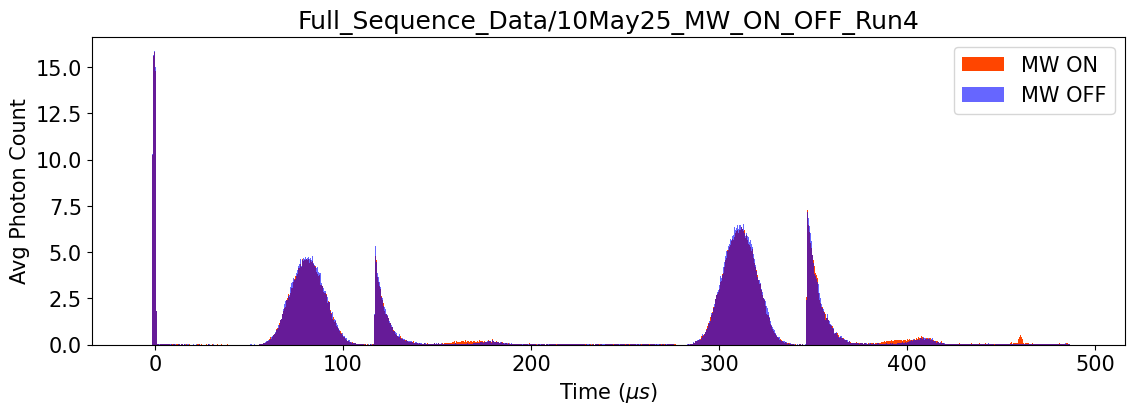

In [6]:
# n_files = 100
# Parameters
folder_path = folder+"/MW ON/"  # Path to the folder containing CSV files
folder_path1 = folder+"/MW OFF/"  # Path to the folder containing CSV files

photon_pulse_width = 18e-9  # 20 ns pulse width
photon_amplitude = 1      # 2.5 V amplitude
dead_time = 30e-9           # 35 ns dead time_arrafter each photon
time_bin = 0.5e-6             # 1 µs time_arrbin for histogram

# Aggregate all photon detection times
all_photon_times = []

'''MW ON'''
# Get all bin files from the folder
bin_files = [f for f in os.listdir(folder_path) if f.endswith(".gzip")]

# Process each CSV file
for file in bin_files:
    # print(f"Processing file: {file}")
    
    time_arr = read_bin_file(folder_path, file)[0]    # First column: Time
    voltage = read_bin_file(folder_path, file)[1]  # Second column: Voltage

    # Identify photon detections (voltage >= photon_amplitude)
    detection_indices = np.where(voltage >= photon_amplitude)[0]
    photon_times = []
    
    # Apply dead time_arr filtering
    if len(detection_indices) > 0:
        last_detection_time = time_arr[detection_indices[0]]
        photon_times.append(last_detection_time)
        for idx in detection_indices[1:]:
            if time_arr[idx] >= last_detection_time + dead_time:
                photon_times.append(time_arr[idx])
                last_detection_time = time_arr[idx]

    # Add photon times to the aggregated list
    all_photon_times.extend(photon_times)

# Convert all photon times to a single NumPy array
all_photon_times = np.array(all_photon_times)

# Bin photon detections into 1 µs time_arr bins
bins = np.arange(0, all_photon_times.max() + time_bin, time_bin)
histogram, edges = np.histogram(all_photon_times, bins=bins)

# Plot the final histogram
plt.figure(figsize=(10*4/3, 4))
plt.bar(edges[:-1] * 1e6 -8.6, histogram/len(bin_files), width=time_bin * 1e6, align="edge", color="orangered", label = 'MW ON')


'''MW OFF'''
folder_path = folder_path1  # Path to the folder containing CSV files

photon_pulse_width = 18e-9  # 20 ns pulse width
photon_amplitude = 1      # 2.5 V amplitude
dead_time = 30e-9           # 35 ns dead time_arr after each photon

# Aggregate all photon detection times
all_photon_times = []

# Get all bin files from the folder
bin_files = [f for f in os.listdir(folder_path) if f.endswith(".gzip")]

# Process each CSV file
for file in bin_files:
    # print(f"Processing file: {file}")
    
    time_arr = read_bin_file(folder_path, file)[0]    # First column: Time
    voltage = read_bin_file(folder_path, file)[1]  # Second column: Voltage

    # Identify photon detections (voltage >= photon_amplitude)
    detection_indices = np.where(voltage >= photon_amplitude)[0]
    photon_times = []
    
    # Apply dead time_arr filtering
    if len(detection_indices) > 0:
        last_detection_time = time_arr[detection_indices[0]]
        photon_times.append(last_detection_time)
        for idx in detection_indices[1:]:
            if time_arr[idx] >= last_detection_time + dead_time:
                photon_times.append(time_arr[idx])
                last_detection_time = time_arr[idx]

    # Add photon times to the aggregated list
    all_photon_times.extend(photon_times)

# Convert all photon times to a single NumPy array
all_photon_times = np.array(all_photon_times)

# Bin photon detections into 1 µs time_arr bins
bins = np.arange(0, all_photon_times.max() + time_bin, time_bin)
histogram, edges = np.histogram(all_photon_times, bins=bins)

# Plot the final histogram
plt.bar(edges[:-1]* 1e6 -8.6, histogram/len(bin_files), width=time_bin * 1e6, align="edge",alpha=0.6, color="blue", label = 'MW OFF')
plt.xlabel(r"Time ($\mu s$)")
plt.ylabel("Avg Photon Count")
plt.title(folder)
plt.legend()

# plt.savefig(folder +'_M2O RAPPI.svg')
# plt.savefig(folder +'_M2O RAPPI.pdf')

# Show the histogram
plt.show()

### Figure 1 - Zoomed In

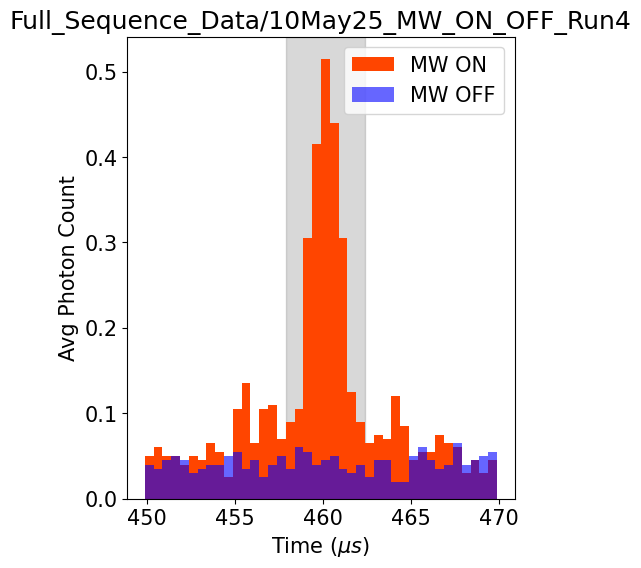

In [16]:
# n_files = 100
# Parameters
folder_path = folder+"/MW ON/"  # Path to the folder containing CSV files
folder_path1 = folder+"/MW OFF/"  # Path to the folder containing CSV files

photon_pulse_width = 18e-9  # 20 ns pulse width
photon_amplitude = 1      # 2.5 V amplitude
dead_time = 30e-9           # 30 ns dead time after each photon
time_bin = 0.5e-6             # 1 µs time_arrbin for histogram

# Aggregate all photon detection times
all_photon_times = []

'''MW ON'''
# Get all bin files from the folder
bin_files = [f for f in os.listdir(folder_path) if f.endswith(".gzip")]

# Process each CSV file
for file in bin_files:
    # print(f"Processing file: {file}")
    
    time_arr = read_bin_file(folder_path, file)[0]    # First column: Time
    voltage = read_bin_file(folder_path, file)[1]  # Second column: Voltage

    # Identify photon detections (voltage >= photon_amplitude)
    detection_indices = np.where(voltage >= photon_amplitude)[0]
    photon_times = []
    
    # Apply dead time_arr filtering
    if len(detection_indices) > 0:
        last_detection_time = time_arr[detection_indices[0]]
        photon_times.append(last_detection_time)
        for idx in detection_indices[1:]:
            if time_arr[idx] >= last_detection_time + dead_time:
                photon_times.append(time_arr[idx])
                last_detection_time = time_arr[idx]

    # Add photon times to the aggregated list
    all_photon_times.extend(photon_times)

# Convert all photon times to a single NumPy array
all_photon_times = np.array(all_photon_times)

# Bin photon detections into 1 µs time_arr bins
bins = np.arange(0, all_photon_times.max() + time_bin, time_bin)
histogram, edges = np.histogram(all_photon_times, bins=bins)

# Plot the final histogram
# plt.figure(figsize=(8/3, 4))
plt.figure(figsize=(5, 6))

# plt.figure(figsize=(10*4/3, 4))
start = 917
end = 957
plt.bar(edges[start:end] * 1e6-8.6, histogram[start:end]/len(bin_files), width=time_bin * 1e6, align="edge", color="orangered", label = 'MW ON')

'''MW OFF'''
folder_path = folder_path1  # Path to the folder containing CSV files

photon_pulse_width = 18e-9  # 20 ns pulse width
photon_amplitude = 1      # 2.5 V amplitude
dead_time = 30e-9           # 30 ns dead time_arr after each photon

# Aggregate all photon detection times
all_photon_times = []

# Get all bin files from the folder
bin_files = [f for f in os.listdir(folder_path) if f.endswith(".gzip")]

# Process each CSV file
for file in bin_files:
    # print(f"Processing file: {file}")
    
    time_arr = read_bin_file(folder_path, file)[0]    # First column: Time
    voltage = read_bin_file(folder_path, file)[1]  # Second column: Voltage

    # Identify photon detections (voltage >= photon_amplitude)
    detection_indices = np.where(voltage >= photon_amplitude)[0]
    photon_times = []
    
    # Apply dead time_arr filtering
    if len(detection_indices) > 0:
        last_detection_time = time_arr[detection_indices[0]]
        photon_times.append(last_detection_time)
        for idx in detection_indices[1:]:
            if time_arr[idx] >= last_detection_time + dead_time:
                photon_times.append(time_arr[idx])
                last_detection_time = time_arr[idx]

    # Add photon times to the aggregated list
    all_photon_times.extend(photon_times)

# Convert all photon times to a single NumPy array
all_photon_times = np.array(all_photon_times)

# Bin photon detections into 1 µs time_arr bins
bins = np.arange(0, all_photon_times.max() + time_bin, time_bin)
histogram, edges = np.histogram(all_photon_times, bins=bins)
# Add grey box from x = 459 to 461
plt.axvspan(466.5-8.6, 471-8.6, color='grey', alpha=0.3, zorder=0)
# Plot the final histogram
plt.bar(edges[start:end]* 1e6-8.6, histogram[start:end]/len(bin_files), width=time_bin * 1e6, align="edge",alpha=0.6, color="blue", label = 'MW OFF')
plt.xlabel(r"Time ($\mu s$)")
plt.ylabel("Avg Photon Count")
plt.title(folder)
plt.legend()

# plt.savefig(folder +'_Zoom M2O RAPPI.svg')
# plt.savefig(folder +'_Zoom M2O RAPPI.pdf')

# Show the histogram
plt.show()

## Figure 2 - Noise

### Pump Noise Data

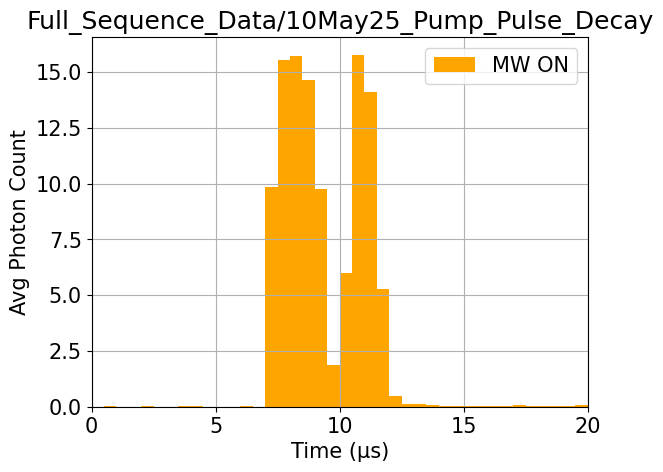

In [8]:
folder_path = "Full_Sequence_Data/10May25_Pump_Pulse_Decay"  
photon_pulse_width = 18e-9  # 18 ns pulse width
photon_amplitude = 1      # 2.5 V amplitude
dead_time = 30e-9           # 35 ns dead time_arrafter each photon
time_bin = 0.5e-6             # 1 µs time_arrbin for histogram
# Aggregate all photon detection times
all_photon_times = []
# Get all bin files from the folder
AWG_file = "file"
bin_files = [f for f in os.listdir(folder_path) if f.startswith(AWG_file)]


# Process each CSV file
for file in bin_files:
    # print(f"Processing file: {file}")
    
    time_arr = plot_bin_file(folder_path, file)[0]   # First column: Time
    voltage = plot_bin_file(folder_path, file)[1]  # Second column: Voltage
    # amp = 150
    # start_time = 800
    # start_idx = int(start_time * 2500)  # Convert start time to index (assuming 500 samples per second)
    # stop_idx = int((start_time + amp) * 2500)
    # time_arr = plot_bin_file(folder_path, file)[0][start_idx:stop_idx]    # First column: Time
    # voltage = plot_bin_file(folder_path, file)[1][start_idx:stop_idx] # Second column: Voltage
    # print((len(voltage)-2)/500)
    # break
    # Identify photon detections (voltage >= photon_amplitude)
    detection_indices = np.where(voltage >= photon_amplitude)[0]
    photon_times = []
    
    # Apply dead time_arr filtering
    if len(detection_indices) > 0:
        last_detection_time = time_arr[detection_indices[0]]
        photon_times.append(last_detection_time)
        for idx in detection_indices[1:]:
            if time_arr[idx] >= last_detection_time + dead_time:
                photon_times.append(time_arr[idx])
                last_detection_time = time_arr[idx]

    # Add photon times to the aggregated list
    all_photon_times.extend(photon_times)

# Convert all photon times to a single NumPy array
all_photon_times = np.array(all_photon_times)

# Bin photon detections into 1 µs time_arr bins
bins = np.arange(0, all_photon_times.max() + time_bin, time_bin)
histogram, edges = np.histogram(all_photon_times, bins=bins)

# Plot the final histogram
plt.bar(edges[:-1] * 1e6, histogram/len(bin_files), width=time_bin * 1e6, align="edge", color="orange", label = 'MW ON')
plt.xlabel("Time (µs)")
# plt.xlim([800,950])
plt.xlim([0,20])
plt.ylabel("Avg Photon Count")
plt.title(folder_path)
plt.legend()
plt.grid(True)
plt.savefig(folder_path+AWG_file +'.pdf')
# Show the histogram
plt.show()

[12.0, 16.0, 20.0, 24.0, 28.0, 32.0, 36.0, 40.0, 44.0, 48.0, 52.0, 56.0, 60.0, 64.0, 68.0, 72.0, 76.0, 80.0, 84.0, 88.0, 92.0, 96.0, 100.0, 104.0, 108.0, 112.0, 116.0, 120.0, 124.0, 128.0, 132.0, 136.0, 140.0, 144.0, 148.0, 152.0, 156.0, 160.0, 164.0, 168.0, 172.0, 176.0, 180.0, 184.0, 188.0, 192.0, 196.0, 200.0, 204.0, 208.0, 212.0, 216.0, 220.0, 224.0, 228.0, 232.0, 236.0, 240.0, 244.0, 248.0, 252.0, 256.0, 260.0, 264.0, 268.0, 272.0, 276.0, 280.0, 284.0, 288.0, 292.0, 296.0, 300.0, 304.0, 308.0, 312.0, 316.0, 320.0, 324.0, 328.0, 332.0, 336.0, 340.0, 344.0, 348.0, 352.0, 356.0, 360.0, 364.0, 368.0, 372.0, 376.0, 380.0, 384.0, 388.0, 392.0, 396.0, 400.0, 404.0, 408.0, 412.0, 416.0, 420.0, 424.0, 428.0, 432.0, 436.0, 440.0, 444.0, 448.0, 452.0, 456.0, 460.0, 464.0, 468.0, 472.0, 476.0, 480.0, 484.0, 488.0, 492.0, 496.0, 500.0, 504.0, 508.0, 512.0, 516.0, 520.0, 524.0, 528.0, 532.0, 536.0, 540.0, 544.0, 548.0, 552.0, 556.0, 560.0, 564.0, 568.0, 572.0, 576.0, 580.0, 584.0, 588.0, 592.0,

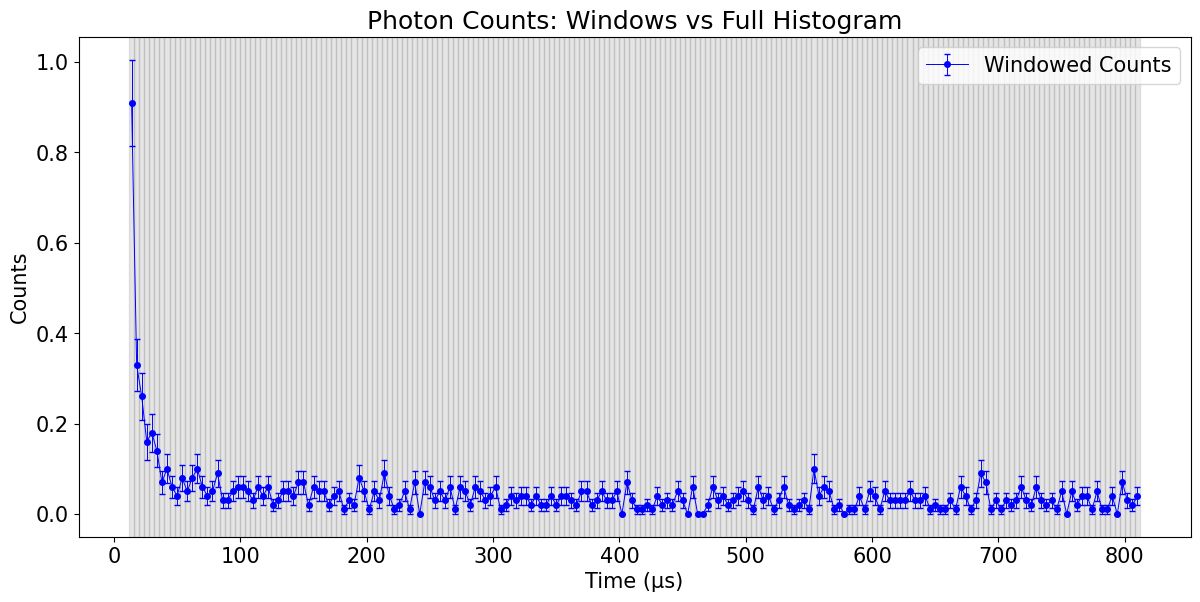

In [9]:
# Define window parameters
start_time = 12 #836-2*(7.45+4)  # Start at 700μs
window_duration = 4  # 4μs duration
gap_duration = 0    # 6μs gap
num_windows = 200     # Number of windows

# Initialize arrays to store results
window_starts = []
window_counts = []
window_errors = []


# Process each window
for i in range(num_windows):
    window_start = (start_time + i * (window_duration + gap_duration)) * 1000  # Convert to ns
    window_starts.append(window_start/1000)  # Store in μs for plotting
    
    # Initialize counts for this window
    counts = []
    
    # Process each file
    for file in bin_files:
        full_path = os.path.join(folder_path, file)
        count = read_gzip_counts_photons(full_path, window_start, window_duration*1000)
        counts.append(count)
    
    # Calculate mean and standard deviation
    mean_count = np.mean(counts)
    std_count = round(np.sqrt(np.mean(counts)/len(bin_files)),3)
    # Calculate confidence bounds for Poisson distributed data

    
    window_counts.append(mean_count)
    window_errors.append(std_count)

# window_starts = [x - 98 for x in window_starts]
print(window_starts)
print(window_counts)
print(window_errors)
# Create the plot
plt.figure(figsize=(12, 6))
# plt.figure(figsize=(5, 3))

plt.errorbar(window_starts+2*np.ones(len(window_starts)), window_counts, yerr=window_errors, fmt='o-', 
             alpha = 1, capsize=2, markersize=4, linewidth=0.7, elinewidth=0.7, color='blue', label='Windowed Counts')

plt.xlabel('Time (μs)')

# Add vertical spans to show windows
for start in window_starts:
    plt.axvspan(start, start + window_duration, alpha=0.2, color='gray')

plt.tight_layout()

# Adjust plot appearance
plt.xlabel('Time (μs)')
plt.ylabel('Counts')
# plt.yticks(np.arange(0, 3.1, 0.5))
plt.title('Photon Counts: Windows vs Full Histogram')
# plt.grid(True, alpha=0.3)
# plt.xlim([714, 850])
plt.legend()
# plt.savefig(folder_path+'windowed.pdf')
plt.show()

In [10]:
print(window_starts)
print(np.array2string(np.array(window_counts), separator=', '))
print(np.array2string(np.array(window_errors), separator=', '))


[12.0, 16.0, 20.0, 24.0, 28.0, 32.0, 36.0, 40.0, 44.0, 48.0, 52.0, 56.0, 60.0, 64.0, 68.0, 72.0, 76.0, 80.0, 84.0, 88.0, 92.0, 96.0, 100.0, 104.0, 108.0, 112.0, 116.0, 120.0, 124.0, 128.0, 132.0, 136.0, 140.0, 144.0, 148.0, 152.0, 156.0, 160.0, 164.0, 168.0, 172.0, 176.0, 180.0, 184.0, 188.0, 192.0, 196.0, 200.0, 204.0, 208.0, 212.0, 216.0, 220.0, 224.0, 228.0, 232.0, 236.0, 240.0, 244.0, 248.0, 252.0, 256.0, 260.0, 264.0, 268.0, 272.0, 276.0, 280.0, 284.0, 288.0, 292.0, 296.0, 300.0, 304.0, 308.0, 312.0, 316.0, 320.0, 324.0, 328.0, 332.0, 336.0, 340.0, 344.0, 348.0, 352.0, 356.0, 360.0, 364.0, 368.0, 372.0, 376.0, 380.0, 384.0, 388.0, 392.0, 396.0, 400.0, 404.0, 408.0, 412.0, 416.0, 420.0, 424.0, 428.0, 432.0, 436.0, 440.0, 444.0, 448.0, 452.0, 456.0, 460.0, 464.0, 468.0, 472.0, 476.0, 480.0, 484.0, 488.0, 492.0, 496.0, 500.0, 504.0, 508.0, 512.0, 516.0, 520.0, 524.0, 528.0, 532.0, 536.0, 540.0, 544.0, 548.0, 552.0, 556.0, 560.0, 564.0, 568.0, 572.0, 576.0, 580.0, 584.0, 588.0, 592.0,

### RAP Noise Data

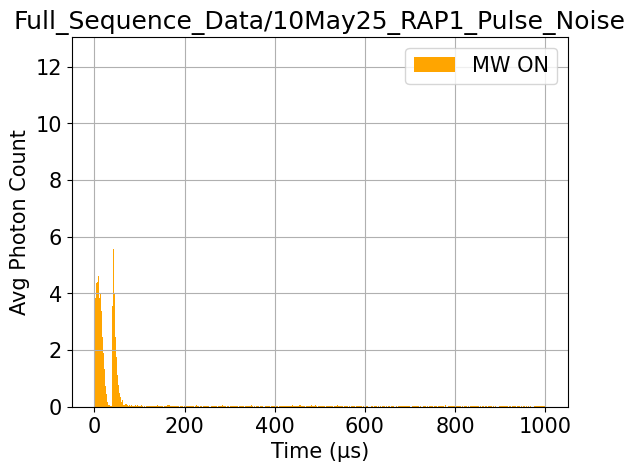

In [14]:
folder_path = 'Full_Sequence_Data/10May25_RAP1_Pulse_Noise'
photon_pulse_width = 18e-9  # 18 ns pulse width
photon_amplitude = 1      # 2.5 V amplitude
dead_time = 30e-9           # 35 ns dead time_arrafter each photon
time_bin = 0.5e-6             # 1 µs time_arrbin for histogram
# Aggregate all photon detection times
all_photon_times = []
# Get all bin files from the folder
AWG_file = "file"
bin_files = [f for f in os.listdir(folder_path) if f.startswith(AWG_file)]


# Process each CSV file
for file in bin_files:
    # print(f"Processing file: {file}")
    
    time_arr = plot_bin_file(folder_path, file)[0]   # First column: Time
    voltage = plot_bin_file(folder_path, file)[1]  # Second column: Voltage
    # amp = 150
    # start_time = 800
    # start_idx = int(start_time * 2500)  # Convert start time to index (assuming 500 samples per second)
    # stop_idx = int((start_time + amp) * 2500)
    # time_arr = plot_bin_file(folder_path, file)[0][start_idx:stop_idx]    # First column: Time
    # voltage = plot_bin_file(folder_path, file)[1][start_idx:stop_idx] # Second column: Voltage
    # print((len(voltage)-2)/500)
    # break
    # Identify photon detections (voltage >= photon_amplitude)
    detection_indices = np.where(voltage >= photon_amplitude)[0]
    photon_times = []
    
    # Apply dead time_arr filtering
    if len(detection_indices) > 0:
        last_detection_time = time_arr[detection_indices[0]]
        photon_times.append(last_detection_time)
        for idx in detection_indices[1:]:
            if time_arr[idx] >= last_detection_time + dead_time:
                photon_times.append(time_arr[idx])
                last_detection_time = time_arr[idx]

    # Add photon times to the aggregated list
    all_photon_times.extend(photon_times)

# Convert all photon times to a single NumPy array
all_photon_times = np.array(all_photon_times)

# Bin photon detections into 1 µs time_arr bins
bins = np.arange(0, all_photon_times.max() + time_bin, time_bin)
histogram, edges = np.histogram(all_photon_times, bins=bins)

# Plot the final histogram
plt.bar(edges[:-1] * 1e6, histogram/len(bin_files), width=time_bin * 1e6, align="edge", color="orange", label = 'MW ON')
plt.xlabel("Time (µs)")
# plt.xlim([800,950])
# plt.xlim([0,50])
plt.ylabel("Avg Photon Count")
plt.title(folder_path)
plt.legend()
plt.grid(True)
# plt.savefig(folder_path+AWG_file +'.pdf')
# Show the histogram
plt.show()

RAP Ends at: 35
[60.0, 64.0, 68.0, 72.0, 76.0, 80.0, 84.0, 88.0, 92.0, 96.0, 100.0, 104.0, 108.0, 112.0, 116.0, 120.0, 124.0, 128.0, 132.0, 136.0, 140.0, 144.0, 148.0, 152.0, 156.0, 160.0, 164.0, 168.0, 172.0, 176.0, 180.0, 184.0, 188.0, 192.0, 196.0, 200.0, 204.0, 208.0, 212.0, 216.0, 220.0, 224.0, 228.0, 232.0, 236.0, 240.0, 244.0, 248.0, 252.0, 256.0, 260.0, 264.0, 268.0, 272.0, 276.0, 280.0, 284.0, 288.0, 292.0, 296.0, 300.0, 304.0, 308.0, 312.0, 316.0, 320.0, 324.0, 328.0, 332.0, 336.0, 340.0, 344.0, 348.0, 352.0, 356.0, 360.0, 364.0, 368.0, 372.0, 376.0, 380.0, 384.0, 388.0, 392.0, 396.0, 400.0, 404.0, 408.0, 412.0, 416.0, 420.0, 424.0, 428.0, 432.0, 436.0, 440.0, 444.0, 448.0, 452.0, 456.0, 460.0, 464.0, 468.0, 472.0, 476.0, 480.0, 484.0, 488.0, 492.0, 496.0, 500.0, 504.0, 508.0, 512.0, 516.0, 520.0, 524.0, 528.0, 532.0, 536.0, 540.0, 544.0, 548.0, 552.0, 556.0, 560.0, 564.0, 568.0, 572.0, 576.0, 580.0, 584.0, 588.0, 592.0, 596.0, 600.0, 604.0, 608.0, 612.0, 616.0, 620.0, 624.0,

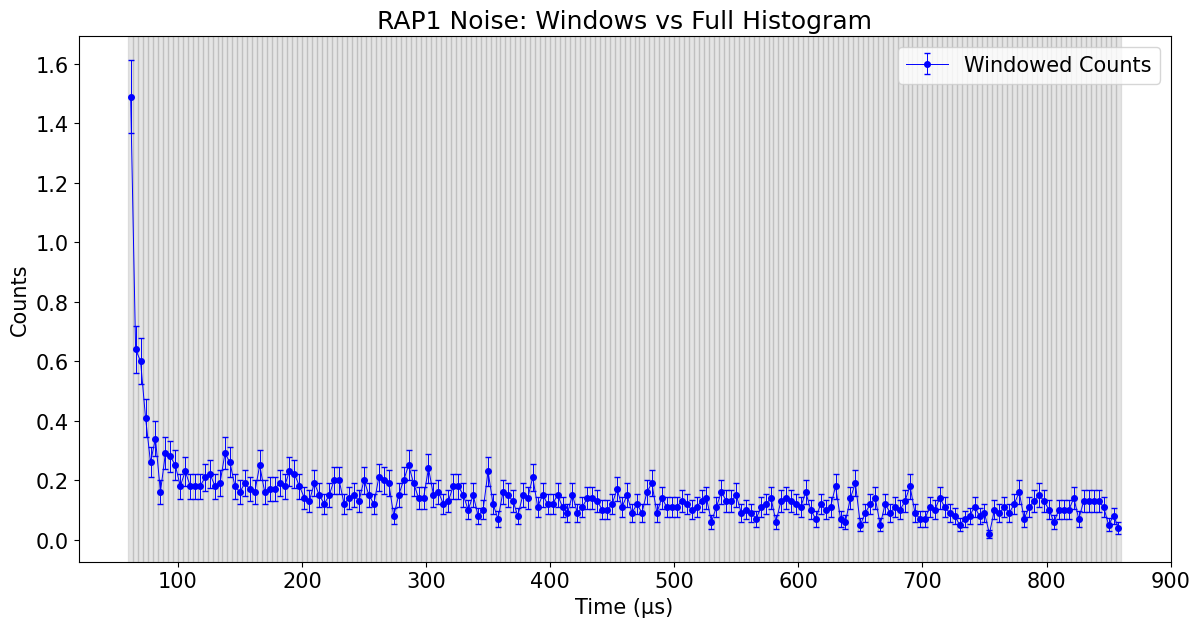

In [16]:
# Define window parameters
start_time = 60 #836-2*(7.45+4)  # Start at 700μs
print('RAP Ends at:', 40-5)
window_duration = 4  # 4μs duration
gap_duration = 0    # 6μs gap
num_windows = 200     # Number of windows

# Initialize arrays to store results
window_starts = []
window_counts = []
window_errors = []


# Process each window
for i in range(num_windows):
    window_start = (start_time + i * (window_duration + gap_duration)) * 1000  # Convert to ns
    window_starts.append(window_start/1000)  # Store in μs for plotting
    
    # Initialize counts for this window
    counts = []
    
    # Process each file
    for file in bin_files:
        full_path = os.path.join(folder_path, file)
        count = read_gzip_counts_photons(full_path, window_start, window_duration*1000)
        counts.append(count)
    
    # Calculate mean and standard deviation
    mean_count = np.mean(counts)
    std_count = round(np.sqrt(np.mean(counts)/len(bin_files)),3)
    # Calculate confidence bounds for Poisson distributed data

    
    window_counts.append(mean_count)
    window_errors.append(std_count)

# window_starts = [x - 98 for x in window_starts]
print(window_starts)
print(np.array(window_counts))
print(np.array(window_errors))
# Create the plot
plt.figure(figsize=(12, 6))
# plt.figure(figsize=(5, 3))

plt.errorbar(window_starts+2*np.ones(len(window_starts)), window_counts, yerr=window_errors, fmt='o-', 
             alpha = 1, capsize=2, markersize=4, linewidth=0.7, elinewidth=0.7, color='blue', label='Windowed Counts')


# Add vertical spans to show windows
for start in window_starts:
    plt.axvspan(start, start + window_duration, alpha=0.2, color='gray')

plt.tight_layout()

# Adjust plot appearance
plt.xlabel('Time (μs)')
plt.ylabel('Counts')
# plt.yticks(np.arange(0, 3.1, 0.5))
plt.title('RAP1 Noise: Windows vs Full Histogram')
# plt.grid(True, alpha=0.3)
# plt.xlim([0, 50])
plt.legend()
# plt.tight_layout()
# plt.savefig(folder_path+'windowed.pdf')
plt.show()

In [13]:
print(window_starts)
print(np.array(window_counts))
print(np.array(window_errors))

[60.0, 64.0, 68.0, 72.0, 76.0, 80.0, 84.0, 88.0, 92.0, 96.0, 100.0, 104.0, 108.0, 112.0, 116.0, 120.0, 124.0, 128.0, 132.0, 136.0, 140.0, 144.0, 148.0, 152.0, 156.0, 160.0, 164.0, 168.0, 172.0, 176.0, 180.0, 184.0, 188.0, 192.0, 196.0, 200.0, 204.0, 208.0, 212.0, 216.0, 220.0, 224.0, 228.0, 232.0, 236.0, 240.0, 244.0, 248.0, 252.0, 256.0, 260.0, 264.0, 268.0, 272.0, 276.0, 280.0, 284.0, 288.0, 292.0, 296.0, 300.0, 304.0, 308.0, 312.0, 316.0, 320.0, 324.0, 328.0, 332.0, 336.0, 340.0, 344.0, 348.0, 352.0, 356.0, 360.0, 364.0, 368.0, 372.0, 376.0, 380.0, 384.0, 388.0, 392.0, 396.0, 400.0, 404.0, 408.0, 412.0, 416.0, 420.0, 424.0, 428.0, 432.0, 436.0, 440.0, 444.0, 448.0, 452.0, 456.0, 460.0, 464.0, 468.0, 472.0, 476.0, 480.0, 484.0, 488.0, 492.0, 496.0, 500.0, 504.0, 508.0, 512.0, 516.0, 520.0, 524.0, 528.0, 532.0, 536.0, 540.0, 544.0, 548.0, 552.0, 556.0, 560.0, 564.0, 568.0, 572.0, 576.0, 580.0, 584.0, 588.0, 592.0, 596.0, 600.0, 604.0, 608.0, 612.0, 616.0, 620.0, 624.0, 628.0, 632.0, 6

### RAP + Pump Noise Data

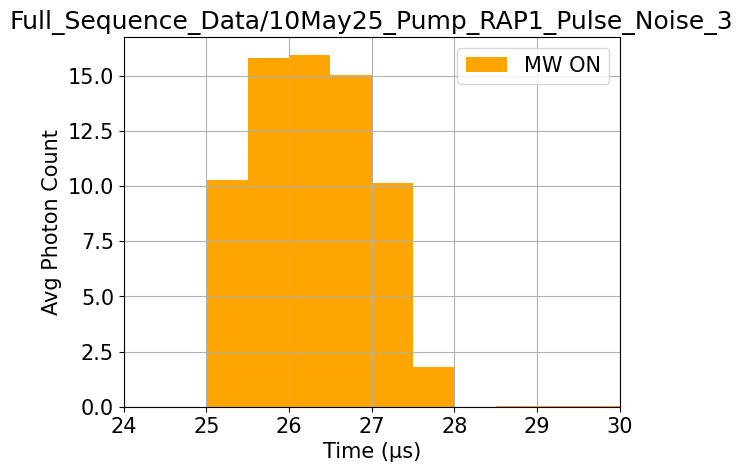

In [17]:
folder_path = 'Full_Sequence_Data/10May25_Pump_RAP1_Pulse_Noise_3'
photon_pulse_width = 18e-9  # 18 ns pulse width
photon_amplitude = 1      # 2.5 V amplitude
dead_time = 30e-9           # 35 ns dead time_arrafter each photon
time_bin = 0.5e-6             # 1 µs time_arrbin for histogram
# Aggregate all photon detection times
all_photon_times = []
# Get all bin files from the folder
AWG_file = "file"
bin_files = [f for f in os.listdir(folder_path) if f.startswith(AWG_file)]


# Process each CSV file
for file in bin_files:
    # print(f"Processing file: {file}")
    
    time_arr = plot_bin_file(folder_path, file)[0]   # First column: Time
    voltage = plot_bin_file(folder_path, file)[1]  # Second column: Voltage
    # amp = 150
    # start_time = 800
    # start_idx = int(start_time * 2500)  # Convert start time to index (assuming 500 samples per second)
    # stop_idx = int((start_time + amp) * 2500)
    # time_arr = plot_bin_file(folder_path, file)[0][start_idx:stop_idx]    # First column: Time
    # voltage = plot_bin_file(folder_path, file)[1][start_idx:stop_idx] # Second column: Voltage
    # print((len(voltage)-2)/500)
    # break
    # Identify photon detections (voltage >= photon_amplitude)
    detection_indices = np.where(voltage >= photon_amplitude)[0]
    photon_times = []
    
    # Apply dead time_arr filtering
    if len(detection_indices) > 0:
        last_detection_time = time_arr[detection_indices[0]]
        photon_times.append(last_detection_time)
        for idx in detection_indices[1:]:
            if time_arr[idx] >= last_detection_time + dead_time:
                photon_times.append(time_arr[idx])
                last_detection_time = time_arr[idx]

    # Add photon times to the aggregated list
    all_photon_times.extend(photon_times)

# Convert all photon times to a single NumPy array
all_photon_times = np.array(all_photon_times)

# Bin photon detections into 1 µs time_arr bins
bins = np.arange(0, all_photon_times.max() + time_bin, time_bin)
histogram, edges = np.histogram(all_photon_times, bins=bins)

# Plot the final histogram
plt.bar(edges[:-1] * 1e6, histogram/len(bin_files), width=time_bin * 1e6, align="edge", color="orange", label = 'MW ON')
plt.xlabel("Time (µs)")
# plt.xlim([800,950])
plt.xlim([24,30])
plt.ylabel("Avg Photon Count")
plt.title(folder_path)
plt.legend()
plt.grid(True)
# plt.savefig(folder_path+AWG_file +'.pdf')
# Show the histogram
plt.show()

RAP Ends at: 135
[200.0, 204.0, 208.0, 212.0, 216.0, 220.0, 224.0, 228.0, 232.0, 236.0, 240.0, 244.0, 248.0, 252.0, 256.0, 260.0, 264.0, 268.0, 272.0, 276.0, 280.0, 284.0, 288.0, 292.0, 296.0, 300.0, 304.0, 308.0, 312.0, 316.0, 320.0, 324.0, 328.0, 332.0, 336.0, 340.0, 344.0, 348.0, 352.0, 356.0, 360.0, 364.0, 368.0, 372.0, 376.0, 380.0, 384.0, 388.0, 392.0, 396.0, 400.0, 404.0, 408.0, 412.0, 416.0, 420.0, 424.0, 428.0, 432.0, 436.0, 440.0, 444.0, 448.0, 452.0, 456.0, 460.0, 464.0, 468.0, 472.0, 476.0, 480.0, 484.0, 488.0, 492.0, 496.0, 500.0, 504.0, 508.0, 512.0, 516.0, 520.0, 524.0, 528.0, 532.0, 536.0, 540.0, 544.0, 548.0, 552.0, 556.0, 560.0, 564.0, 568.0, 572.0, 576.0, 580.0, 584.0, 588.0, 592.0, 596.0, 600.0, 604.0, 608.0, 612.0, 616.0, 620.0, 624.0, 628.0, 632.0, 636.0, 640.0, 644.0, 648.0, 652.0, 656.0, 660.0, 664.0, 668.0, 672.0, 676.0, 680.0, 684.0, 688.0, 692.0, 696.0, 700.0, 704.0, 708.0, 712.0, 716.0, 720.0, 724.0, 728.0, 732.0, 736.0, 740.0, 744.0, 748.0, 752.0, 756.0, 76

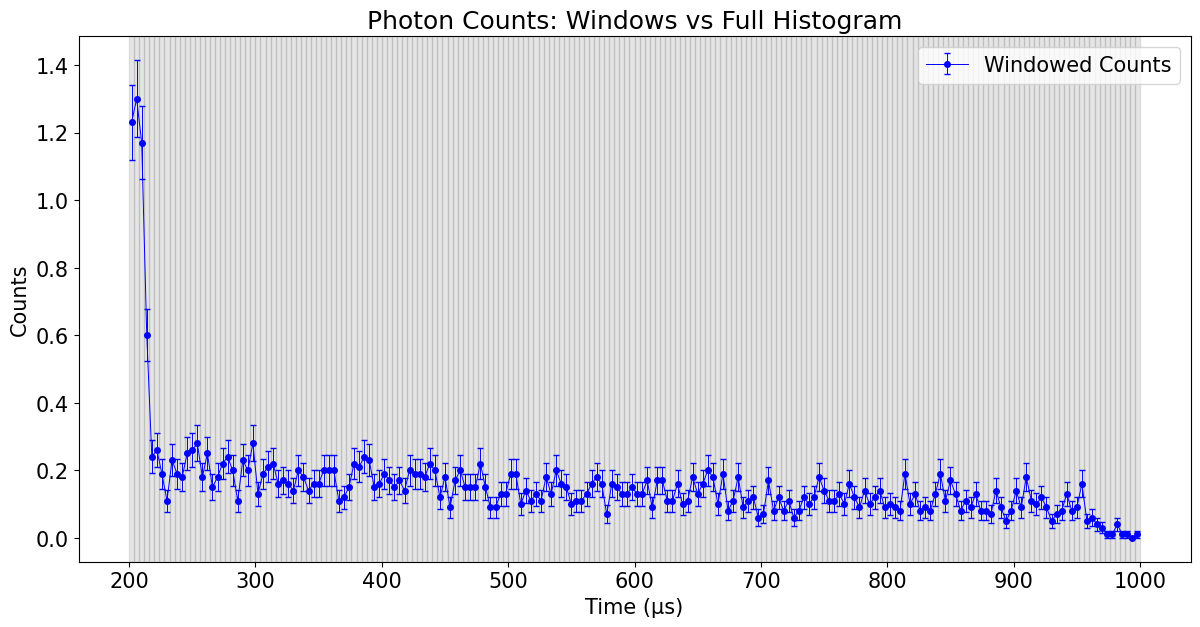

In [18]:
# Define window parameters
start_time = 200 #300 #836-2*(7.45+4)  # Start at 700μs
print('RAP Ends at:', 140-5)
window_duration = 4  # 4μs duration
gap_duration = 0    # 6μs gap
num_windows = 200     # Number of windows

# Initialize arrays to store results
window_starts = []
window_counts = []
window_errors = []


# Process each window
for i in range(num_windows):
    window_start = (start_time + i * (window_duration + gap_duration)) * 1000  # Convert to ns
    window_starts.append(window_start/1000)  # Store in μs for plotting
    
    # Initialize counts for this window
    counts = []
    
    # Process each file
    for file in bin_files:
        full_path = os.path.join(folder_path, file)
        count = read_gzip_counts_photons(full_path, window_start, window_duration*1000)
        counts.append(count)
    
    # Calculate mean and standard deviation
    mean_count = np.mean(counts)
    std_count = round(np.sqrt(np.mean(counts)/len(bin_files)),3)
    
    window_counts.append(mean_count)
    window_errors.append(std_count)

# window_starts = [x - 98 for x in window_starts]
print(window_starts)
np.array(window_counts)
np.array(window_errors)
# Create the plot
plt.figure(figsize=(12, 6))
# plt.figure(figsize=(5, 3))

plt.errorbar(window_starts+2*np.ones(len(window_starts)), window_counts, yerr=window_errors, fmt='o-', 
             alpha = 1, capsize=2, markersize=4, linewidth=0.7, elinewidth=0.7, color='blue', label='Windowed Counts')

# Add vertical spans to show windows
for start in window_starts:
    plt.axvspan(start, start + window_duration, alpha=0.2, color='gray')

plt.tight_layout()

# Adjust plot appearance
plt.xlabel('Time (μs)')
plt.ylabel('Counts')
# plt.yticks(np.arange(0, 3.1, 0.5))
plt.title('Photon Counts: Windows vs Full Histogram')
# plt.grid(True, alpha=0.3)
# plt.xlim([714, 850])
plt.legend()
# plt.tight_layout()
# plt.savefig(folder_path+'windowed.pdf')
plt.show()

### Pump & RAP Noise

C:\Users\quant\AppData\Local\Temp\ipykernel_30684\831328109.py:167: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels([f'{t:.0f}' for t in new_ticks])


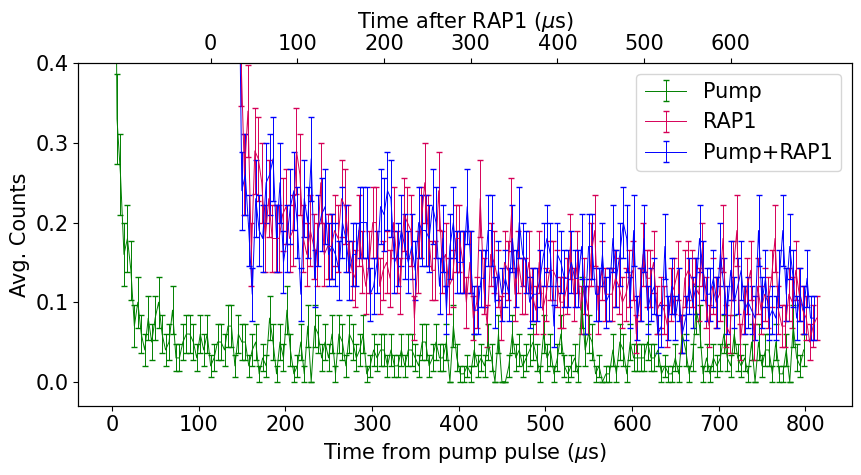

In [14]:
# Data on 10-May-2025
pump_times = -12 + np.array([12.0, 16.0, 20.0, 24.0, 28.0, 32.0, 36.0, 40.0, 44.0, 48.0, 52.0, 56.0, 60.0, 64.0, 68.0, 72.0, 76.0, 80.0, 84.0, 88.0, 92.0, 96.0, 100.0, 104.0, 108.0, 112.0, 116.0, 120.0, 124.0, 128.0, 132.0, 136.0, 140.0, 144.0, 148.0, 152.0, 156.0, 160.0, 164.0, 168.0, 172.0, 176.0, 180.0, 184.0, 188.0, 192.0, 196.0, 200.0, 204.0, 208.0, 212.0, 216.0, 220.0, 224.0, 228.0, 232.0, 236.0, 240.0, 244.0, 248.0, 252.0, 256.0, 260.0, 264.0, 268.0, 272.0, 276.0, 280.0, 284.0, 288.0, 292.0, 296.0, 300.0, 304.0, 308.0, 312.0, 316.0, 320.0, 324.0, 328.0, 332.0, 336.0, 340.0, 344.0, 348.0, 352.0, 356.0, 360.0, 364.0, 368.0, 372.0, 376.0, 380.0, 384.0, 388.0, 392.0, 396.0, 400.0, 404.0, 408.0, 412.0, 416.0, 420.0, 424.0, 428.0, 432.0, 436.0, 440.0, 444.0, 448.0, 452.0, 456.0, 460.0, 464.0, 468.0, 472.0, 476.0, 480.0, 484.0, 488.0, 492.0, 496.0, 500.0, 504.0, 508.0, 512.0, 516.0, 520.0, 524.0, 528.0, 532.0, 536.0, 540.0, 544.0, 548.0, 552.0, 556.0, 560.0, 564.0, 568.0, 572.0, 576.0, 580.0, 584.0, 588.0, 592.0, 596.0, 600.0, 604.0, 608.0, 612.0, 616.0, 620.0, 624.0, 628.0, 632.0, 636.0, 640.0, 644.0, 648.0, 652.0, 656.0, 660.0, 664.0, 668.0, 672.0, 676.0, 680.0, 684.0, 688.0, 692.0, 696.0, 700.0, 704.0, 708.0, 712.0, 716.0, 720.0, 724.0, 728.0, 732.0, 736.0, 740.0, 744.0, 748.0, 752.0, 756.0, 760.0, 764.0, 768.0, 772.0, 776.0, 780.0, 784.0, 788.0, 792.0, 796.0, 800.0, 804.0, 808.0])
# Pump at 10us
pump_noise = np.array([0.91, 0.33, 0.26, 0.16, 0.18, 0.14, 0.07, 0.1 , 0.06, 0.04, 0.08, 0.05,
 0.08, 0.1 , 0.06, 0.04, 0.05, 0.09, 0.03, 0.03, 0.05, 0.06, 0.06, 0.05,
 0.03, 0.06, 0.04, 0.06, 0.02, 0.03, 0.05, 0.05, 0.04, 0.07, 0.07, 0.02,
 0.06, 0.05, 0.05, 0.02, 0.04, 0.05, 0.01, 0.03, 0.02, 0.08, 0.05, 0.01,
 0.05, 0.03, 0.09, 0.04, 0.01, 0.02, 0.05, 0.01, 0.07, 0.  , 0.07, 0.06,
 0.03, 0.05, 0.03, 0.06, 0.01, 0.06, 0.05, 0.02, 0.06, 0.05, 0.03, 0.04,
 0.06, 0.01, 0.02, 0.04, 0.03, 0.04, 0.04, 0.02, 0.04, 0.02, 0.02, 0.04,
 0.02, 0.04, 0.04, 0.03, 0.02, 0.05, 0.05, 0.02, 0.03, 0.05, 0.03, 0.03,
 0.05, 0.  , 0.07, 0.03, 0.01, 0.01, 0.02, 0.01, 0.04, 0.02, 0.03, 0.02,
 0.05, 0.03, 0.  , 0.06, 0.  , 0.  , 0.02, 0.06, 0.03, 0.04, 0.02, 0.03,
 0.04, 0.05, 0.03, 0.01, 0.06, 0.03, 0.04, 0.01, 0.03, 0.06, 0.02, 0.01,
 0.02, 0.03, 0.01, 0.1 , 0.04, 0.06, 0.05, 0.01, 0.02, 0.  , 0.01, 0.01,
 0.04, 0.01, 0.05, 0.04, 0.01, 0.05, 0.03, 0.03, 0.03, 0.03, 0.05, 0.03,
 0.03, 0.04, 0.01, 0.02, 0.01, 0.01, 0.03, 0.01, 0.06, 0.04, 0.01, 0.03,
 0.09, 0.07, 0.01, 0.03, 0.01, 0.03, 0.02, 0.03, 0.06, 0.03, 0.02, 0.06,
 0.03, 0.02, 0.03, 0.01, 0.05, 0.  , 0.05, 0.02, 0.04, 0.04, 0.01, 0.05,
 0.01, 0.01, 0.04, 0.  , 0.07, 0.03, 0.02, 0.04])

pump_noise_std = np.array([0.095, 0.057, 0.051, 0.04 , 0.042, 0.037, 0.026, 0.032, 0.024, 0.02 ,
 0.028, 0.022, 0.028, 0.032, 0.024, 0.02 , 0.022, 0.03 , 0.017, 0.017,
 0.022, 0.024, 0.024, 0.022, 0.017, 0.024, 0.02 , 0.024, 0.014, 0.017,
 0.022, 0.022, 0.02 , 0.026, 0.026, 0.014, 0.024, 0.022, 0.022, 0.014,
 0.02 , 0.022, 0.01 , 0.017, 0.014, 0.028, 0.022, 0.01 , 0.022, 0.017,
 0.03 , 0.02 , 0.01 , 0.014, 0.022, 0.01 , 0.026, 0.   , 0.026, 0.024,
 0.017, 0.022, 0.017, 0.024, 0.01 , 0.024, 0.022, 0.014, 0.024, 0.022,
 0.017, 0.02 , 0.024, 0.01 , 0.014, 0.02 , 0.017, 0.02 , 0.02 , 0.014,
 0.02 , 0.014, 0.014, 0.02 , 0.014, 0.02 , 0.02 , 0.017, 0.014, 0.022,
 0.022, 0.014, 0.017, 0.022, 0.017, 0.017, 0.022, 0.   , 0.026, 0.017,
 0.01 , 0.01 , 0.014, 0.01 , 0.02 , 0.014, 0.017, 0.014, 0.022, 0.017,
 0.   , 0.024, 0.   , 0.   , 0.014, 0.024, 0.017, 0.02 , 0.014, 0.017,
 0.02 , 0.022, 0.017, 0.01 , 0.024, 0.017, 0.02 , 0.01 , 0.017, 0.024,
 0.014, 0.01 , 0.014, 0.017, 0.01 , 0.032, 0.02 , 0.024, 0.022, 0.01 ,
 0.014, 0.   , 0.01 , 0.01 , 0.02 , 0.01 , 0.022, 0.02 , 0.01 , 0.022,
 0.017, 0.017, 0.017, 0.017, 0.022, 0.017, 0.017, 0.02 , 0.01 , 0.014,
 0.01 , 0.01 , 0.017, 0.01 , 0.024, 0.02 , 0.01 , 0.017, 0.03 , 0.026,
 0.01 , 0.017, 0.01 , 0.017, 0.014, 0.017, 0.024, 0.017, 0.014, 0.024,
 0.017, 0.014, 0.017, 0.01 , 0.022, 0.   , 0.022, 0.014, 0.02 , 0.02 ,
 0.01 , 0.022, 0.01 , 0.01 , 0.02 , 0.   , 0.026, 0.017, 0.014, 0.02 ])

# RAP ends at 35us, Pump is at -75us
rap1_times = 75 + np.array([60.0, 64.0, 68.0, 72.0, 76.0, 80.0, 84.0, 
                            88.0, 92.0, 96.0, 100.0, 104.0, 108.0, 112.0, 116.0, 120.0, 124.0, 
                            128.0, 132.0, 136.0, 140.0, 144.0, 148.0, 152.0, 156.0, 160.0, 164.0, 
                            168.0, 172.0, 176.0, 180.0, 184.0, 188.0, 192.0, 196.0, 200.0, 204.0, 
                            208.0, 212.0, 216.0, 220.0, 224.0, 228.0, 232.0, 236.0, 240.0, 244.0, 
                            248.0, 252.0, 256.0, 260.0, 264.0, 268.0, 272.0, 276.0, 280.0, 284.0, 
                            288.0, 292.0, 296.0, 300.0, 304.0, 308.0, 312.0, 316.0, 320.0, 324.0, 
                            328.0, 332.0, 336.0, 340.0, 344.0, 348.0, 352.0, 356.0, 360.0, 364.0, 
                            368.0, 372.0, 376.0, 380.0, 384.0, 388.0, 392.0, 396.0, 400.0, 404.0, 
                            408.0, 412.0, 416.0, 420.0, 424.0, 428.0, 432.0, 436.0, 440.0, 444.0, 
                            448.0, 452.0, 456.0, 460.0, 464.0, 468.0, 472.0, 476.0, 480.0, 484.0, 
                            488.0, 492.0, 496.0, 500.0, 504.0, 508.0, 512.0, 516.0, 520.0, 524.0, 
                            528.0, 532.0, 536.0, 540.0, 544.0, 548.0, 552.0, 556.0, 560.0, 564.0, 
                            568.0, 572.0, 576.0, 580.0, 584.0, 588.0, 592.0, 596.0, 600.0, 604.0, 
                            608.0, 612.0, 616.0, 620.0, 624.0, 628.0, 632.0, 636.0, 640.0, 644.0, 
                            648.0, 652.0, 656.0, 660.0, 664.0, 668.0, 672.0, 676.0, 680.0, 684.0, 
                            688.0, 692.0, 696.0, 700.0, 704.0, 708.0, 712.0, 716.0, 720.0, 724.0, 
                            728.0, 732.0, 736.0, 740.0, 744.0, 748.0, 752.0, 756.0, 760.0, 764.0, 
                            768.0, 772.0, 776.0, 780.0, 784.0, 788.0, 792.0, 796.0, 800.0, 804.0, 
                            808.0, 812.0, 816.0, 820.0, 824.0, 828.0, 832.0, 836.0, 840.0, 844.0,
                              848.0, 852.0, 856.0])

rap1_noise = np.array([1.49, 0.64, 0.6 , 0.41, 0.26, 0.34, 0.16, 0.29, 0.28, 0.25, 0.18,
       0.23, 0.18, 0.18, 0.18, 0.21, 0.22, 0.18, 0.19, 0.29, 0.26, 0.18,
       0.16, 0.19, 0.17, 0.16, 0.25, 0.16, 0.17, 0.17, 0.19, 0.18, 0.23,
       0.22, 0.18, 0.14, 0.13, 0.19, 0.15, 0.12, 0.15, 0.2 , 0.2 , 0.12,
       0.14, 0.15, 0.13, 0.2 , 0.15, 0.12, 0.21, 0.2 , 0.19, 0.08, 0.15,
       0.2 , 0.25, 0.19, 0.14, 0.14, 0.24, 0.15, 0.16, 0.12, 0.13, 0.18,
       0.18, 0.15, 0.1 , 0.15, 0.08, 0.1 , 0.23, 0.12, 0.07, 0.16, 0.15,
       0.13, 0.08, 0.15, 0.14, 0.21, 0.11, 0.15, 0.12, 0.12, 0.15, 0.11,
       0.09, 0.15, 0.09, 0.11, 0.14, 0.14, 0.13, 0.1 , 0.1 , 0.12, 0.17,
       0.11, 0.15, 0.09, 0.12, 0.09, 0.16, 0.19, 0.09, 0.14, 0.11, 0.11,
       0.11, 0.13, 0.12, 0.1 , 0.11, 0.13, 0.14, 0.06, 0.11, 0.16, 0.13,
       0.13, 0.15, 0.09, 0.1 , 0.09, 0.07, 0.11, 0.12, 0.14, 0.06, 0.13,
       0.14, 0.13, 0.12, 0.11, 0.16, 0.1 , 0.07, 0.12, 0.1 , 0.11, 0.18,
       0.07, 0.06, 0.14, 0.19, 0.05, 0.09, 0.12, 0.14, 0.05, 0.12, 0.09,
       0.11, 0.1 , 0.13, 0.18, 0.09, 0.07, 0.07, 0.11, 0.1 , 0.14, 0.11,
       0.09, 0.08, 0.05, 0.07, 0.08, 0.11, 0.08, 0.09, 0.02, 0.1 , 0.09,
       0.11, 0.09, 0.12, 0.16, 0.07, 0.11, 0.13, 0.15, 0.13, 0.1 , 0.06,
       0.1 , 0.1 , 0.1 , 0.14, 0.07, 0.13, 0.13, 0.13, 0.13, 0.11, 0.05,
       0.08, 0.04])
rap1_noise_std = np.array([0.122, 0.08, 0.077, 0.064, 0.051, 0.058, 0.04, 0.054, 0.053, 0.05, 0.042, 0.048,
 0.042, 0.042, 0.042, 0.046, 0.047, 0.042, 0.044, 0.054, 0.051, 0.042, 0.04, 0.044,
 0.041, 0.04, 0.05, 0.04, 0.041, 0.041, 0.044, 0.042, 0.048, 0.047, 0.042, 0.037,
 0.036, 0.044, 0.039, 0.035, 0.039, 0.045, 0.045, 0.035, 0.037, 0.039, 0.036, 0.045,
 0.039, 0.035, 0.046, 0.045, 0.044, 0.028, 0.039, 0.045, 0.05, 0.044, 0.037, 0.037,
 0.049, 0.039, 0.04, 0.035, 0.036, 0.042, 0.042, 0.039, 0.032, 0.039, 0.028, 0.032,
 0.048, 0.035, 0.026, 0.04, 0.039, 0.036, 0.028, 0.039, 0.037, 0.046, 0.033, 0.039,
 0.035, 0.035, 0.039, 0.033, 0.03, 0.039, 0.03, 0.033, 0.037, 0.037, 0.036, 0.032,
 0.032, 0.035, 0.041, 0.033, 0.039, 0.03, 0.035, 0.03, 0.04, 0.044, 0.03, 0.037,
 0.033, 0.033, 0.033, 0.036, 0.035, 0.032, 0.033, 0.036, 0.037, 0.024, 0.033, 0.04,
 0.036, 0.036, 0.039, 0.03, 0.032, 0.03, 0.026, 0.033, 0.035, 0.037, 0.024, 0.036,
 0.037, 0.036, 0.035, 0.033, 0.04, 0.032, 0.026, 0.035, 0.032, 0.033, 0.042, 0.026,
 0.024, 0.037, 0.044, 0.022, 0.03, 0.035, 0.037, 0.022, 0.035, 0.03, 0.033, 0.032,
 0.036, 0.042, 0.03, 0.026, 0.026, 0.033, 0.032, 0.037, 0.033, 0.03, 0.028, 0.022,
 0.026, 0.028, 0.033, 0.028, 0.03, 0.014, 0.032, 0.03, 0.033, 0.03, 0.035, 0.04,
 0.026, 0.033, 0.036, 0.039, 0.036, 0.032, 0.024, 0.032, 0.032, 0.032, 0.037, 0.026,
 0.036, 0.036, 0.036, 0.036, 0.033, 0.022, 0.028, 0.02])

pump_rap1_times = -26.5*2-15 + np.array([200.0, 204.0, 208.0, 212.0, 216.0, 220.0, 224.0, 228.0, 232.0, 236.0, 240.0, 244.0, 248.0, 252.0, 256.0, 260.0, 264.0, 268.0, 272.0, 276.0, 280.0, 284.0, 288.0, 292.0, 296.0, 300.0, 304.0, 308.0, 312.0, 316.0, 320.0, 324.0, 328.0, 332.0, 336.0, 340.0, 344.0, 348.0, 352.0, 356.0, 360.0, 364.0, 368.0, 372.0, 376.0, 380.0, 384.0, 388.0, 392.0, 396.0, 400.0, 404.0, 408.0, 412.0, 416.0, 420.0, 424.0, 428.0, 432.0, 436.0, 440.0, 444.0, 448.0, 452.0, 456.0, 460.0, 464.0, 468.0, 472.0, 476.0, 480.0, 484.0, 488.0, 492.0, 496.0, 500.0, 504.0, 508.0, 512.0, 516.0, 520.0, 524.0, 528.0, 532.0, 536.0, 540.0, 544.0, 548.0, 552.0, 556.0, 560.0, 564.0, 568.0, 572.0, 576.0, 580.0, 584.0, 588.0, 592.0, 596.0, 600.0, 604.0, 608.0, 612.0, 616.0, 620.0, 624.0, 628.0, 632.0, 636.0, 640.0, 644.0, 648.0, 652.0, 656.0, 660.0, 664.0, 668.0, 672.0, 676.0, 680.0, 684.0, 688.0, 692.0, 696.0, 700.0, 704.0, 708.0, 712.0, 716.0, 720.0, 724.0, 728.0, 732.0, 736.0, 740.0, 744.0, 748.0, 752.0, 756.0, 760.0, 764.0, 768.0, 772.0, 776.0, 780.0, 784.0, 788.0, 792.0, 796.0, 800.0, 804.0, 808.0, 812.0, 816.0, 820.0, 824.0, 828.0, 832.0, 836.0, 840.0, 844.0, 848.0, 852.0, 856.0, 860.0, 864.0, 868.0, 872.0, 876.0, 880.0, 884.0, 888.0, 892.0, 896.0, 900.0, 904.0, 908.0, 912.0, 916.0, 920.0, 924.0, 928.0, 932.0, 936.0, 940.0, 944.0, 948.0, 952.0, 956.0, 960.0, 964.0, 968.0, 972.0, 976.0, 980.0, 984.0, 988.0, 992.0, 996.0, 1000.0, 1004.0, 1008.0, 1012.0, 1016.0])
# RAP ends at 135us, Pump at 26.5us
pump_rap1_noise = np.array([1.23, 1.3 , 1.17, 0.6 , 0.24, 0.26, 0.19, 0.11, 0.23, 0.19, 0.18, 0.25, 0.26, 0.28, 0.18, 0.25,
       0.15, 0.18, 0.22, 0.24, 0.2 , 0.11, 0.23, 0.2 , 0.28, 0.13, 0.19,
       0.21, 0.22, 0.16, 0.17, 0.16, 0.14, 0.2 , 0.18, 0.14, 0.16, 0.16,
       0.2 , 0.2 , 0.2 , 0.11, 0.12, 0.15, 0.22, 0.21, 0.24, 0.23, 0.15,
       0.16, 0.19, 0.17, 0.15, 0.17, 0.14, 0.2 , 0.19, 0.19, 0.18, 0.22,
       0.2 , 0.12, 0.18, 0.09, 0.17, 0.2 , 0.15, 0.15, 0.15, 0.22, 0.15,
       0.09, 0.09, 0.13, 0.13, 0.19, 0.19, 0.1 , 0.14, 0.11, 0.13, 0.11,
       0.18, 0.13, 0.2 , 0.16, 0.15, 0.1 , 0.11, 0.11, 0.13, 0.16, 0.18,
       0.16, 0.07, 0.16, 0.15, 0.13, 0.13, 0.15, 0.13, 0.13, 0.17, 0.09,
       0.17, 0.17, 0.11, 0.11, 0.16, 0.1 , 0.11, 0.18, 0.13, 0.16, 0.2 ,
       0.18, 0.1 , 0.19, 0.08, 0.11, 0.18, 0.09, 0.11, 0.12, 0.06, 0.07,
       0.17, 0.08, 0.12, 0.08, 0.11, 0.06, 0.08, 0.12, 0.1 , 0.12, 0.18,
       0.14, 0.11, 0.11, 0.13, 0.1 , 0.16, 0.12, 0.09, 0.14, 0.1 , 0.12,
       0.14, 0.09, 0.1 , 0.09, 0.08, 0.19, 0.1 , 0.13, 0.08, 0.09, 0.08,
       0.13, 0.19, 0.11, 0.17, 0.13, 0.08, 0.11, 0.09, 0.13, 0.08, 0.08,
       0.07, 0.14, 0.09, 0.05, 0.08, 0.14, 0.09, 0.18, 0.11, 0.1 , 0.12,
       0.09, 0.05, 0.07, 0.08, 0.13, 0.08, 0.09, 0.16, 0.05, 0.06, 0.04,
       0.03, 0.01, 0.01, 0.04, 0.01, 0.01, 0.  , 0.01, 0.  , 0.  , 0.  ,
       0.  , 0.  ])
pump_rap1_noise_std = np.array([0.111, 0.114, 0.108, 0.077, 0.049, 0.051, 0.044, 0.033, 0.048, 0.044, 0.042, 0.05 , 0.051, 0.053,
       0.042, 0.05 , 0.039, 0.042, 0.047, 0.049, 0.045, 0.033, 0.048,
       0.045, 0.053, 0.036, 0.044, 0.046, 0.047, 0.04 , 0.041, 0.04 ,
       0.037, 0.045, 0.042, 0.037, 0.04 , 0.04 , 0.045, 0.045, 0.045,
       0.033, 0.035, 0.039, 0.047, 0.046, 0.049, 0.048, 0.039, 0.04 ,
       0.044, 0.041, 0.039, 0.041, 0.037, 0.045, 0.044, 0.044, 0.042,
       0.047, 0.045, 0.035, 0.042, 0.03 , 0.041, 0.045, 0.039, 0.039,
       0.039, 0.047, 0.039, 0.03 , 0.03 , 0.036, 0.036, 0.044, 0.044,
       0.032, 0.037, 0.033, 0.036, 0.033, 0.042, 0.036, 0.045, 0.04 ,
       0.039, 0.032, 0.033, 0.033, 0.036, 0.04 , 0.042, 0.04 , 0.026,
       0.04 , 0.039, 0.036, 0.036, 0.039, 0.036, 0.036, 0.041, 0.03 ,
       0.041, 0.041, 0.033, 0.033, 0.04 , 0.032, 0.033, 0.042, 0.036,
       0.04 , 0.045, 0.042, 0.032, 0.044, 0.028, 0.033, 0.042, 0.03 ,
       0.033, 0.035, 0.024, 0.026, 0.041, 0.028, 0.035, 0.028, 0.033,
       0.024, 0.028, 0.035, 0.032, 0.035, 0.042, 0.037, 0.033, 0.033,
       0.036, 0.032, 0.04 , 0.035, 0.03 , 0.037, 0.032, 0.035, 0.037,
       0.03 , 0.032, 0.03 , 0.028, 0.044, 0.032, 0.036, 0.028, 0.03 ,
       0.028, 0.036, 0.044, 0.033, 0.041, 0.036, 0.028, 0.033, 0.03 ,
       0.036, 0.028, 0.028, 0.026, 0.037, 0.03 , 0.022, 0.028, 0.037,
       0.03 , 0.042, 0.033, 0.032, 0.035, 0.03 , 0.022, 0.026, 0.028,
       0.036, 0.028, 0.03 , 0.04 , 0.022, 0.024, 0.02 , 0.017, 0.01 ,
       0.01 , 0.02 , 0.01 , 0.01 , 0.   , 0.01 , 0.   , 0.   , 0.   ,
       0.   , 0.   ])


plt.figure(figsize=(9, 5))
# Create primary axis and plot the data
ax1 = plt.gca()
ax1.errorbar(pump_times[0:]+2*np.ones(len(pump_times[0:])), pump_noise[0:], yerr=pump_noise_std[0:], fmt='-', 
            alpha = 1, capsize=2, markersize=4, linewidth=0.7, elinewidth=0.7, color='green', label='Pump')
ax1.errorbar(rap1_times[0:-30]+2*np.ones(len(rap1_times[0:-30])), rap1_noise[0:-30], yerr=rap1_noise_std[0:-30], fmt='-',
            alpha = 1, capsize=2, markersize=4, linewidth=0.7, elinewidth=0.7, color='#d60057', label='RAP1')
ax1.errorbar(pump_rap1_times[0:-35]+2*np.ones(len(pump_rap1_times[0:-35])), pump_rap1_noise[0:-35], yerr=pump_rap1_noise_std[0:-35], fmt='-',
            alpha = 1, capsize=2, markersize=4, linewidth=0.7, elinewidth=0.7, color='blue', label='Pump+RAP1')

# Create secondary axis
ax2 = ax1.twiny()
ax2.set_xlim(ax1.get_xlim())

# Calculate offset for zero point
offset = 114
# Create new ticks relative to zero
new_ticks = ax2.get_xticks() - offset
ax2.set_xticklabels([f'{t:.0f}' for t in new_ticks])

# Create new ticks at 0, 100, 200, etc.
desired_ticks = np.arange(0, 650, 100) 
ax2.set_xticks(desired_ticks + offset)
ax2.set_xticklabels([f'{t:.0f}' for t in desired_ticks])

ax2.tick_params(axis='x')
ax2.set_xlabel(r'Time after RAP1 ($\mu$s)')
ax1.set_xlabel(r'Time from pump pulse ($\mu$s)')
ax1.set_ylabel('Avg. Counts')
ax1.legend()
plt.ylim(-0.03, 0.4)
plt.tight_layout()
# plt.savefig('Plots/Background_Noise.pdf')
plt.show()


### Two Storage Durations

### Pump + RAP1 + RAP2 Noise

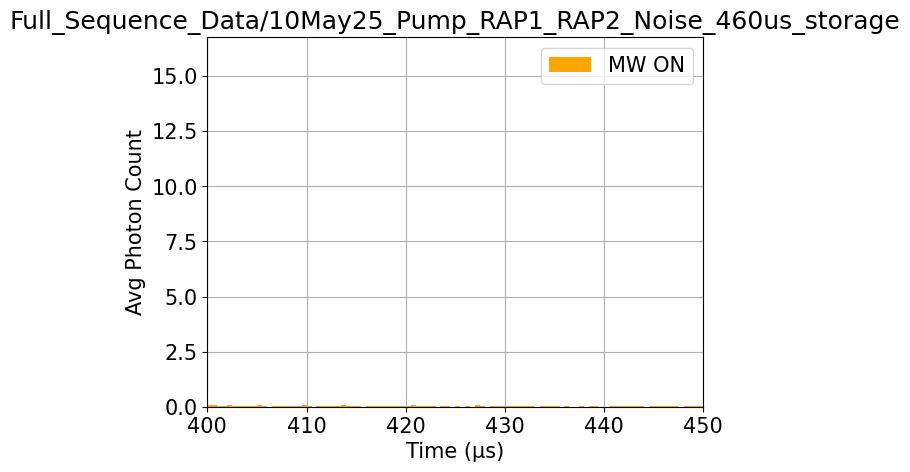

In [19]:
folder_path = 'Full_Sequence_Data/10May25_Pump_RAP1_RAP2_Noise_460us_storage'
photon_pulse_width = 18e-9  # 18 ns pulse width
photon_amplitude = 1      # 2.5 V amplitude
dead_time = 30e-9           # 35 ns dead time_arrafter each photon
time_bin = 0.5e-6             # 1 µs time_arrbin for histogram
# Aggregate all photon detection times
all_photon_times = []
# Get all bin files from the folder
AWG_file = "file"
bin_files = [f for f in os.listdir(folder_path) if f.startswith(AWG_file)]


# Process each CSV file
for file in bin_files:
    # print(f"Processing file: {file}")
    
    time_arr = plot_bin_file(folder_path, file)[0]   # First column: Time
    voltage = plot_bin_file(folder_path, file)[1]  # Second column: Voltage
    detection_indices = np.where(voltage >= photon_amplitude)[0]
    photon_times = []
    
    # Apply dead time_arr filtering
    if len(detection_indices) > 0:
        last_detection_time = time_arr[detection_indices[0]]
        photon_times.append(last_detection_time)
        for idx in detection_indices[1:]:
            if time_arr[idx] >= last_detection_time + dead_time:
                photon_times.append(time_arr[idx])
                last_detection_time = time_arr[idx]

    # Add photon times to the aggregated list
    all_photon_times.extend(photon_times)

# Convert all photon times to a single NumPy array
all_photon_times = np.array(all_photon_times)

# Bin photon detections into 1 µs time_arr bins
bins = np.arange(0, all_photon_times.max() + time_bin, time_bin)
histogram, edges = np.histogram(all_photon_times, bins=bins)

# Plot the final histogram
plt.bar(edges[:-1] * 1e6, histogram/len(bin_files), width=time_bin * 1e6, align="edge", color="orange", label = 'MW ON')
plt.xlabel("Time (µs)")
# plt.xlim([100,150])
plt.xlim([400,450])
# plt.xlim([40,60])
plt.ylabel("Avg Photon Count")
plt.title(folder_path)
plt.legend()
plt.grid(True)
# plt.savefig(folder_path+AWG_file +'.pdf')
# Show the histogram
plt.show()

RAP Ends at: 485
Pump at: 22
[576.0, 580.0, 584.0, 588.0, 592.0, 596.0, 600.0, 604.0, 608.0, 612.0, 616.0, 620.0, 624.0, 628.0, 632.0, 636.0, 640.0, 644.0, 648.0, 652.0, 656.0, 660.0, 664.0, 668.0, 672.0, 676.0, 680.0, 684.0, 688.0, 692.0, 696.0, 700.0, 704.0, 708.0, 712.0]
[np.float64(3.47), np.float64(1.49), np.float64(0.67), np.float64(0.57), np.float64(0.43), np.float64(0.52), np.float64(0.5), np.float64(0.37), np.float64(0.87), np.float64(1.3), np.float64(2.13), np.float64(2.89), np.float64(2.85), np.float64(1.27), np.float64(0.59), np.float64(0.39), np.float64(0.31), np.float64(0.4), np.float64(0.36), np.float64(0.38), np.float64(0.27), np.float64(0.23), np.float64(0.38), np.float64(0.35), np.float64(0.27), np.float64(0.26), np.float64(0.27), np.float64(0.25), np.float64(0.19), np.float64(0.37), np.float64(0.37), np.float64(0.56), np.float64(0.81), np.float64(1.51), np.float64(3.01)]
[np.float64(0.186), np.float64(0.122), np.float64(0.082), np.float64(0.075), np.float64(0.066), n

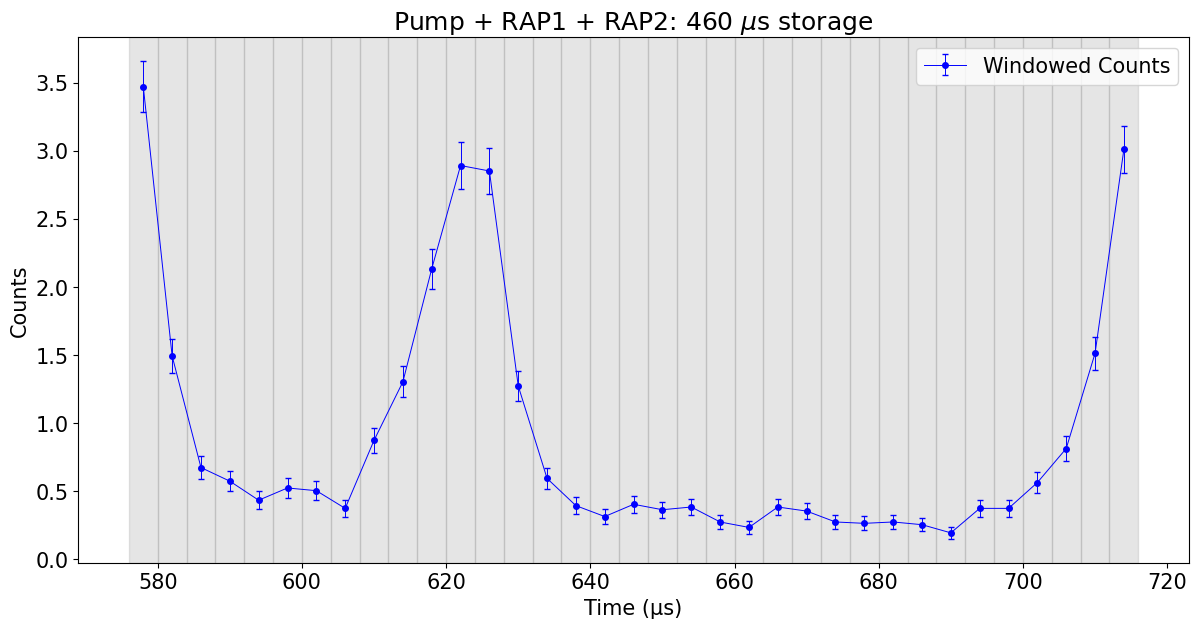

In [22]:
# Define window parameters
start_time = 576#492 #580 #836-2*(7.45+4)  # Start at 700μs
print('RAP Ends at:', 490-5)
print('Pump at:', 22)
# print('RAP Ends at:', 475-5)
# print('Pump at:', 48.5)
window_duration = 4  # 4μs duration
gap_duration = 0    # 6μs gap
num_windows =  35 #55    # Number of windows

# Initialize arrays to store results
window_starts = []
window_counts = []
window_errors = []


# Process each window
for i in range(num_windows):
    window_start = (start_time + i * (window_duration + gap_duration)) * 1000  # Convert to ns
    window_starts.append(window_start/1000)  # Store in μs for plotting
    
    # Initialize counts for this window
    counts = []
    
    # Process each file
    for file in bin_files:
        full_path = os.path.join(folder_path, file)
        count = read_gzip_counts_photons(full_path, window_start, window_duration*1000)
        counts.append(count)
    
    # Calculate mean and standard deviation
    mean_count = np.mean(counts)
    std_count = round(np.sqrt(np.mean(counts)/len(bin_files)),3)

    
    window_counts.append(mean_count)
    window_errors.append(std_count)

# window_starts = [x - 98 for x in window_starts]
print(window_starts)
print(window_counts)
print(window_errors)
# Create the plot
plt.figure(figsize=(12, 6))
# plt.figure(figsize=(5, 3))

plt.errorbar(window_starts+2*np.ones(len(window_starts)), window_counts, yerr=window_errors, fmt='o-', 
             alpha = 1, capsize=2, markersize=4, linewidth=0.7, elinewidth=0.7, color='blue', label='Windowed Counts')

# Add vertical spans to show windows
for start in window_starts:
    plt.axvspan(start, start + window_duration, alpha=0.2, color='gray')

plt.tight_layout()

# Adjust plot appearance
plt.xlabel('Time (μs)')
plt.ylabel('Counts')
# plt.yticks(np.arange(0, 3.1, 0.5))
plt.title(r'Pump + RAP1 + RAP2: 460 $\mu$s storage')
# plt.grid(True, alpha=0.3)
# plt.xlim([714, 850])
plt.legend()
# plt.tight_layout()
# plt.savefig(folder_path+'windowed.pdf')
plt.show()

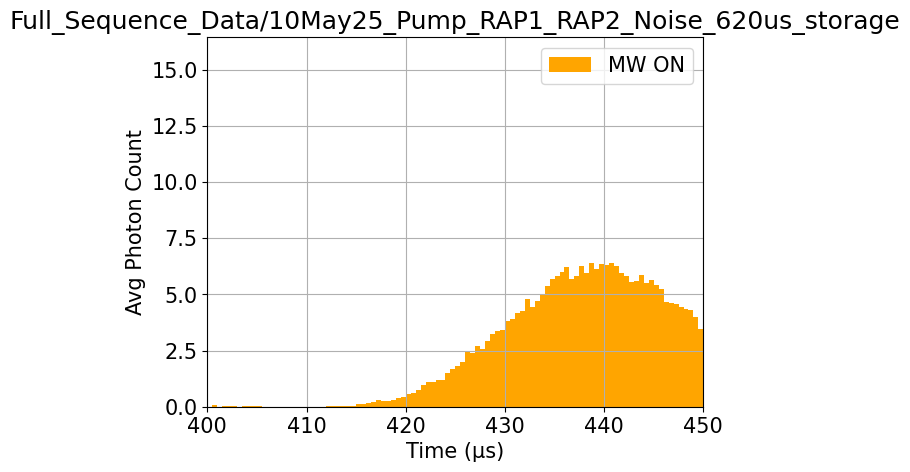

In [23]:
folder_path = 'Full_Sequence_Data/10May25_Pump_RAP1_RAP2_Noise_620us_storage'
photon_pulse_width = 18e-9  # 18 ns pulse width
photon_amplitude = 1      # 2.5 V amplitude
dead_time = 30e-9           # 35 ns dead time_arrafter each photon
time_bin = 0.5e-6             # 1 µs time_arrbin for histogram
# Aggregate all photon detection times
all_photon_times = []
# Get all bin files from the folder
AWG_file = "file"
bin_files = [f for f in os.listdir(folder_path) if f.startswith(AWG_file)]


# Process each CSV file
for file in bin_files:
    # print(f"Processing file: {file}")
    
    time_arr = plot_bin_file(folder_path, file)[0]   # First column: Time
    voltage = plot_bin_file(folder_path, file)[1]  # Second column: Voltage
    detection_indices = np.where(voltage >= photon_amplitude)[0]
    photon_times = []
    
    # Apply dead time_arr filtering
    if len(detection_indices) > 0:
        last_detection_time = time_arr[detection_indices[0]]
        photon_times.append(last_detection_time)
        for idx in detection_indices[1:]:
            if time_arr[idx] >= last_detection_time + dead_time:
                photon_times.append(time_arr[idx])
                last_detection_time = time_arr[idx]

    # Add photon times to the aggregated list
    all_photon_times.extend(photon_times)

# Convert all photon times to a single NumPy array
all_photon_times = np.array(all_photon_times)

# Bin photon detections into 1 µs time_arr bins
bins = np.arange(0, all_photon_times.max() + time_bin, time_bin)
histogram, edges = np.histogram(all_photon_times, bins=bins)

# Plot the final histogram
plt.bar(edges[:-1] * 1e6, histogram/len(bin_files), width=time_bin * 1e6, align="edge", color="orange", label = 'MW ON')
plt.xlabel("Time (µs)")
# plt.xlim([100,150])
plt.xlim([400,450])
# plt.xlim([40,60])
plt.ylabel("Avg Photon Count")
plt.title(folder_path)
plt.legend()
plt.grid(True)
# plt.savefig(folder_path+AWG_file +'.pdf')
# Show the histogram
plt.show()

RAP Ends at: 485
Pump at: 22
[492.0, 496.0, 500.0, 504.0, 508.0, 512.0, 516.0, 520.0, 524.0, 528.0, 532.0, 536.0, 540.0, 544.0, 548.0, 552.0, 556.0, 560.0, 564.0, 568.0, 572.0, 576.0, 580.0, 584.0, 588.0, 592.0, 596.0, 600.0, 604.0, 608.0, 612.0, 616.0, 620.0, 624.0, 628.0, 632.0, 636.0, 640.0, 644.0, 648.0, 652.0, 656.0, 660.0, 664.0, 668.0, 672.0, 676.0, 680.0, 684.0, 688.0, 692.0, 696.0, 700.0, 704.0, 708.0]
[np.float64(2.19), np.float64(1.04), np.float64(0.65), np.float64(0.47), np.float64(0.48), np.float64(0.35), np.float64(0.31), np.float64(0.35), np.float64(0.61), np.float64(1.3), np.float64(2.58), np.float64(2.47), np.float64(1.79), np.float64(0.98), np.float64(0.36), np.float64(0.25), np.float64(0.3), np.float64(0.32), np.float64(0.35), np.float64(0.27), np.float64(0.34), np.float64(0.24), np.float64(0.28), np.float64(0.33), np.float64(0.25), np.float64(0.29), np.float64(0.28), np.float64(0.28), np.float64(0.28), np.float64(0.28), np.float64(0.24), np.float64(0.26), np.float64

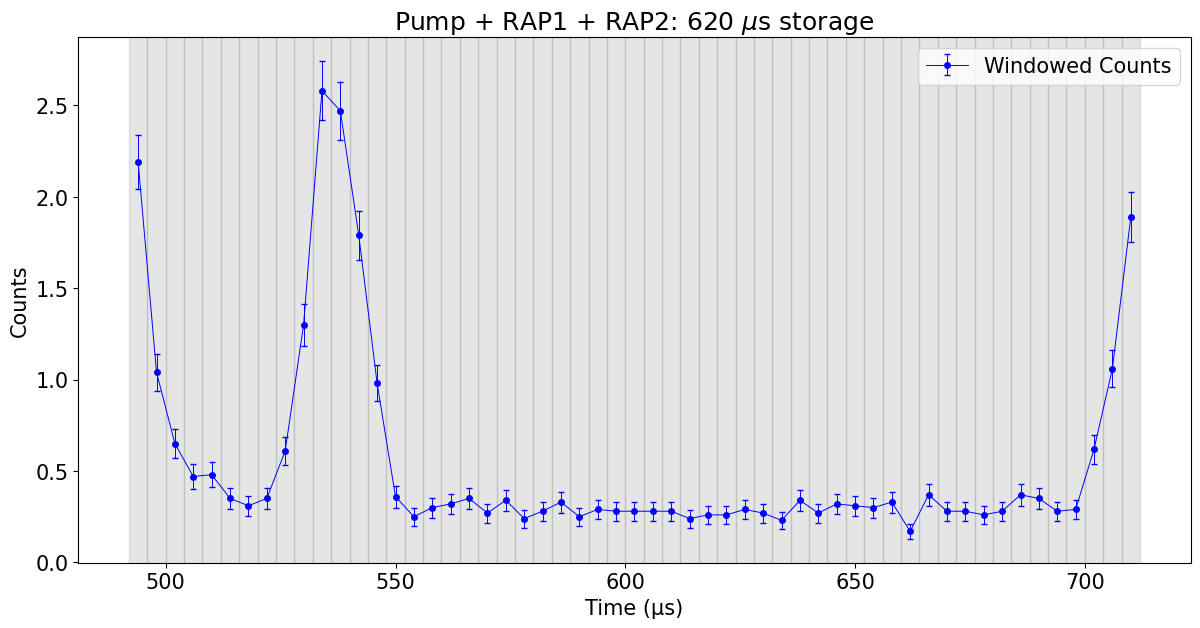

In [24]:
# Define window parameters
start_time = 492
print('RAP Ends at:', 490-5)
print('Pump at:', 22)
# print('RAP Ends at:', 475-5)
# print('Pump at:', 48.5)
window_duration = 4  # 4μs duration
gap_duration = 0    # 6μs gap
num_windows =  55    # Number of windows

# Initialize arrays to store results
window_starts = []
window_counts = []
window_errors = []


# Process each window
for i in range(num_windows):
    window_start = (start_time + i * (window_duration + gap_duration)) * 1000  # Convert to ns
    window_starts.append(window_start/1000)  # Store in μs for plotting
    
    # Initialize counts for this window
    counts = []
    
    # Process each file
    for file in bin_files:
        full_path = os.path.join(folder_path, file)
        count = read_gzip_counts_photons(full_path, window_start, window_duration*1000)
        counts.append(count)
    
    # Calculate mean and standard deviation
    mean_count = np.mean(counts)
    std_count = round(np.sqrt(np.mean(counts)/len(bin_files)),3)

    
    window_counts.append(mean_count)
    window_errors.append(std_count)

# window_starts = [x - 98 for x in window_starts]
print(window_starts)
print(window_counts)
print(window_errors)
# Create the plot
plt.figure(figsize=(12, 6))
# plt.figure(figsize=(5, 3))

plt.errorbar(window_starts+2*np.ones(len(window_starts)), window_counts, yerr=window_errors, fmt='o-', 
             alpha = 1, capsize=2, markersize=4, linewidth=0.7, elinewidth=0.7, color='blue', label='Windowed Counts')

# Add vertical spans to show windows
for start in window_starts:
    plt.axvspan(start, start + window_duration, alpha=0.2, color='gray')

plt.tight_layout()

# Adjust plot appearance
plt.xlabel('Time (μs)')
plt.ylabel('Counts')
# plt.yticks(np.arange(0, 3.1, 0.5))
plt.title(r'Pump + RAP1 + RAP2: 620 $\mu$s storage')
# plt.grid(True, alpha=0.3)
# plt.xlim([714, 850])
plt.legend()
# plt.tight_layout()
# plt.savefig(folder_path+'windowed.pdf')
plt.show()

#### Full Span

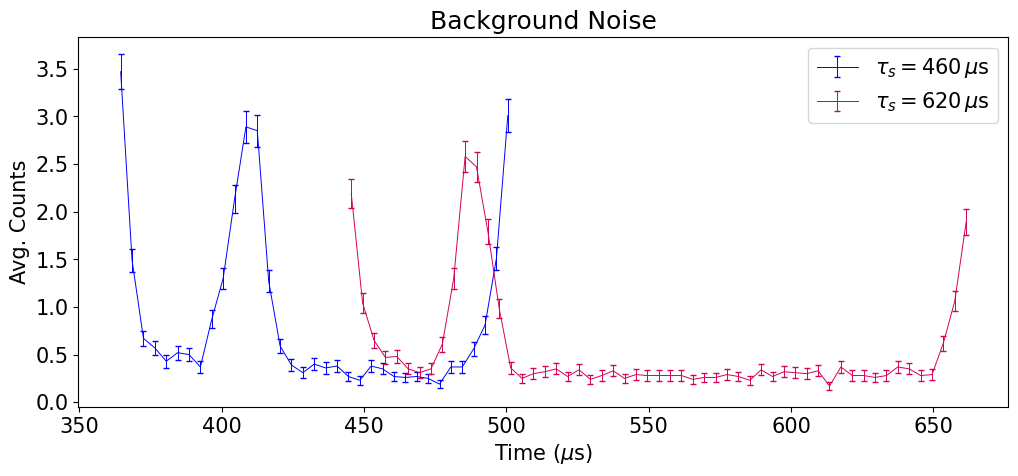

In [17]:
# # Data on 10-May-2025

pump_rap1_rap2_460us_times = -213.5 + np.array([576.0, 580.0, 584.0, 588.0, 592.0, 596.0, 600.0, 604.0, 608.0, 612.0, 616.0, 620.0, 624.0, 628.0, 632.0, 636.0, 640.0, 644.0, 648.0, 652.0, 656.0, 660.0, 664.0, 668.0, 672.0, 676.0, 680.0, 684.0, 688.0, 692.0, 696.0, 700.0, 704.0, 708.0, 712.0])
# RAP ends at 555us, Pump at 213.5us

pump_rap1_rap2_460us_noise = np.array([3.47, 1.49, 0.67, 0.57, 0.43, 0.52, 0.5 , 0.37, 0.87, 1.3 , 2.13,
       2.89, 2.85, 1.27, 0.59, 0.39, 0.31, 0.4 , 0.36, 0.38, 0.27, 0.23,
       0.38, 0.35, 0.27, 0.26, 0.27, 0.25, 0.19, 0.37, 0.37, 0.56, 0.81,
       1.51, 3.01])
pump_rap1_rap2_460us_noise_std = np.array([0.186, 0.122, 0.082, 0.075, 0.066, 0.072, 0.071, 0.061, 0.093,
       0.114, 0.146, 0.17 , 0.169, 0.113, 0.077, 0.062, 0.056, 0.063,
       0.06 , 0.062, 0.052, 0.048, 0.062, 0.059, 0.052, 0.051, 0.052,
       0.05 , 0.044, 0.061, 0.061, 0.075, 0.09 , 0.123, 0.173])

# RAP ends at 470us, Pump at 48.5us
pump_rap1_rap2_620us_times = -48.5 + np.array([492.0, 496.0, 500.0, 504.0, 508.0, 512.0, 516.0, 520.0, 524.0, 528.0, 532.0, 536.0, 540.0, 544.0, 548.0, 552.0, 556.0, 560.0, 564.0, 568.0, 572.0, 576.0, 580.0, 584.0, 588.0, 592.0, 596.0, 600.0, 604.0, 608.0, 612.0, 616.0, 620.0, 624.0, 628.0, 632.0, 636.0, 640.0, 644.0, 648.0, 652.0, 656.0, 660.0, 664.0, 668.0, 672.0, 676.0, 680.0, 684.0, 688.0, 692.0, 696.0, 700.0, 704.0, 708.0])
pump_rap1_rap2_620us_noise = np.array([2.19, 1.04, 0.65, 0.47, 0.48, 0.35, 0.31, 0.35, 0.61, 1.3 , 2.58,
       2.47, 1.79, 0.98, 0.36, 0.25, 0.3 , 0.32, 0.35, 0.27, 0.34, 0.24,
       0.28, 0.33, 0.25, 0.29, 0.28, 0.28, 0.28, 0.28, 0.24, 0.26, 0.26,
       0.29, 0.27, 0.23, 0.34, 0.27, 0.32, 0.31, 0.3 , 0.33, 0.17, 0.37,
       0.28, 0.28, 0.26, 0.28, 0.37, 0.35, 0.28, 0.29, 0.62, 1.06, 1.89])
pump_rap1_rap2_620us_noise_std = np.array([0.148, 0.102, 0.081, 0.069, 0.069, 0.059, 0.056, 0.059, 0.078,
       0.114, 0.161, 0.157, 0.134, 0.099, 0.06 , 0.05 , 0.055, 0.057,
       0.059, 0.052, 0.058, 0.049, 0.053, 0.057, 0.05 , 0.054, 0.053,
       0.053, 0.053, 0.053, 0.049, 0.051, 0.051, 0.054, 0.052, 0.048,
       0.058, 0.052, 0.057, 0.056, 0.055, 0.057, 0.041, 0.061, 0.053,
       0.053, 0.051, 0.053, 0.061, 0.059, 0.053, 0.054, 0.079, 0.103,
       0.137])

plt.figure(figsize=(10*1.2, 4*1.2))

plt.errorbar(pump_rap1_rap2_460us_times+2*np.ones(len(pump_rap1_rap2_460us_times)), 
            pump_rap1_rap2_460us_noise, yerr=pump_rap1_rap2_460us_noise_std, fmt='-',
            alpha = 1, capsize=2, markersize=4, linewidth=0.7, elinewidth=0.7, 
            color='blue', label=r'$\tau_s = 460\, \mu$s')
plt.errorbar(pump_rap1_rap2_620us_times+2*np.ones(len(pump_rap1_rap2_620us_times)), 
            pump_rap1_rap2_620us_noise, yerr=pump_rap1_rap2_620us_noise_std, fmt='-',
            alpha = 1, capsize=2, markersize=4, linewidth=0.7, elinewidth=0.7, 
            color='#d60057', label=r'$\tau_s = 620\, \mu$s')
plt.xlabel(r'Time ($\mu$s)')
plt.ylabel(r'Avg. Counts')
plt.title('Background Noise')
plt.legend()
# plt.savefig('Plots/Background_Noise_Both_RAPs.pdf')
plt.show()


#### Zoom In

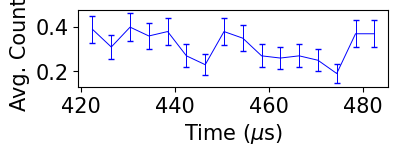

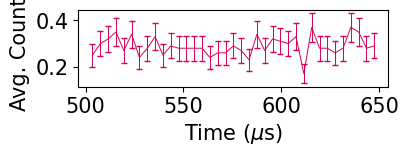

In [20]:
# Plot the first data
plt.figure(figsize=(4, 1))
ax1 = plt.gca()
mask_460 = (pump_rap1_rap2_460us_times >= 420) & (pump_rap1_rap2_460us_times <= 485)
ax1.errorbar(pump_rap1_rap2_460us_times[mask_460], pump_rap1_rap2_460us_noise[mask_460], 
                     yerr=pump_rap1_rap2_460us_noise_std[mask_460], fmt='-', alpha=1, 
                     capsize=2, markersize=4, linewidth=0.7, elinewidth=0.7, color='blue', 
                     label='460 µs Storage Time')
plt.xlabel(r'Time ($\mu$s)')
plt.ylabel('Avg. Counts')
# plt.savefig('Plots/Background_Noise_Both_RAPs_zoom_460.pdf')
plt.show()



# Plot the second data
plt.figure(figsize=(4, 1))
ax1 = plt.gca()
mask_620 = (pump_rap1_rap2_620us_times >= 500) & (pump_rap1_rap2_620us_times <= 650)
ax1.errorbar(pump_rap1_rap2_620us_times[mask_620], pump_rap1_rap2_620us_noise[mask_620], 
                     yerr=pump_rap1_rap2_620us_noise_std[mask_620], fmt='-', alpha=1, 
                     capsize=2, markersize=4, linewidth=0.7, elinewidth=0.7, color='#d60057', 
                     label='620 µs Storage Time')

plt.xlabel(r'Time ($\mu$s)')
plt.ylabel('Avg. Counts')
# plt.savefig('Plots/Background_Noise_Both_RAPs_zoom_620.pdf')
plt.show()

# Power Dependencies -- SI Fig S7

## Optical Power Measurements

In [ ]:
# Manually measured power values at different points in the sequence, normalized to the pump power (1 at pump time)
Op_power_dict = {
    0: 0,
    0.1: 68.7,
    0.2: 275,
    0.3: 619,
    0.4: 1061,
    0.5: 1580,
    0.6: 2187,
    0.7: 2700,
    0.8: 3150,
    0.9: 3480,
    1: 3790
}
Op_power_dict = {key: value for key, value in Op_power_dict.items()}
midpoints = {round((k1 + k2) / 2, 2): (v1 + v2) / 2 for (k1, v1), (k2, v2) in zip(list(Op_power_dict.items())[:-1], list(Op_power_dict.items())[1:])}
Op_power_dict.update(midpoints)
Op_power_dict = dict(sorted(Op_power_dict.items()))
Op_power_dict_modified = {round(key*100): value*3400/3790  for key, value in Op_power_dict.items()}
Op_power_dict_modified

{0: 0.0,
 5: 30.815303430079155,
 10: 61.63060686015831,
 15: 154.16622691292875,
 20: 246.70184696569922,
 25: 401.00263852242745,
 30: 555.3034300791556,
 35: 753.5620052770448,
 40: 951.820580474934,
 45: 1184.617414248021,
 50: 1417.4142480211083,
 55: 1689.6833773087071,
 60: 1961.952506596306,
 65: 2192.0580474934036,
 70: 2422.1635883905014,
 75: 2624.01055408971,
 80: 2825.857519788918,
 85: 2973.8786279683377,
 90: 3121.8997361477573,
 95: 3260.9498680738784,
 100: 3400.0}

## RAP Power Dependence

### RAP Power Data extraction

[np.float64(0.05), np.float64(0.07), np.float64(0.04), np.float64(0.13), np.float64(0.07), np.float64(0.26), np.float64(0.71), np.float64(1.48), np.float64(2.26), np.float64(2.34), np.float64(2.29), np.float64(1.56)]
[np.float64(0.022), np.float64(0.026), np.float64(0.02), np.float64(0.036), np.float64(0.026), np.float64(0.051), np.float64(0.084), np.float64(0.122), np.float64(0.15), np.float64(0.153), np.float64(0.151), np.float64(0.125)]


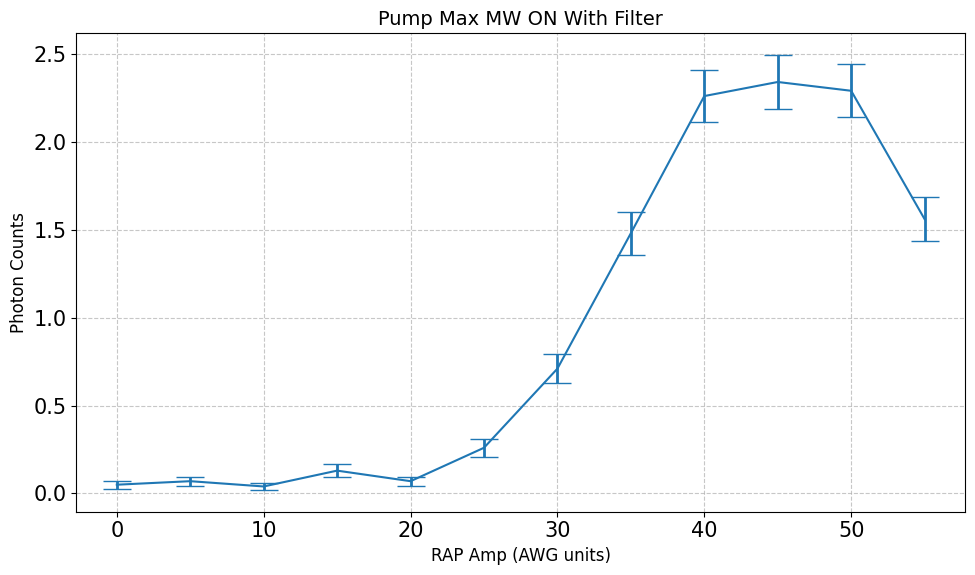

In [ ]:
# Configuration
folder_name = 'Full_Sequence_Data/10May25_RAP_Pwr_sinc'
data_dir = folder_name  # Update this path
file_pattern = re.compile(r'AWG_([\d\.]+)_f_(\d+)\.gzip')  # Adjust pattern to match your filenames

# Data storage dictionaries
amp_groups = {}
results = {}
results_std = {}

# Group files by amplitude
for filename in os.listdir(data_dir):
    match = file_pattern.match(filename)
    if match:
        # temp = float(match.group(1))  # Handle decimal amplitudes if needed
        # amp = MW_photon_dict[int(temp)]*1e-16
        # amp = round(amp, 0)
        amp = float(match.group(1))
        file_num = int(match.group(2))
        full_path = os.path.join(data_dir, filename)
        
        if amp not in amp_groups:
            amp_groups[amp] = []
        amp_groups[amp].append(full_path)

# Process each amplitude group
for amp, files in amp_groups.items():
    counts = []
    for file in sorted(files, key=lambda x: int(re.search(r'_(\d+)\.', x).group(1))):
        counts.append(read_gzip_counts_photons(file, 467e3, 4e3)) # 467 ns to 471 ns
        # counts.append(read_gzip_counts_photons(file, 930e3, 4e3)) # 467 ns to 471 ns
        # print(file)
    
    results[amp] = np.mean(counts)
    # results_std[amp]=np.std(counts)
    results_std[amp]=np.sqrt(np.mean(counts)/len(files))

# Sort results by amplitude
sorted_amps = sorted(results.keys())
sorted_means = [round(results[amp], 3) for amp in sorted_amps]
sorted_stds = [round(results_std[amp], 3) for amp in sorted_amps]
print(sorted_means)
print(sorted_stds)

plt.figure(figsize=(10, 6))
plt.errorbar(sorted_amps, sorted_means, sorted_stds , capsize=10,  elinewidth=2, markersize=8)

plt.ylabel(r"Photon Counts", fontsize=12)
plt.xlabel(r"RAP Amp (AWG units)", fontsize=12)
plt.title(r"Pump Max MW ON", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
# Save and show plot
# plt.savefig(data_dir +"RAP_Pwr_optimization.png", dpi=300)
plt.show()

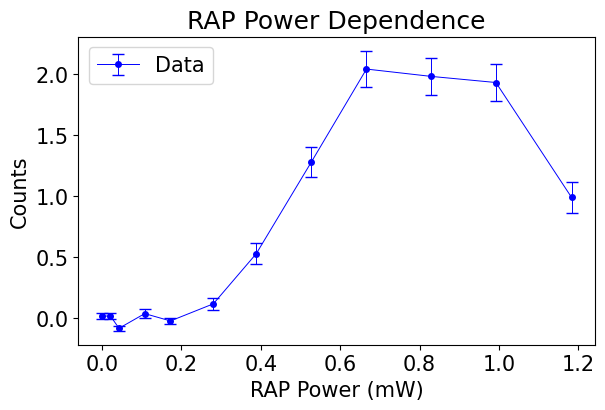

In [24]:
Op_power_dict_modified = {round(key*100): value*3400/3790 *0.7  for key, value in Op_power_dict.items()}

amp_RAP_pwr = [0.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 35.0, 40.0, 45.0, 50.0, 55.0]
amp_RAP_pwr = np.array([Op_power_dict_modified.get(key)*1e-3 for key in amp_RAP_pwr])


# Data on 10May2025 - folder - 'RAP_Pwr_sinc'
noise_floor = np.array([0.03, 0.05, 0.12, 0.09, 0.09, 0.14, 0.18, 0.2, 0.22, 0.36, 0.36, 0.57])
RAP_pwr_Pump_Max =  np.array([0.05, 0.07, 0.04, 0.13, 0.07, 0.26, 0.71, 1.48, 2.26, 2.34, 2.29, 1.56])
RAP_pwr_Pump_Max = RAP_pwr_Pump_Max - noise_floor
RAP_pwr_Pump_Max_std = np.array([0.022, 0.026, 0.02, 0.036, 0.026, 0.051, 0.084, 0.122, 0.15, 0.153, 0.151, 0.125])

# RAP Power Dependence
plt.figure(figsize=(20/3, 4))
plt.errorbar(amp_RAP_pwr, RAP_pwr_Pump_Max, RAP_pwr_Pump_Max_std,
             capsize=4, elinewidth=0.7, linewidth=0.7, markersize=4, label='Data', color='blue', marker='o')

# # plt.ylim(0, 100)
plt.xlabel(r'RAP Power (mW)')
plt.ylabel('Counts')
plt.title('RAP Power Dependence')
plt.legend()
# plt.savefig('Plots/RAP_Power_Pump_Max_noise_subtracted.pdf')
plt.show()

## Pump Power

### Pump Power Data extraction

Sorted Means: [np.float64(0.3), np.float64(0.26), np.float64(0.3), np.float64(0.43), np.float64(0.71), np.float64(0.79), np.float64(0.92), np.float64(1.27), np.float64(1.22), np.float64(1.45), np.float64(1.53)]
Sorted Stds: [np.float64(0.055), np.float64(0.051), np.float64(0.055), np.float64(0.066), np.float64(0.084), np.float64(0.089), np.float64(0.096), np.float64(0.113), np.float64(0.11), np.float64(0.12), np.float64(0.124)]
Sorted Noise Means: [np.float64(0.25), np.float64(0.24), np.float64(0.21), np.float64(0.29), np.float64(0.43), np.float64(0.26), np.float64(0.24), np.float64(0.34), np.float64(0.35), np.float64(0.27), np.float64(0.29)]


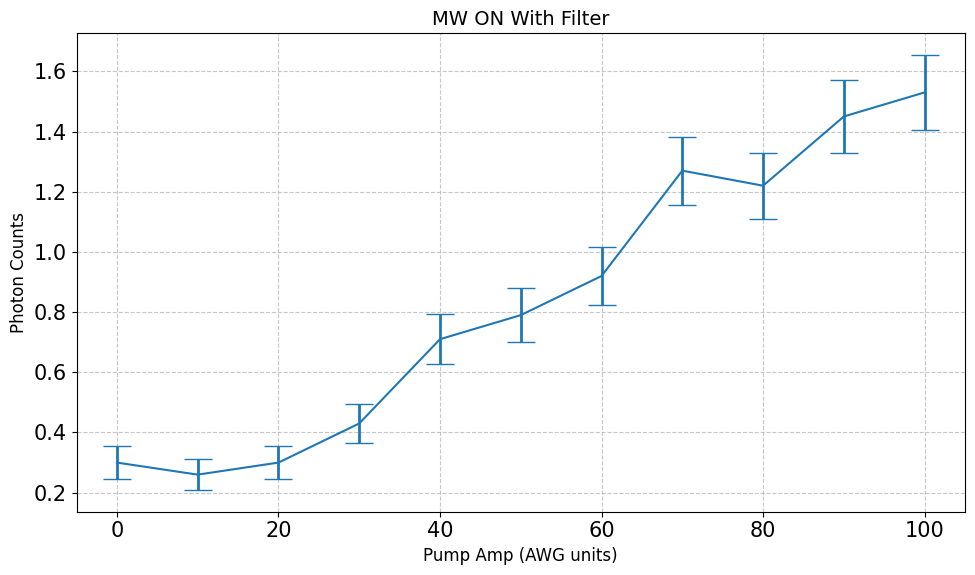

In [29]:
folder_name = 'Full_Sequence_Data/10May25_Pump_Pwr_sinc_2'
# Configuration
data_dir = folder_name  # Update this path
file_pattern = re.compile(r'AWG_([\d\.]+)_f_(\d+)\.gzip')  # Adjust pattern to match your filenames

# Data storage dictionaries
amp_groups = {}
results = {}
results_std = {}
results_noise = {}

# Group files by amplitude
for filename in os.listdir(data_dir):
    match = file_pattern.match(filename)
    if match:
        # temp = float(match.group(1))  # Handle decimal amplitudes if needed
        # amp = MW_photon_dict[int(temp)]*1e-16
        # amp = round(amp, 0)
        amp = float(match.group(1))
        file_num = int(match.group(2))
        full_path = os.path.join(data_dir, filename)
        
        if amp not in amp_groups:
            amp_groups[amp] = []
        amp_groups[amp].append(full_path)

# Process each amplitude group
for amp, files in amp_groups.items():
    counts = []
    noise_counts = []
    for file in sorted(files, key=lambda x: int(re.search(r'_(\d+)\.', x).group(1))):
        counts.append(read_gzip_counts_photons(file, 467e3, 4e3)) # 467 ns to 471 ns - echo
        noise_counts.append(read_gzip_counts_photons(file, 477e3, 4e3)) 
        # print(file)
    
    results[amp] = np.mean(counts)
    # results_std[amp]=np.std(counts)
    results_std[amp]=np.sqrt(np.mean(counts)/len(files))
    results_noise[amp] = np.mean(noise_counts)
# Sort results by amplitude
sorted_amps = sorted(results.keys())
sorted_means = [round(results[amp], 3) for amp in sorted_amps]
sorted_noise_means = [round(results_noise[amp], 3) for amp in sorted_amps]
sorted_stds = [round(results_std[amp], 3) for amp in sorted_amps]
print('Sorted Means:', sorted_means)
print('Sorted Stds:', sorted_stds)
print('Sorted Noise Means:', sorted_noise_means)

plt.figure(figsize=(10, 6))
plt.errorbar(sorted_amps, sorted_means, sorted_stds , capsize=10,  elinewidth=2, markersize=8)
# plt.plot(sorted_amps, sorted_means, 'bo-', linewidth=2, markersize=8)
# plt.semilogx()
# plt.xlabel(r"Input MW Photons ($\times 10^{16}$)", fontsize=12)
plt.ylabel(r"Photon Counts", fontsize=12)
plt.xlabel(r"Pump Amp (AWG units)", fontsize=12)
plt.title(r"MW ON With Filter", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
# plt.xticks(sorted_amps)  # Show all amplitude values on x-axis
plt.tight_layout()
# plt.xticks(sorted_amps, rotation=45)  # Rotate by 45 degrees

# plt.semilogy()

# Save and show plot
# plt.savefig(data_dir +"pump_pwr.png", dpi=300)
plt.show()

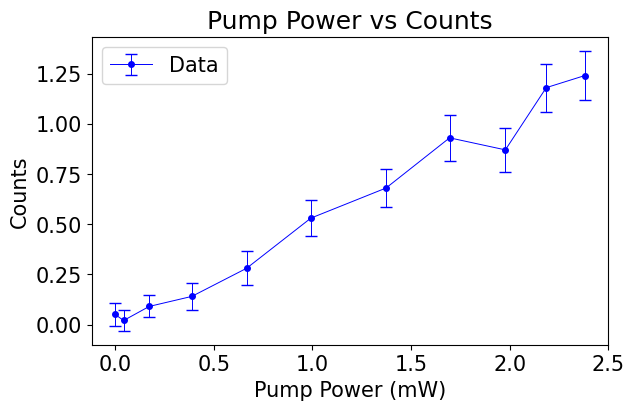

In [25]:
Op_power_dict_modified = {key*100: value*3400/3790*0.7  for key, value in Op_power_dict.items()}

amp_pump_pwr = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
amp_pump_pwr = [Op_power_dict_modified.get(key)*1e-3 for key in amp_pump_pwr]

# Data on 10May25 folder = 'Pump_Pwr_sinc_2'
noise_floor = np.array([0.25, 0.24, 0.21, 0.29, 0.43, 0.26, 0.24, 0.34, 0.35, 0.27, 0.29])
Pump_pwr = np.array([0.3, 0.26, 0.3, 0.43, 0.71, 0.79, 0.92, 1.27, 1.22, 1.45, 1.53])
Pump_pwr = Pump_pwr - noise_floor
Pump_pwr_std =np.array([0.055, 0.051, 0.055, 0.066, 0.084, 0.089, 0.096, 0.113, 0.11, 0.12, 0.124])

# Pump Power
plt.figure(figsize=(20/3, 4))
plt.errorbar(amp_pump_pwr, Pump_pwr, Pump_pwr_std,
             capsize=4, elinewidth=0.7, linewidth=0.7, markersize=4, color='blue', marker='o', label='Data')

plt.xlabel('Pump Power (mW)')
plt.ylabel('Counts')
plt.title('Pump Power vs Counts')
plt.legend()
plt.xticks(np.linspace(0,2.5, 6))
# plt.savefig('Plots/Pump_Power.pdf')
plt.show()

## MW Power

### MW Power Data extraction

[np.float64(0.46), np.float64(0.56), np.float64(0.67), np.float64(1.05), np.float64(1.16), np.float64(1.73), np.float64(1.87), np.float64(2.29), np.float64(3.07), np.float64(3.77), np.float64(4.14)]
[np.float64(0.068), np.float64(0.075), np.float64(0.082), np.float64(0.102), np.float64(0.108), np.float64(0.132), np.float64(0.137), np.float64(0.151), np.float64(0.175), np.float64(0.194), np.float64(0.203)]


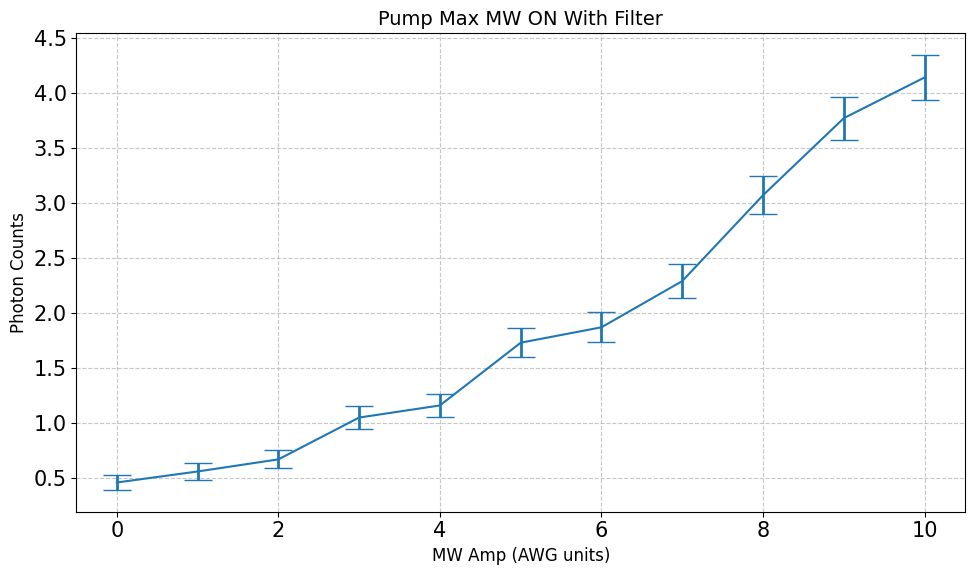

In [31]:
folder_name = 'Full_Sequence_Data/10May25_MW_Pulse_Pwr_sinc'
# Configuration
data_dir = folder_name  # Update this path
file_pattern = re.compile(r'AWG_([\d\.]+)u_f_(\d+)\.gzip')  # Adjust pattern to match your filenames

# Data storage dictionaries
amp_groups = {}
results = {}
results_std = {}

# Group files by amplitude
for filename in os.listdir(data_dir):
    match = file_pattern.match(filename)
    if match:
        # temp = float(match.group(1))  # Handle decimal amplitudes if needed
        # amp = MW_photon_dict[int(temp)]*1e-16
        # amp = round(amp, 0)
        amp = float(match.group(1))
        file_num = int(match.group(2))
        full_path = os.path.join(data_dir, filename)
        
        if amp not in amp_groups:
            amp_groups[amp] = []
        amp_groups[amp].append(full_path)

# Process each amplitude group
for amp, files in amp_groups.items():
    counts = []
    for file in sorted(files, key=lambda x: int(re.search(r'_(\d+)\.', x).group(1))):
        counts.append(read_gzip_counts_photons(file, 467e3, 4e3)) # 467 ns to 471 ns
        # print(file)
    
    results[amp] = np.mean(counts)
    # results_std[amp]=np.std(counts)
    results_std[amp]=np.sqrt(np.mean(counts)/len(files))

# Sort results by amplitude
sorted_amps = sorted(results.keys())
sorted_means = [round(results[amp], 3) for amp in sorted_amps]
sorted_stds = [round(results_std[amp], 3) for amp in sorted_amps]
print(sorted_means)
print(sorted_stds)

plt.figure(figsize=(10, 6))
plt.errorbar(sorted_amps, sorted_means, sorted_stds , capsize=10,  elinewidth=2, markersize=8)
# plt.plot(sorted_amps, sorted_means, 'bo-', linewidth=2, markersize=8)
# plt.semilogx()
# plt.xlabel(r"Input MW Photons ($\times 10^{16}$)", fontsize=12)
plt.ylabel(r"Photon Counts", fontsize=12)
plt.xlabel(r"MW Amp (AWG units)", fontsize=12)
plt.title(r"Pump Max MW ON With Filter", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
# plt.xticks(sorted_amps)  # Show all amplitude values on x-axis
plt.tight_layout()
# plt.xticks(sorted_amps, rotation=45)  # Rotate by 45 degrees

# plt.semilogy()

# Save and show plot
# plt.savefig(data_dir +"MW_pwr.png", dpi=300)
plt.show()

C:\Users\quant\AppData\Local\Temp\ipykernel_27392\1899815979.py:8: RuntimeWarning: divide by zero encountered in log10
  MW_power_dict = {int(key): 10*np.log10((value/1e3)**2/(8*50)*1e3)+line_loss for key, value in MW_mVpp_dict.items()}


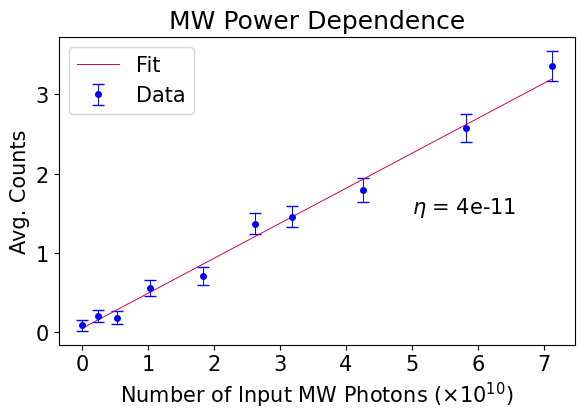

Slope = 0.442 ± 0.018
Intercept = 0.050 ± 0.040


In [3]:
Amplitude = np.array([0.1, 0.09, 0.08, 0.07, 0.06, 0.05, 0.04, 0.03, 0.02, 0.01, 0])
mVpp_mean = np.array([32.955, 29.2, 26.4, 22.6, 19.518, 17.74, 14.798, 11.123, 7.996, 5.404, 1e-8])
MW_mVpp_dict = {float(amp): float(mVpp) for amp, mVpp in zip(Amplitude, mVpp_mean)}

MW_mVpp_dict = {int(key * 100): round(value, 2) for key, value in MW_mVpp_dict.items()}
# MW_mVpp_dict
line_loss = -6-2-0.19*2-2-5.20 + 2.5  # Black Cable+ switch+2*short blue cables+circulator+DL line Loss + amp-mVpp Characterization Cable Loss
MW_power_dict = {int(key): 10*np.log10((value/1e3)**2/(8*50)*1e3)+line_loss for key, value in MW_mVpp_dict.items()}
MW_photon_dict = {key: 10**(value/10 -3) /6.626e-34/ 2623.35e6 for key, value in MW_power_dict.items()}


mw_amplitude = [0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]
mw_amplitude = [MW_photon_dict.get(key)*0.59 *2e-6*1e-10 for key in mw_amplitude]

# Data on 10May25
noise_floor = np.array([0.37, 0.36, 0.49, 0.49, 0.45, 0.36, 0.41, 0.49, 0.49, 0.41])
mw_counts = np.array([0.46, 0.56, 0.67, 1.05, 1.16, 1.73, 1.87, 2.29, 3.07, 3.77])
mw_counts = mw_counts - noise_floor
mw_counts_std = np.array([0.068, 0.075, 0.082, 0.102, 0.108, 0.132, 0.137, 0.151, 0.175, 0.194]) 

# Linear fit
def linear_func(x, a, b):
    return a * x + b

# Perform the fit
popt, pcov = curve_fit(linear_func, mw_amplitude, mw_counts, sigma=mw_counts_std)
perr = np.sqrt(np.diag(pcov))

# Generate points for smooth curve
x_fit = np.linspace(min(mw_amplitude), max(mw_amplitude), 100)
y_fit = linear_func(x_fit, *popt)

# Plot results
plt.figure(figsize=(20/3, 4))
plt.errorbar(mw_amplitude, mw_counts, yerr=mw_counts_std, fmt='o', 
            color='blue', markersize=4, capsize=4, elinewidth=0.7, label='Data')
plt.plot(x_fit, y_fit, '-', color='#d60057', 
         linewidth=0.7, label='Fit')

plt.xlabel(r'Number of Input MW Photons ($\times 10^{10}$)')
plt.ylabel('Avg. Counts')
plt.text(5, 1.5,r'$\eta$'+ f' = {1e-10*popt[0]:.0e}')
plt.title('MW Power Dependence')
plt.legend()
# plt.savefig('Plots/MW_Power.pdf')
plt.show()

print(f'Slope = {popt[0]:.3f} ± {perr[0]:.3f}')
print(f'Intercept = {popt[1]:.3f} ± {perr[1]:.3f}')

# Durations

## Pump Pulse Duration

### Data Extraction

Sorted Amplitudes: [0.2 0.4 0.6 0.8 1.  1.2 1.4 1.6 1.8 2.  2.2 2.4 2.6 2.8 3.  3.2 3.4 3.6
 3.8 4.  4.2 4.4 4.6 4.8 5.  5.2 5.4 5.6 5.8 6. ]
Sorted Means: [0.3  0.51 0.5  0.48 0.45 0.5  0.61 0.61 0.89 0.83 1.19 1.16 1.32 1.47
 1.61 1.67 1.87 1.68 2.03 2.26 1.9  2.2  2.26 2.44 2.2  1.99 2.22 2.44
 2.05 2.28]
Sorted Stds: [0.055 0.071 0.071 0.069 0.067 0.071 0.078 0.078 0.094 0.091 0.109 0.108
 0.115 0.121 0.127 0.129 0.137 0.13  0.142 0.15  0.138 0.148 0.15  0.156
 0.148 0.141 0.149 0.156 0.143 0.151]
Sorted Noise Means: [0.45 0.48 0.42 0.52 0.38 0.39 0.42 0.43 0.43 0.38 0.38 0.51 0.4  0.52
 0.48 0.5  0.56 0.56 0.35 0.28 0.42 0.42 0.64 0.36 0.39 0.44 0.49 0.52
 0.5  0.51]


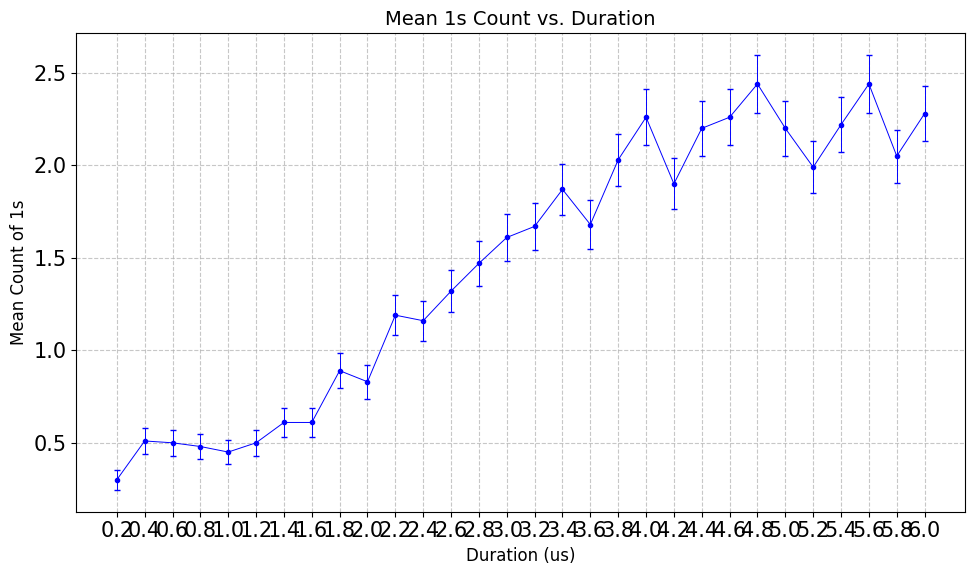

In [35]:
folder_name = 'Full_Sequence_Data/10May25_Pump_Pulse_Duration_sinc'
# Configuration
data_dir = folder_name  # Update this path
file_pattern = re.compile(r'Duration_([\d\.]+)ns_f_(\d+)\.gzip')  # Adjust pattern to match your filenames

# Data storage dictionaries
amp_groups = {}
results = {}
results_std = {}
results_noise = {}

# Group files by amplitude
for filename in os.listdir(data_dir):
    match = file_pattern.match(filename)
    if match:
        amp = float(match.group(1))/1000  # Handle decimal amplitudes if needed
        file_num = int(match.group(2))
        full_path = os.path.join(data_dir, filename)
        
        if amp not in amp_groups:
            amp_groups[amp] = []
        amp_groups[amp].append(full_path)

# Process each amplitude group
for amp, files in amp_groups.items():
    counts = []
    noise_counts = []
    for file in sorted(files, key=lambda x: int(re.search(r'_(\d+)\.', x).group(1))):
        counts.append(read_gzip_counts_photons(file, 465e3, 6e3))
        noise_counts.append(read_gzip_counts_photons(file, 475e3, 6e3))
        # print(file)
    
    results[amp] = np.mean(counts)
    results_std[amp] = np.sqrt(np.mean(counts)/len(files))
    results_noise[amp] = np.mean(noise_counts)

# Sort results by amplitude
sorted_amps = sorted(results.keys())
sorted_means = [results[amp] for amp in sorted_amps]
sorted_stds = [round(results_std[amp], 3) for amp in sorted_amps]
sorted_noise_means = [round(results_noise[amp], 3) for amp in sorted_amps]
print('Sorted Amplitudes:', np.array(sorted_amps))
print('Sorted Means:', np.array(sorted_means))
print('Sorted Stds:', np.array(sorted_stds))
print('Sorted Noise Means:', np.array(sorted_noise_means))

# Create the plot
plt.figure(figsize=(10, 6))
# plt.plot(sorted_amps, sorted_means, 'bo-', linewidth=2, markersize=8)
plt.errorbar(sorted_amps, sorted_means, sorted_stds, fmt='o-',
             alpha = 1, capsize=2, markersize=3, linewidth=0.7, color='blue', label='Windowed Counts')
plt.xlabel("Duration (us)", fontsize=12)
plt.ylabel("Mean Count of 1s", fontsize=12)
plt.title("Mean 1s Count vs. Duration", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(sorted_amps)  # Show all amplitude values on x-axis
plt.tight_layout()

# Save and show plot
# plt.savefig(data_dir +"_count vs Duration.png", dpi=300)
plt.show()

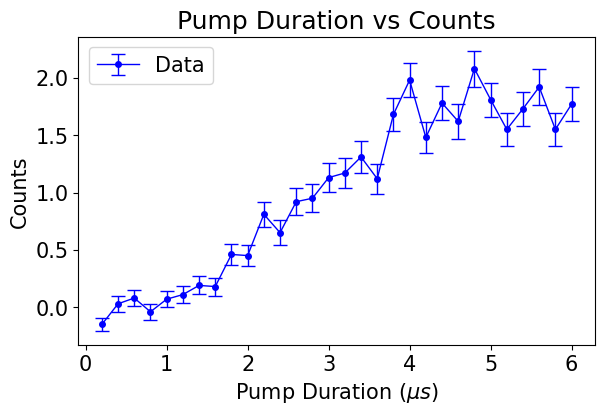

In [5]:
# Data on 10-May-2025 folder = 'Pump_Pulse_Duration_sinc'
pump_duration = np.array([0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 
                          2.2, 2.4, 2.6, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8, 4.0, 
                          4.2, 4.4, 4.6, 4.8, 5.0, 5.2, 5.4, 5.6, 5.8, 6.0])
noise_floor = np.array([0.45, 0.48, 0.42, 0.52, 0.38, 0.39, 0.42, 0.43, 0.43, 
                        0.38, 0.38, 0.51, 0.4, 0.52, 0.48, 0.5, 0.56, 0.56, 
                        0.35, 0.28, 0.42, 0.42, 0.64, 0.36, 0.39, 0.44, 0.49, 0.52, 0.5, 0.51])
pump_duration_counts = np.array([0.3, 0.51, 0.5, 0.48, 0.45, 0.5, 0.61, 0.61, 
                                 0.89, 0.83, 1.19, 1.16, 1.32, 1.47, 1.61, 1.67, 
                                 1.87, 1.68, 2.03, 2.26, 1.9, 2.2, 2.26, 2.44, 
                                 2.2, 1.99, 2.22, 2.44, 2.05, 2.28])
pump_duration_counts = pump_duration_counts - noise_floor
pump_duration_counts_std = np.array([0.055, 0.071, 0.071, 0.069, 0.067, 0.071, 
                                     0.078, 0.078, 0.094, 0.091, 0.109, 0.108, 
                                     0.115, 0.121, 0.127, 0.129, 0.137, 0.13, 
                                     0.142, 0.15, 0.138, 0.148, 0.15, 0.156,
                                       0.148, 0.141, 0.149, 0.156, 0.143, 0.151])

# Pump Pulse Duration
plt.figure(figsize=(20/3, 4))
plt.errorbar(pump_duration, pump_duration_counts, pump_duration_counts_std,
             capsize=5, elinewidth=1, linewidth=1, markersize=4, color='blue', marker='o', label='Data')
# plt.plot(pump_duration, pump_duration_counts, color='blue', marker='o')
# plt.fill_between(pump_duration, np.array(pump_duration_counts)-np.array(pump_duration_counts_std), 
#                             np.array(pump_duration_counts)+np.array(pump_duration_counts_std), 
#                             color='lightblue', alpha=0.5, label='1σ Error')
plt.xlabel(r'Pump Duration ($\mu s$)')
plt.ylabel('Counts')
plt.title('Pump Duration vs Counts')
plt.legend()
# plt.savefig('Plots/Pump_Duration.pdf')
plt.show()

## MW Pulse Duration

### Data Extraction

In [42]:
def read_gzip_counts_for_MW(binary_file, window_start_time_ns, window_duration_ns):
    """
    Reads a .gzip file containing binary APD data, counts photons within a
    specified time window by detecting rising edges. OPTIMIZED FOR ZERO DEAD TIME.

    Args:
        binary_file (str): Path to the .gzip file.
        window_start_time_ns (float): Start time of the analysis window (in nanoseconds).
        window_duration_ns (float): Duration of the analysis window (in nanoseconds).

    Returns:
        int: The total number of photons counted within the window.
             Returns None on file/data error, 0 for invalid window.
    """
    # --- Sampling Parameters ---
    TIME_SPACING_PS = 2000 #400.0  # Picoseconds per point
    TIME_SPACING_NS = TIME_SPACING_PS / 1000.0 # Nanoseconds per point (0.4 ns)
    # DEAD_TIME_NS is assumed to be 0 for this optimized version

    # --- File Reading and Data Unpacking ---
    try:
        with gzip.open(binary_file, 'rb') as f:
            loaded_bit_array = pickle.load(f)
    except FileNotFoundError:
        print(f"Error: File not found at {binary_file}")
        return None
    except Exception as e:
        print(f"Error reading file {binary_file}: {e}")
        return None

    try:
        unpacked_bytes = loaded_bit_array.unpack()
        loaded_binary_array = np.frombuffer(unpacked_bytes, dtype=np.uint8)
    except Exception as e:
        print(f"Error unpacking or converting data from {binary_file}: {e}")
        return None

    # --- Calculate Window Indices ---
    total_samples = len(loaded_binary_array)
    # total_duration_ns = total_samples * TIME_SPACING_NS # Not strictly needed for counting

    start_idx = int(window_start_time_ns / TIME_SPACING_NS)
    stop_idx = start_idx + int(window_duration_ns / TIME_SPACING_NS)

    # --- Validate Indices ---
    if start_idx < 0:
        print(f"Warning: Window start time ({window_start_time_ns} ns) is before data start. Clamping to index 0.")
        start_idx = 0
    # Adjust stop_idx clamping to ensure it's strictly greater than start_idx after clamping
    if stop_idx > total_samples:
        print(f"Warning: Window end time extends beyond data. Clamping to max index {total_samples}.")
        stop_idx = total_samples
    if start_idx >= stop_idx:
         # If start_idx == stop_idx after clamping, the window has zero length.
         # If start_idx > stop_idx (e.g., negative duration), it's invalid.
        # print(f"Info: Start index ({start_idx}) is not before stop index ({stop_idx}). Empty or invalid window.")
        return 0 # No samples in window means no photons

    # --- Extract Window Data ---
    window_data = loaded_binary_array[start_idx:stop_idx]
    n_window_samples = len(window_data)

    if n_window_samples < 2:
        # Need at least two points to detect a transition
        return 0

    # --- Optimized Photon Counting (NumPy Vectorization) ---
    # Find indices where the current point is 0 and the next point is 1
    # Create views of the array shifted by one element
    current_points = window_data[:-1] # All points except the last
    next_points = window_data[1:]   # All points except the first

    # Perform element-wise comparison to find 0 -> 1 transitions
    # `&` performs logical AND on the boolean arrays resulting from comparisons
    rising_edges_mask = (current_points == 0) & (next_points == 1)

    # Sum the boolean mask: True counts as 1, False as 0
    photon_count = np.sum(rising_edges_mask)

    # Note: This vectorized approach correctly handles consecutive 0->1 transitions
    # if the detector physics allowed it (which zero dead time implies).

    return photon_count

Sorted Amplitudes: [0.2 0.4 0.6 0.8 1.  1.2 1.4 1.6 1.8 2.  2.2 2.4 2.6 2.8 3.  3.2 3.4 3.6
 3.8 4.  4.2 4.4 4.6 4.8 5.  5.2 5.4 5.6 5.8 6. ]
Sorted Means: [ 2.8  7.4 12.9 13.  14.9 17.1 19.4 17.4 18.2 18.4 19.9 20.1 20.5 20.6
 17.1 17.9 18.6 15.9 15.2 16.4 15.8 15.  12.7 13.1 12.  11.3  8.9  9.5
  8.2  7.8]
Sorted Stds: [0.53 0.86 1.14 1.14 1.22 1.31 1.39 1.32 1.35 1.36 1.41 1.42 1.43 1.44
 1.31 1.34 1.36 1.26 1.23 1.28 1.26 1.22 1.13 1.14 1.1  1.06 0.94 0.97
 0.91 0.88]


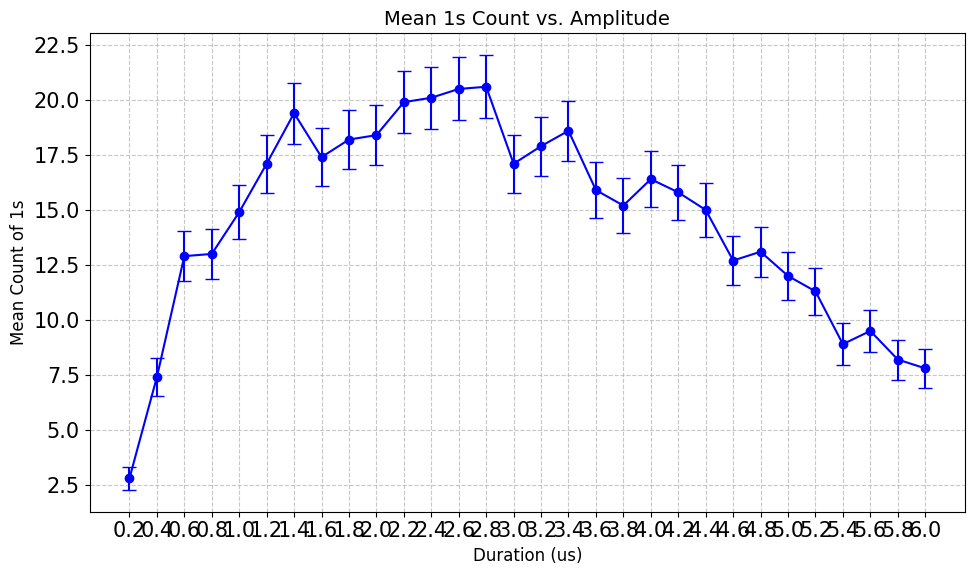

In [46]:
folder_name = 'Full_Sequence_Data/30Mar25_MW_Pulse_Duration_1'
# Configuration
data_dir = folder_name  # Update this path
file_pattern = re.compile(r'Duration_([\d\.]+)ns_f_(\d+)\.gzip')  # Adjust pattern to match your filenames

# Data storage dictionaries
amp_groups = {}
results = {}
results_std = {}

# Group files by amplitude
for filename in os.listdir(data_dir):
    match = file_pattern.match(filename)
    if match:
        amp = float(match.group(1))/1000  # Handle decimal amplitudes if needed
        file_num = int(match.group(2))
        full_path = os.path.join(data_dir, filename)
        
        if amp not in amp_groups:
            amp_groups[amp] = []
        amp_groups[amp].append(full_path)

# Process each amplitude group
for amp, files in amp_groups.items():
    counts = []
    for file in sorted(files, key=lambda x: int(re.search(r'_(\d+)\.', x).group(1))):
        # counts.append(read_gzip_counts_for_MW(file))
        counts.append(read_gzip_counts_for_MW(file, 468e3, 4e3))

        # print(file)
    
    results[amp] = np.mean(counts)
    # results_std[amp] = round(np.std(counts),2)
    results_std[amp]= round(np.sqrt(np.mean(counts)/len(files)),2)


# Sort results by amplitude
sorted_amps = sorted(results.keys())
sorted_means = [results[amp] for amp in sorted_amps]
sorted_stds = [results_std[amp] for amp in sorted_amps]
print('Sorted Amplitudes:', np.array(sorted_amps))
print('Sorted Means:', np.array(sorted_means))
print('Sorted Stds:', np.array(sorted_stds))
# Create the plot
plt.figure(figsize=(10, 6))
# plt.plot(sorted_amps, sorted_means, 'bo-', linewidth=2, markersize=8)
plt.errorbar(sorted_amps, sorted_means, yerr=sorted_stds, fmt='o-', color='blue', capsize=5)
plt.xlabel("Duration (us)", fontsize=12)
plt.ylabel("Mean Count of 1s", fontsize=12)
plt.title("Mean 1s Count vs. Amplitude", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(sorted_amps)  # Show all amplitude values on x-axis
plt.tight_layout()

# Save and show plot
# plt.savefig(data_dir +"_count vs Duration.png", dpi=300)
plt.show()

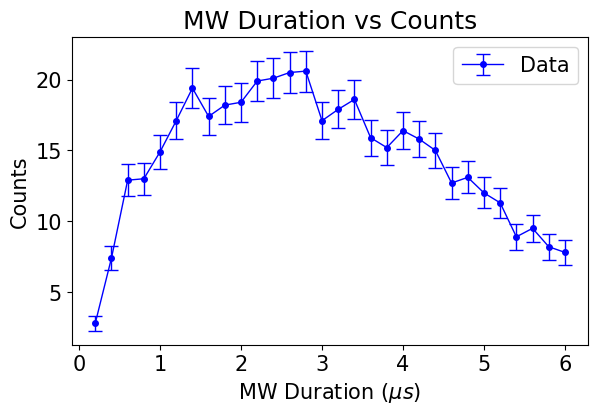

In [7]:
# Data on 30-Mar-2025
mw_duration = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8, 4.0, 4.2, 4.4, 4.6, 4.8, 5.0, 5.2, 5.4, 5.6, 5.8, 6.0]
mw_duration_counts =[2.8, 7.4, 12.9, 13.0, 14.9, 17.1, 19.4, 17.4, 18.2, 18.4, 19.9, 20.1, 20.5, 20.6, 17.1, 17.9, 18.6, 15.9, 15.2, 16.4, 15.8, 15.0, 12.7, 13.1, 12.0, 11.3, 8.9, 9.5, 8.2, 7.8]
mw_duration_counts_std = [0.53, 0.86, 1.14, 1.14, 1.22, 1.31, 1.39, 1.32, 1.35, 1.36, 1.41, 1.42, 1.43, 1.44, 1.31, 1.34, 1.36, 1.26, 1.23, 1.28, 1.26, 1.22, 1.13, 1.14, 1.1, 1.06, 0.94, 0.97, 0.91, 0.88]

# MW Pulse Duration
plt.figure(figsize=(20/3, 4))
plt.errorbar(mw_duration, mw_duration_counts, mw_duration_counts_std,
             capsize=5, elinewidth=1, linewidth=1, markersize=4, color='blue', marker='o', label='Data')
# plt.plot(mw_duration, mw_duration_counts, color='blue', marker='o')
# plt.fill_between(mw_duration, np.array(mw_duration_counts)-np.array(mw_duration_counts_std), 
#                             np.array(mw_duration_counts)+np.array(mw_duration_counts_std), 
#                             color='lightblue', alpha=0.5, label='1σ Error')
plt.xlabel(r'MW Duration ($\mu s$)')
plt.ylabel('Counts')
plt.title('MW Duration vs Counts')
plt.legend()
# plt.savefig('Plots/MW_Duration.pdf')
plt.show()

## Coherence Time

In [47]:
# Step 2: Read the binary file, apply calibration, and plot the data
def read_and_plot_waveform(folder, binary_file):
    binary_file = binary_file #+ '.bin'
    # Load the binary data
    with open(binary_file, "rb") as f:
        raw_data = f.read()

    # Parse the header
    header_length = int(raw_data[6:7])  # Length of the length field ('9')
    payload_length = int(raw_data[7:7 + header_length])  # Length of binary data
    binary_data_start = 7 + header_length

    # Extract binary data
    binary_data = raw_data[binary_data_start : binary_data_start + payload_length]

    # Decode binary data to voltage values (assuming 16-bit integers)
    raw_voltage_values = np.frombuffer(binary_data, dtype=np.int8)

    # Load calibration settings
    calibration_settings = {}
    with open(folder+'/Cal_file' + ".settings", "r") as f:
        for line in f:
            key, value = line.strip().split("=")
            calibration_settings[key] = float(value)

    # Calibration factors
    x_div = calibration_settings["x_div"]
    y_div = calibration_settings["y_div"]
    voltage_offset = calibration_settings["voltage_offset"]

    # Scale the raw data - 2.5/3 factor is empirical based on observation
    voltage_values = raw_voltage_values * y_div*8 / (2**8) *3/2.5 - voltage_offset*2.5/3 

    # Generate the time axis
    num_samples = len(voltage_values)
    time_scale = x_div * 10  # 10 divisions on the screen
    sample_interval = time_scale / num_samples
    time_values = np.arange(num_samples) * sample_interval

    return [time_values, voltage_values]


In [48]:
data_folder = 'Full_Sequence_Data/17June25_Pi_half_duration_1400ns' 
# Get list of files in the current directory
files = [f for f in os.listdir(data_folder) if f.startswith('Delay_') and f.endswith('.bin')]
# Create a dictionary to store areas for each delay
delay_areas = {}

# Iterate over each file
for file_name in files:
    # Extract delay and file number from the filename
    parts = file_name.split('_')
    delay = int(parts[1][:-2])  # Extract delay (e.g., 60 from '60us')
    file_number = int(parts[3][:-4]) # Extract file number (e.g. 0 from f_0.csv)

    # Load the data
    file_path = os.path.join(data_folder, file_name)
    data = read_and_plot_waveform(data_folder, file_path)
    # Select data within index range 0.25 of length to the end
    start_idx = int(0.25 * len(data[0]))
    df = pd.DataFrame({'Time': data[0][start_idx:], 'Voltage': data[1][start_idx:]})
   
    if df.shape[1] >= 2:
        x = df.iloc[:, 0]
        y = df.iloc[:, 1]
        area = np.trapezoid(y, x)
        # Store the area for the corresponding delay
        if delay not in delay_areas:
            delay_areas[delay] = []
        delay_areas[delay].append(area)
    else:
        print(f"Skipping file {file_name} as it does not have at least two columns.")

# Calculate max area for each delay
max_areas = {delay: max(areas) for delay, areas in delay_areas.items()}

# Prepare data for plotting
delays = sorted(max_areas.keys())
areas = [max_areas[delay] for delay in delays]

# Convert to numpy arrays for curve fitting
delays = 2*np.array(delays)
areas = np.array(areas)*1e5

print("Delays (us):", delays)
print("Max Areas:", areas)

Delays (us): [ 120  160  200  240  280  320  360  400  440  480  520  560  600  640
  680  720  760  800  840  880  920  960 1000]
Max Areas: [3.83254559 3.81791396 3.60553366 3.2621924  3.23666111 3.07951711
 2.93399653 2.79337415 2.59873421 2.57331241 2.40955572 2.31913195
 2.25204648 2.28303474 2.16055022 2.1495118  2.08983403 2.0559928
 1.94822391 1.93351653 1.94078772 1.91364169 1.88870139]


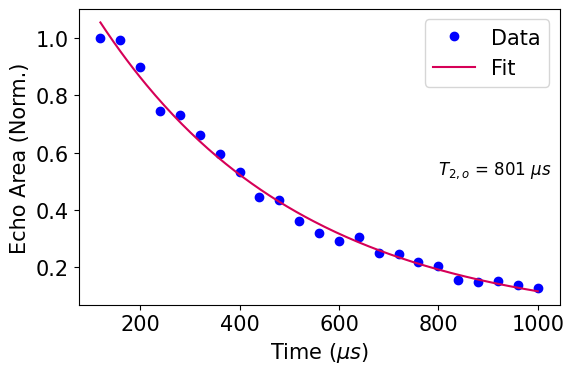

Original fit parameters: a=3.176, b=0.002498, c=1.601
Rescaled data range: 0.288 to 2.232


In [ ]:
# Data on 17-June-2025 folder = '2PE_4g_1e_T2_2/Pi_half_duration_1400ns' ----- Verify this folder
time_arr = np.array([120, 160, 200, 240, 280, 320, 360, 400, 440, 480, 520, 560, 600, 640,
                     680, 720, 760, 800, 840, 880, 920, 960, 1000])
max_areas = np.array([3.83254559, 3.81791396, 3.60553366, 3.2621924,  3.23666111, 3.07951711,
                      2.93399653, 2.79337415, 2.59873421, 2.57331241, 2.40955572, 2.31913195,
                      2.25204648, 2.28303474, 2.16055022, 2.1495118,  2.08983403, 2.0559928,
                      1.94822391, 1.93351653, 1.94078772, 1.91364169, 1.88870139])

# Define the exponential decay function
def exp_decay(x, a, b, c):
    return a * np.exp(-b * x) + c

# Fit the data
popt, pcov = curve_fit(exp_decay, time_arr, max_areas, p0=[1, 0.001, 0])

# Generate fit curve
x_fit = np.linspace(time_arr.min(), time_arr.max(), 200)
y_fit = exp_decay(x_fit, *popt)

# Rescale max_areas by subtracting the offset
max_areas_rescaled = max_areas - popt[2]

# Define the exponential decay function without offset for plotting
def exp_decay_no_offset(x, a, b):
    return a * np.exp(-b * x)

# Generate fit curve without offset
y_fit_no_offset = exp_decay_no_offset(x_fit, popt[0], popt[1])

# Plot the rescaled data and fit
# plt.figure(figsize=(6, 4))
# plt.plot(time_arr, max_areas_rescaled, 'o', label='Rescaled Data', color='blue')
# plt.plot(x_fit, y_fit_no_offset, '-', label='Fit (no offset)', color='#d60057')
# Scale the rescaled data so the maximum value becomes 1
max_areas_normalized = max_areas_rescaled / max_areas_rescaled.max()

# Plot the normalized data and corresponding fit
plt.figure(figsize=(6, 4))
plt.plot(time_arr, max_areas_normalized, 'o', label='Data', color='blue')

# Rescale the fit to match the normalized data
y_fit_normalized = y_fit_no_offset / max_areas_rescaled.max()
plt.plot(x_fit, y_fit_normalized, '-', label='Fit', color='#d60057')
plt.text(0.8 * time_arr.max(), 0.5 * y_fit_normalized.max(),
         r'$T_{2,o}$' +f' = {2/popt[1]:.0f}'+r'$\ \mu s$', color='black', fontsize=12)
plt.xlabel(r'Time $(\mu s)$')
plt.ylabel('Echo Area (Norm.)')
plt.legend()
plt.tight_layout()
# plt.savefig('Plots/Optical_Coherence_Time_Fit_Rescaled.pdf')
plt.show()

print(f'Original fit parameters: a={popt[0]:.3f}, b={popt[1]:.6f}, c={popt[2]:.3f}')
print(f'Rescaled data range: {max_areas_rescaled.min():.3f} to {max_areas_rescaled.max():.3f}')

## Storage Time

### Asymmeteric Time 

In [51]:
data_dir = 'Full_Sequence_Data/10May25_Asym_Storage_Time_t1_50us_2' 
file_pattern = re.compile(r'StorageTime_([\d\.]+)us_f_(\d+)\.gzip')  # Adjust pattern to match your filenames

# Data storage dictionaries
amp_groups = {}
results = {}
results_std = {}
noise_results = {}
# Group files by amplitude
for filename in os.listdir(data_dir):
    match = file_pattern.match(filename)
    if match:
        amp = float(match.group(1))  # Handle decimal amplitudes if needed
        file_num = int(match.group(2))
        full_path = os.path.join(data_dir, filename)
        
        if amp not in amp_groups:
            amp_groups[amp] = []
        amp_groups[amp].append(full_path)

# Process each amplitude group
for amp, files in amp_groups.items():
    counts = []
    noise_counts = []
    for file in sorted(files, key=lambda x: int(re.search(r'_(\d+)\.', x).group(1))):
        counts.append(read_gzip_counts_photons(file, 457e3, 4e3))
        noise_counts.append(read_gzip_counts_photons(file, 467e3, 4e3))
        # print(counts[-1])
    # break
    results[amp] = np.mean(counts)
    results_std[amp]= round(np.sqrt(np.mean(counts)/len(files)), 3)
    noise_results[amp] = np.mean(noise_counts)

# Sort results by amplitude
sorted_amps = sorted(results.keys())
sorted_means = [results[amp] for amp in sorted_amps]
sorted_stds = [results_std[amp] for amp in sorted_amps]

print("Sorted Amplitudes:", np.array(sorted_amps))
print("Sorted Means:", np.array(sorted_means))
print("Sorted Stds:", np.array(sorted_stds))
print("Sorted Noise Means:", np.array([noise_results[amp] for amp in sorted_amps]))

Sorted Amplitudes: [ 380.  420.  460.  500.  540.  580.  620.  660.  700.  740.  780.  820.
  860.  900.  940.  980. 1020. 1060. 1100. 1140. 1180. 1220. 1260. 1300.
 1340. 1380. 1420. 1460. 1500.]
Sorted Means: [3.78 2.85 2.29 2.18 1.9  1.62 1.46 1.35 1.3  0.75 0.71 0.81 0.56 0.59
 0.58 0.45 0.3  0.36 0.3  0.22 0.26 0.25 0.22 0.21 0.3  0.18 0.3  0.16
 0.19]
Sorted Stds: [0.194 0.169 0.151 0.148 0.138 0.127 0.121 0.116 0.114 0.087 0.084 0.09
 0.075 0.077 0.076 0.067 0.055 0.06  0.055 0.047 0.051 0.05  0.047 0.046
 0.055 0.042 0.055 0.04  0.044]
Sorted Noise Means: [0.36 0.38 0.33 0.25 0.31 0.25 0.24 0.23 0.26 0.23 0.21 0.26 0.24 0.2
 0.21 0.12 0.19 0.22 0.15 0.14 0.13 0.11 0.12 0.16 0.2  0.11 0.15 0.18
 0.18]


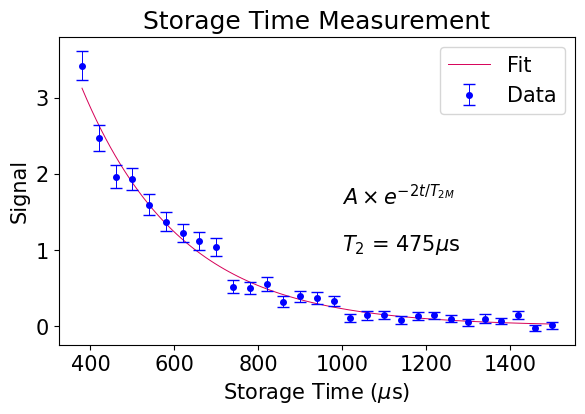

In [10]:
# Data on 10-May-2025
times = np.array([380.0, 420.0, 460.0, 500.0, 540.0, 580.0, 620.0, 660.0, 700.0, 740.0, 780.0, 820.0, 860.0, 900.0, 940.0, 980.0, 1020.0, 1060.0, 1100.0, 1140.0, 1180.0, 1220.0, 1260.0, 1300.0, 1340.0, 1380.0, 1420.0, 1460.0, 1500.0])
noise_floor = np.array([0.36, 0.38, 0.33, 0.25, 0.31, 0.25, 0.24, 0.23, 0.26, 0.23, 0.21, 0.26, 0.24, 0.2, 0.21, 0.12, 0.19, 0.22, 0.15, 0.14, 0.13, 0.11, 0.12, 0.16, 0.2, 0.11, 0.15, 0.18, 0.18])
mean_counts = np.array([3.78, 2.85, 2.29, 2.18, 1.9, 1.62, 1.46, 1.35, 1.3, 0.75, 0.71, 0.81, 0.56, 0.59, 0.58, 0.45, 0.3, 0.36, 0.3, 0.22, 0.26, 0.25, 0.22, 0.21, 0.3, 0.18, 0.3, 0.16, 0.19])
mean_counts_std = np.array([0.194, 0.169, 0.151, 0.148, 0.138, 0.127, 0.121, 0.116, 0.114, 0.087, 0.084, 0.09, 0.075, 0.077, 0.076, 0.067, 0.055, 0.06, 0.055, 0.047, 0.051, 0.05, 0.047, 0.046, 0.055, 0.042, 0.055, 0.04, 0.044])

# Subtract noise floor from mean counts
signal = mean_counts - noise_floor

def exp_decay(t, A, tau):
    return A * np.exp(-2*t/tau)

# Fit the exponential decay
t_fit = np.linspace(min(times), max(times), 100)
popt, pcov = curve_fit(exp_decay, times, signal, p0=[3.0, 500], sigma=mean_counts_std)

# Create the plot
plt.figure(figsize=(20/3, 4))
plt.plot(t_fit, exp_decay(t_fit, *popt), color = '#d60057', linewidth=0.7, label='Fit')
plt.errorbar(times, signal, yerr=mean_counts_std, fmt='bo', markersize=4, 
            capsize=4, elinewidth=0.7, label='Data')

plt.xlabel(r'Storage Time ($\mu$s)')
plt.ylabel('Signal')
plt.title('Storage Time Measurement')
plt.text(1000, 1.6, r'$A\times e^{-2t/T_{2M}}$')
plt.text(1000, 1, f'$T_2$ = {popt[1]:.0f}'+r'$\mu$s')
plt.legend()
# plt.savefig('Plots/Storage_time_asym.pdf')
plt.show()


## Pump-MW Delay

In [55]:
data_dir = 'Full_Sequence_Data/10May25_Pump_MW_Separation_sinc' 
file_pattern = re.compile(r'Separation_([\d\.]+)ns_f_(\d+)\.gzip')  # Adjust pattern to match your filenames

# Data storage dictionaries
amp_groups = {}
results = {}
results_std = {}
noise_results = {}

# Group files by amplitude
for filename in os.listdir(data_dir):
    match = file_pattern.match(filename)
    if match:
        # temp = float(match.group(1))  # Handle decimal amplitudes if needed
        # amp = MW_photon_dict[int(temp)]*1e-16
        # amp = round(amp, 0)
        amp = float(match.group(1))/1000
        file_num = int(match.group(2))
        full_path = os.path.join(data_dir, filename)
        
        if amp not in amp_groups:
            amp_groups[amp] = []
        amp_groups[amp].append(full_path)

# Process each amplitude group
for amp, files in amp_groups.items():
    counts = []
    noise_counts = []
    for file in sorted(files, key=lambda x: int(re.search(r'_(\d+)\.', x).group(1))):
        counts.append(read_gzip_counts_photons(file, 467e3, 4e3))
        noise_counts.append(read_gzip_counts_photons(file, 477e3, 4e3))
        # print(file)
    
    results[amp] = np.mean(counts)
    results_std[amp] = np.sqrt(np.mean(counts)/len(files))
    noise_results[amp] = np.mean(noise_counts)

# Sort results by amplitude
sorted_amps = sorted(results.keys())
sorted_means = [results[amp] for amp in sorted_amps]
sorted_stds = [round(results_std[amp], 3) for amp in sorted_amps]
print("Sorted Amplitudes:", sorted_amps)
print("Sorted Means:", sorted_means)
print("Sorted Stds:", sorted_stds)
print("Sorted Noise Means:", [round(noise_results[amp], 3) for amp in sorted_amps])  

Sorted Amplitudes: [0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8, 4.0, 4.2, 4.4, 4.6, 4.8, 5.0, 5.2, 5.4, 5.6, 5.8, 6.0]
Sorted Means: [np.float64(2.17), np.float64(2.27), np.float64(1.72), np.float64(1.71), np.float64(1.69), np.float64(1.39), np.float64(1.42), np.float64(1.03), np.float64(1.04), np.float64(0.91), np.float64(0.84), np.float64(0.84), np.float64(0.79), np.float64(0.77), np.float64(0.68), np.float64(0.76), np.float64(0.64), np.float64(0.48), np.float64(0.48), np.float64(0.56), np.float64(0.39), np.float64(0.42), np.float64(0.36), np.float64(0.52), np.float64(0.39), np.float64(0.34), np.float64(0.4), np.float64(0.4), np.float64(0.31), np.float64(0.41), np.float64(0.42)]
Sorted Stds: [np.float64(0.147), np.float64(0.151), np.float64(0.131), np.float64(0.131), np.float64(0.13), np.float64(0.118), np.float64(0.119), np.float64(0.101), np.float64(0.102), np.float64(0.095), np.float64(0.092), np.float64(0.092), np.float64(0.

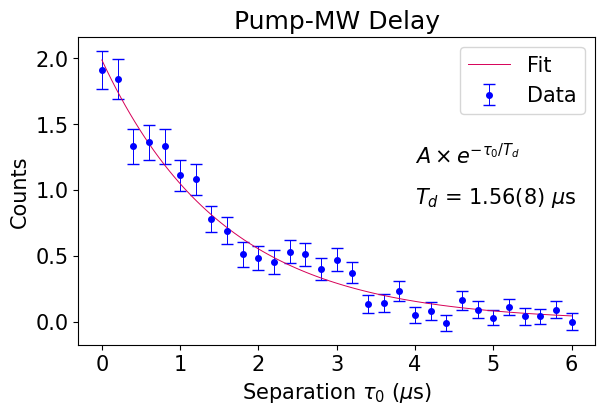

A = 1.99 ± 0.09
tau = 1.56 ± 0.08


In [11]:
# Data on 10-May-2025 folder = 'Pump_MW_Separation_sinc'
separation = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8, 4.0, 4.2, 4.4, 4.6, 4.8, 5.0, 5.2, 5.4, 5.6, 5.8, 6.0])
noise_floor = np.array([0.26, 0.43, 0.39, 0.35, 0.36, 0.28, 0.34, 0.25, 0.35, 0.4, 0.36, 0.39, 0.26, 0.26, 0.28, 0.29, 0.27, 0.35, 0.34, 0.33, 0.34, 0.34, 0.37, 0.36, 0.3, 0.31, 0.29, 0.36, 0.27, 0.32, 0.42])
mean_counts = np.array([2.17, 2.27, 1.72, 1.71, 1.69, 1.39, 1.42, 1.03, 1.04, 0.91, 0.84, 0.84, 0.79, 0.77, 0.68, 0.76, 0.64, 0.48, 0.48, 0.56, 0.39, 0.42, 0.36, 0.52, 0.39, 0.34, 0.4, 0.4, 0.31, 0.41, 0.42])
mean_counts_std = np.array([0.147, 0.151, 0.131, 0.131, 0.13, 0.118, 0.119, 0.101, 0.102, 0.095, 0.092, 0.092, 0.089, 0.088, 0.082, 0.087, 0.08, 0.069, 0.069, 0.075, 0.062, 0.065, 0.06, 0.072, 0.062, 0.058, 0.063, 0.063, 0.056, 0.064, 0.065])

signal = mean_counts - noise_floor
def exp_decay(t, A, b):
    return A * np.exp(-t/b)

# Fit the exponential decay
t_fit = np.linspace(min(separation), max(separation), 100)
popt, pcov = curve_fit(exp_decay, separation, signal, p0=[3.0, 1.5], sigma=mean_counts_std)

# Create the plot
plt.figure(figsize=(20/3, 4))
plt.errorbar(separation, signal, yerr=mean_counts_std, fmt='o', 
            markersize=4, capsize=4, elinewidth=0.7, color='blue', label='Data')
plt.plot(t_fit, exp_decay(t_fit, *popt), '-', color='#d60057', 
         linewidth=0.7, label='Fit')

plt.xlabel(r'Separation $\tau_0$ ($\mu$s)')
plt.ylabel('Counts')
plt.title('Pump-MW Delay')
plt.text(4, 1.2, r'$A\times e^{-\tau_0/T_d}$')
plt.text(4, 0.9, f'$T_d$ = {popt[1]:.2f}'+f'({1e2*np.sqrt(pcov[1,1]):.0f})'+ r' $\mu$s')
plt.legend()
# plt.savefig('Plots/Pump_MW_Delay.pdf')
plt.show()

print(f'A = {popt[0]:.2f} ± {np.sqrt(pcov[0,0]):.2f}')
print(f'tau = {popt[1]:.2f} ± {np.sqrt(pcov[1,1]):.2f}')

## Spin Transition

In [57]:
def read_gzip_counts_photons_01Apr(binary_file, window_start_time_ns, window_duration_ns):
    """
    Reads a .gzip file containing binary APD data, counts photons within a
    specified time window by detecting rising edges. OPTIMIZED FOR ZERO DEAD TIME.

    Args:
        binary_file (str): Path to the .gzip file.
        window_start_time_ns (float): Start time of the analysis window (in nanoseconds).
        window_duration_ns (float): Duration of the analysis window (in nanoseconds).

    Returns:
        int: The total number of photons counted within the window.
             Returns None on file/data error, 0 for invalid window.
    """
    # --- Sampling Parameters ---
    TIME_SPACING_PS = 2000 #400.0  # Picoseconds per point
    TIME_SPACING_NS = TIME_SPACING_PS / 1000.0 # Nanoseconds per point (0.4 ns)
    # DEAD_TIME_NS is assumed to be 0 for this optimized version

    # --- File Reading and Data Unpacking ---
    try:
        with gzip.open(binary_file, 'rb') as f:
            loaded_bit_array = pickle.load(f)
    except FileNotFoundError:
        print(f"Error: File not found at {binary_file}")
        return None
    except Exception as e:
        print(f"Error reading file {binary_file}: {e}")
        return None

    try:
        unpacked_bytes = loaded_bit_array.unpack()
        loaded_binary_array = np.frombuffer(unpacked_bytes, dtype=np.uint8)
    except Exception as e:
        print(f"Error unpacking or converting data from {binary_file}: {e}")
        return None

    # --- Calculate Window Indices ---
    total_samples = len(loaded_binary_array)
    # total_duration_ns = total_samples * TIME_SPACING_NS # Not strictly needed for counting

    start_idx = int(window_start_time_ns / TIME_SPACING_NS)
    stop_idx = start_idx + int(window_duration_ns / TIME_SPACING_NS)

    # --- Validate Indices ---
    if start_idx < 0:
        print(f"Warning: Window start time ({window_start_time_ns} ns) is before data start. Clamping to index 0.")
        start_idx = 0
    # Adjust stop_idx clamping to ensure it's strictly greater than start_idx after clamping
    if stop_idx > total_samples:
        print(f"Warning: Window end time extends beyond data. Clamping to max index {total_samples}.")
        stop_idx = total_samples
    if start_idx >= stop_idx:
         # If start_idx == stop_idx after clamping, the window has zero length.
         # If start_idx > stop_idx (e.g., negative duration), it's invalid.
        # print(f"Info: Start index ({start_idx}) is not before stop index ({stop_idx}). Empty or invalid window.")
        return 0 # No samples in window means no photons

    # --- Extract Window Data ---
    window_data = loaded_binary_array[start_idx:stop_idx]
    n_window_samples = len(window_data)

    if n_window_samples < 2:
        # Need at least two points to detect a transition
        return 0

    # --- Optimized Photon Counting (NumPy Vectorization) ---
    # Find indices where the current point is 0 and the next point is 1
    # Create views of the array shifted by one element
    current_points = window_data[:-1] # All points except the last
    next_points = window_data[1:]   # All points except the first

    # Perform element-wise comparison to find 0 -> 1 transitions
    # `&` performs logical AND on the boolean arrays resulting from comparisons
    rising_edges_mask = (current_points == 0) & (next_points == 1)

    # Sum the boolean mask: True counts as 1, False as 0
    photon_count = np.sum(rising_edges_mask)

    # Note: This vectorized approach correctly handles consecutive 0->1 transitions
    # if the detector physics allowed it (which zero dead time implies).

    return photon_count

In [ ]:
data_dir = 'Full_Sequence_Data/01Apr25_MW_frequency_2' 
file_pattern = re.compile(r'Frequency_([\d\.]+)kHz_f_(\d+)\.gzip')  # Adjust pattern to match your filenames

# Data storage dictionaries
amp_groups = {}
results = {}
results_std = {}

# Group files by amplitude
for filename in os.listdir(data_dir):
    match = file_pattern.match(filename)
    if match:
        amp = float(match.group(1))/1000  # Handle decimal amplitudes if needed
        file_num = int(match.group(2))
        full_path = os.path.join(data_dir, filename)
        
        if amp not in amp_groups:
            amp_groups[amp] = []
        amp_groups[amp].append(full_path)

# Process each amplitude group
for amp, files in amp_groups.items():
    counts = []
    for file in sorted(files, key=lambda x: int(re.search(r'_(\d+)\.', x).group(1))):
        counts.append(read_gzip_counts_photons_01Apr(file, 467e3, 4e3))
        # print(file)
    
    results[amp] = np.mean(counts)
    results_std[amp] = round(np.sqrt(np.mean(counts)/len(files)),3)

# Sort results by amplitude
sorted_amps = sorted(results.keys())
sorted_means = [results[amp] for amp in sorted_amps]
sorted_stds = [results_std[amp] for amp in sorted_amps]
print("Sorted Amplitudes:", np.array(sorted_amps))
print("Sorted Means:", np.array(sorted_means))
print("Sorted Stds:", np.array(sorted_stds))

Sorted Amplitudes: [2622.8  2622.85 2622.9  2622.95 2623.   2623.05 2623.1  2623.15 2623.2
 2623.25 2623.3  2623.35 2623.4  2623.45 2623.5  2623.55 2623.6  2623.65
 2623.7  2623.75 2623.8  2623.85 2623.9  2623.95 2624.  ]
Sorted Means: [ 0.3   0.5   0.4   1.65  2.65  4.15  5.95  8.7  11.   12.2  12.7  15.1
 13.55 12.25 11.6   8.4   6.55  4.8   3.1   1.85  0.55  0.4   0.8   0.7
  0.95]
Sorted Stds: [0.122 0.158 0.141 0.287 0.364 0.456 0.545 0.66  0.742 0.781 0.797 0.869
 0.823 0.783 0.762 0.648 0.572 0.49  0.394 0.304 0.166 0.141 0.2   0.187
 0.218]


Amplitude: 20.788 ± 0.736
Center: 2623.355 ± 0.003 MHz
FWHM: 0.642 ± 0.043 MHz
Offset: -6.520 ± 0.871


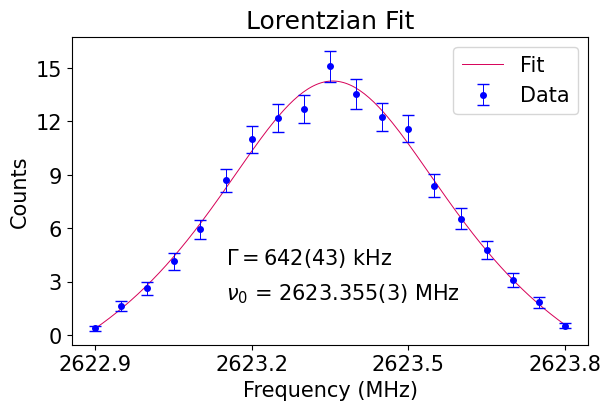

In [12]:
# Data on 01-Apr-2025
x= [2622.9, 2622.95, 2623.0, 2623.05, 2623.1, 2623.15, 2623.2, 2623.25, 2623.3, 2623.35, 2623.4, 2623.45, 2623.5, 2623.55, 2623.6, 2623.65, 2623.7, 2623.75, 2623.8]
y= [ 0.4, 1.65, 2.65, 4.15, 5.95, 8.7, 11.0, 12.2, 12.7, 15.1, 13.55, 12.25, 11.6, 8.4, 6.55, 4.8, 3.1, 1.85, 0.55]
y_std =[0.141, 0.287, 0.364, 0.456, 0.545, 0.66, 0.742, 0.781, 0.797, 0.869, 0.823, 0.783, 0.762, 0.648, 0.572, 0.49, 0.394, 0.304, 0.166]

# Define the Lorentzian function
def lorentzian(x, amplitude, center, width, offset):
    return amplitude * (width/2)**2 / ((x - center)**2 + (width/2)**2) + offset

# Initial parameter guesses
amplitude_guess = max(y) - min(y)  # Peak height above baseline
center_guess = x[np.argmax(y)]     # x-value at peak
width_guess = 0.3                  # Initial guess for width
offset_guess = min(y)              # Baseline offset

p0 = [amplitude_guess, center_guess, width_guess, offset_guess]

# Perform the fit
popt, pcov = curve_fit(lorentzian, x, y, p0=p0, sigma=y_std, absolute_sigma=True)
perr = np.sqrt(np.diag(pcov))

# Generate points for smooth curve
x_fit = np.linspace(min(x), max(x), 200)
y_fit = lorentzian(x_fit, *popt)

# Create the plot
plt.figure(figsize=(20/3, 4))
plt.plot(x_fit, y_fit, '-', color='#d60057', label='Fit', linewidth=0.7)
plt.errorbar(x, y, yerr=y_std, fmt='o', color='blue', markersize=4, 
            capsize=4, elinewidth=0.7, label='Data')
# plt.plot(x, y, 'o', color='blue', label='Data', markersize=4)
# plt.fill_between(x, np.array(y)-np.array(y_std), 
#                 np.array(y)+np.array(y_std), 
#                 color='lightblue', alpha=0.5, label='1σ Error')

plt.xlabel('Frequency (MHz)')
plt.ylabel('Counts')
plt.xticks(np.arange(2622.9, 2623.92, 0.3), rotation=0)
plt.yticks(np.arange(0, 18, 3))
plt.title('Lorentzian Fit')
plt.legend()
plt.text(2623.15, 4, r'$\Gamma = $'+f'{1e3*popt[2]:.0f}({1e3*perr[2]:.0f}) kHz', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
plt.text(2623.15, 2, r'$\nu_0$' +f' = {popt[1]:.3f}({1e3*perr[1]:.0f}) MHz')
# plt.savefig('Plots/Spin_transition_fit.pdf')

# Print fit parameters
print(f'Amplitude: {popt[0]:.3f} ± {perr[0]:.3f}')
print(f'Center: {popt[1]:.3f} ± {perr[1]:.3f} MHz')
print(f'FWHM: {popt[2]:.3f} ± {perr[2]:.3f} MHz')
print(f'Offset: {popt[3]:.3f} ± {perr[3]:.3f}')

## Phase Interference

In [61]:
data_dir = 'Full_Sequence_Data/10May25_Op_MW_MW_same_freq_diff_phase_sinc' 
file_pattern = re.compile(r'Phase_([\d\.]+)mRad_f_(\d+)\.gzip')  # Adjust pattern to match your filenames

# Data storage dictionaries
amp_groups = {}
results = {}
results_std = {}
noise_results = {}

# Group files by amplitude
for filename in os.listdir(data_dir):
    match = file_pattern.match(filename)
    if match:
        amp = float(match.group(1))/1000
        file_num = int(match.group(2))
        full_path = os.path.join(data_dir, filename)
        
        if amp not in amp_groups:
            amp_groups[amp] = []
        amp_groups[amp].append(full_path)

# Process each amplitude group
for amp, files in amp_groups.items():
    counts = []
    noise_counts = []
    for file in sorted(files, key=lambda x: int(re.search(r'_(\d+)\.', x).group(1))):
        counts.append(read_gzip_counts_photons(file, 467e3, 4e3))
        noise_counts.append(read_gzip_counts_photons(file, 477e3, 4e3))  # Replace with actual noise counting function if available
        # print(file)
    
    results[amp] = np.mean(counts)
    results_std[amp] = np.sqrt(np.mean(counts)/len(files))
    noise_results[amp] = np.mean(noise_counts)

# Sort results by amplitude
sorted_amps = sorted(results.keys())
sorted_means = [results[amp] for amp in sorted_amps]
sorted_stds = [round(results_std[amp], 3) for amp in sorted_amps]
print("Sorted Amplitudes:", np.array(sorted_amps))
print("Sorted Means:", np.array(sorted_means))
print("Sorted Stds:", np.array(sorted_stds))
print("Sorted Noise Means:", np.array([noise_results[amp] for amp in sorted_amps]))

Sorted Amplitudes: [0.    0.628 1.256 1.884 2.513 3.141 3.769 4.398 5.026 5.654 6.283]
Sorted Means: [4.16 4.11 3.74 2.44 1.31 0.81 1.16 1.87 2.96 4.05 4.42]
Sorted Stds: [0.204 0.203 0.193 0.156 0.114 0.09  0.108 0.137 0.172 0.201 0.21 ]
Sorted Noise Means: [0.36 0.42 0.37 0.35 0.23 0.36 0.22 0.22 0.38 0.37 0.46]


Fit parameters: I1=1.93, I2=0.39, phi=-0.13
R^2 value: 0.9853
Phase offset (phi): -0.13 rad = -7.3°


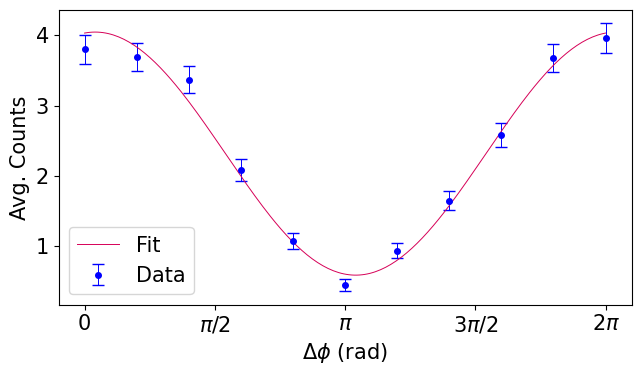

In [ ]:
''' Based on Intensity fit rather than electric field fit. '''
# Data on 10-May-2025 folder_name = 'Op_MW_MW_same_freq_diff_phase_sinc'
phase_rad = np.array([0.0, 0.628, 1.256, 1.884, 2.513, 3.141, 3.769, 4.398, 5.026, 5.654, 6.283])
noise_floor = np.array([0.36, 0.42, 0.37, 0.35, 0.23, 0.36, 0.22, 0.22, 0.38, 0.37, 0.46])
counts_mean = np.array([4.16, 4.11, 3.74, 2.44, 1.31, 0.81, 1.16, 1.87, 2.96, 4.05, 4.42])
counts_std =  np.array([0.204, 0.203, 0.193, 0.156, 0.114, 0.09, 0.108, 0.137, 0.172, 0.201, 0.21])
# Subtract noise floor from mean counts
signal = counts_mean - noise_floor
def func(x, I1, I2, phi):
    return  (I1 +I2 + 2*np.sqrt(I1*I2) * np.cos(x + phi))
# Define bounds for the fit parameters: (I1, I2, k, phi)
bounds = ([1, 0, -2*np.pi], [3, 2, 2*np.pi])

popt_signal, pcov_signal = curve_fit(
    func, phase_rad, signal, sigma=counts_std, absolute_sigma=True,
    p0=[np.mean(signal), 0.5, 0],
    bounds=bounds
)

params_text_signal = (
    f"I1={popt_signal[0]:.2f}, I2={popt_signal[1]:.2f}, phi={popt_signal[2]:.2f}"
)
print("Fit parameters:", params_text_signal)

# Calculate R^2 value for the fit
residuals = signal - func(phase_rad, *popt_signal)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((signal - np.mean(signal))**2)
r2 = 1 - (ss_res / ss_tot)
print(f"R^2 value: {r2:.4f}")
# Plot results
plt.figure(figsize=(20/3, 4))
plt.errorbar(phase_rad, signal, yerr=counts_std, fmt='o', 
             color='blue', markersize=4, capsize=4, elinewidth=0.7, label='Data')
phase_smooth = np.linspace(0, 2*np.pi, 200)
plt.plot(phase_smooth, func(phase_smooth, *popt_signal), '-', color='#d60057', 
         linewidth=0.7, label='Fit')
# Print phase offset in degrees
phi_deg = np.degrees(popt_signal[2])
print(f"Phase offset (phi): {popt_signal[2]:.2f} rad = {phi_deg:.1f}°")
plt.xlabel(r'$\Delta \phi$ (rad)')
plt.ylabel('Avg. Counts')
# plt.title('Phase Interference (Intensity Fit)')
plt.legend()
plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi], 
           ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])
# plt.text(1.8, 3.5, f'$a(1 + b \\cos(\\phi + d))$\n{params_text_signal}\n$R^2={r2:.3f}$')
# plt.savefig('Plots/Phase_interference.pdf')

plt.tight_layout()
plt.show()

In [9]:
def intensities_from_a_V(I1, I2):
    """
    Given total intensity a = I1 + I2 and visibility V,
    return I1 and I2 (I1 >= I2).
    """
    V = 2*np.sqrt(I1*I2)/(I1+I2)
    return abs(V*100)

# Example usage:
I1 = 1.83  # 1.93
I2 = 0.46  #0.39
I2 = I2*np.exp(2/1.56)

V = intensities_from_a_V(I1, I2)
print(f"V = {V:.4f}")

V = 99.8781


## Frequency Interference pi Phase

In [65]:
data_dir = 'Full_Sequence_Data/10May25_Op_MW_MW_diff_freq_pi_phase_sinc' 
file_pattern = re.compile(r'Freq_([\d\.]+)kHz_f_(\d+)\.gzip')  # Adjust pattern to match your filenames

# Data storage dictionaries
amp_groups = {}
results = {}
results_std = {}
noise_results = {}

# Group files by amplitude
for filename in os.listdir(data_dir):
    match = file_pattern.match(filename)
    if match:
        amp = float(match.group(1))
        file_num = int(match.group(2))
        full_path = os.path.join(data_dir, filename)
        
        if amp not in amp_groups:
            amp_groups[amp] = []
        amp_groups[amp].append(full_path)

# Process each amplitude group
for amp, files in amp_groups.items():
    counts = []
    noise_counts = []
    for file in sorted(files, key=lambda x: int(re.search(r'_(\d+)\.', x).group(1))):
        counts.append(read_gzip_counts_photons(file, 467e3, 4e3))
        noise_counts.append(read_gzip_counts_photons(file, 477e3, 4e3))  # Replace with actual noise counting function if available
        # print(file)
    
    results[amp] = np.mean(counts)
    results_std[amp] = np.sqrt(np.mean(counts)/len(files))
    noise_results[amp] = np.mean(noise_counts)

# Sort results by amplitude
sorted_amps = sorted(results.keys())
sorted_means = [results[amp] for amp in sorted_amps]
sorted_stds = [round(results_std[amp], 3) for amp in sorted_amps]
print("Sorted Amplitudes:", np.array(sorted_amps))
print("Sorted Means:", np.array(sorted_means))
print("Sorted Stds:", np.array(sorted_stds))
print("Sorted Noise Means:", np.array([noise_results[amp] for amp in sorted_amps]))

Sorted Amplitudes: [2622800. 2622850. 2622900. 2622950. 2623000. 2623050. 2623100. 2623150.
 2623200. 2623250. 2623300. 2623350. 2623400. 2623450. 2623500. 2623550.
 2623600. 2623650. 2623700. 2623750. 2623800. 2623850. 2623900. 2623950.
 2624000.]
Sorted Means: [2.31 2.89 2.29 2.22 1.28 1.18 2.48 3.72 3.71 3.04 1.7  0.84 1.33 3.06
 3.89 3.44 2.88 1.76 1.18 1.59 2.27 3.22 2.48 1.98 2.12]
Sorted Stds: [0.152 0.17  0.151 0.149 0.113 0.109 0.157 0.193 0.193 0.174 0.13  0.092
 0.115 0.175 0.197 0.185 0.17  0.133 0.109 0.126 0.151 0.179 0.157 0.141
 0.146]
Sorted Noise Means: [0.31 0.36 0.27 0.3  0.25 0.26 0.34 0.32 0.32 0.33 0.3  0.29 0.29 0.29
 0.35 0.24 0.25 0.33 0.29 0.35 0.27 0.31 0.29 0.34 0.32]


Fit params: I1=1.81, I2=0.47, f0=2623357.28 kHz, k=0.0184, gamma=412.91 kHz, phi=3.14 rad
R^2 value: 0.9339
Visibility at delta=0: 0.811


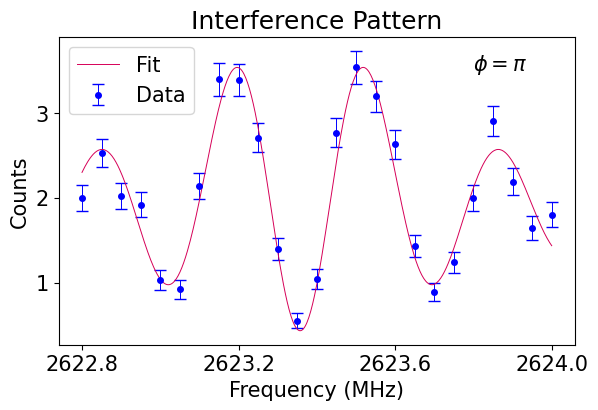

In [ ]:
''' Based on Intensity Fit. Previous fits were based on electric field amplitude which is not technically correct for this experiment.'''
# Data on 10-May-2025 folder_name = 'Op_MW_MW_diff_freq_pi_phase_sinc'
freq_khz = np.array([2622800.0, 2622850.0, 2622900.0, 2622950.0, 2623000.0, 
                     2623050.0, 2623100.0, 2623150.0, 2623200.0, 2623250.0, 
                     2623300.0, 2623350.0, 2623400.0, 2623450.0, 2623500.0, 
                     2623550.0, 2623600.0, 2623650.0, 2623700.0, 2623750.0, 
                     2623800.0, 2623850.0, 2623900.0, 2623950.0, 2624000.0])
noise_floor = np.array([0.31, 0.36, 0.27, 0.3, 0.25, 0.26, 0.34, 0.32, 0.32, 
                        0.33, 0.3, 0.29, 0.29, 0.29, 0.35, 0.24, 0.25, 0.33,
                          0.29, 0.35, 0.27, 0.31, 0.29, 0.34, 0.32
                          ])
counts_mean = np.array([2.31, 2.89, 2.29, 2.22, 1.28, 1.18, 2.48, 3.72, 3.71,
                         3.04, 1.7, 0.84, 1.33, 3.06, 3.89, 3.44, 2.88, 1.76,
                         1.18, 1.59, 2.27, 3.22, 2.48, 1.98, 2.12
                       ])
counts_std =  np.array([0.152, 0.17, 0.151, 0.149, 0.113, 0.109, 0.157, 0.193, 
                        0.193, 0.174, 0.13, 0.092, 0.115, 0.175, 0.197, 0.185, 
                        0.17, 0.133, 0.109, 0.126, 0.151, 0.179, 0.157, 0.141, 0.146
                       ])

# Subtract noise floor from mean counts
signal = counts_mean - noise_floor

# Define the custom fitting function
def custom_interference_func(f, I1, I2, f0,k, gamma, phi):
    """
    Custom interference function:
    f(freq) = I1 + I2*L(delta) + 2*sqrt(I1*I2*L(delta))*cos(delta)
    where delta = f - f0
    and L(delta) = (gamma/2)^2 / (delta^2 + (gamma/2)^2)
    """
    delta = f - f0
    gamma_half_sq = (gamma / 2.0)**2
    lorentzian = gamma_half_sq / (delta**2 + gamma_half_sq + 1e-15)
    interference = I1 + I2 * lorentzian + 2 * np.sqrt(I1 * I2 * lorentzian) * np.cos(k*delta+ phi)
    return interference

# Initial guesses: I1, I2, f0, k, gamma
I1_guess = np.max(signal)/2
I2_guess = np.max(signal)/2
f0_guess = 2623355  # in kHz, rough estimate
k_guess = 0.019  # initial guess for k   
gamma_guess = 500  # in kHz, rough estimate
phi_guess = 2  # initial guess for phase
# Perform the fit
popt, pcov = curve_fit(
    custom_interference_func, freq_khz, signal, sigma=counts_std, absolute_sigma=True,
    p0=[I1_guess, I2_guess, f0_guess, k_guess, gamma_guess, phi_guess],
    bounds=([0, 0, freq_khz.min(), 0, 400, -np.pi], [2, 2, freq_khz.max(), 1, 600, np.pi])
)

print("Fit params: I1={:.2f}, I2={:.2f}, f0={:.2f} kHz, k={:.4f}, gamma={:.2f} kHz, phi={:.2f} rad".format(*popt))
# Calculate R^2 value for the fit
residuals = signal - custom_interference_func(freq_khz, *popt)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((signal - np.mean(signal))**2)
r2 = 1 - (ss_res / ss_tot)
print(f"R^2 value: {r2:.4f}")
# Calculate visibility at delta = 0
I1, I2, f0, k, gamma, phi = popt
lorentzian_0 = (gamma / 2.0)**2 / ((0)**2 + (gamma / 2.0)**2)
numerator = 2 * np.sqrt(I1 * I2 * lorentzian_0)
denominator = I1 + I2 * lorentzian_0
visibility = numerator / denominator
print(f"Visibility at delta=0: {visibility:.3f}")
# Plot data with error bars
plt.figure(figsize=(20/3, 4))
plt.errorbar(freq_khz/1000, signal, yerr=counts_std, fmt='o', 
             color='blue', markersize=4, capsize=4, elinewidth=0.7, label='Data')

# Plot fitted curve
freq_smooth = np.linspace(freq_khz.min(), freq_khz.max(), 500)
plt.plot(freq_smooth/1000, custom_interference_func(freq_smooth, *popt), '-', 
         color='#d60057', linewidth=0.7, label='Fit')

plt.xlabel('Frequency (MHz)')
plt.ylabel('Counts')
plt.title('Interference Pattern')
plt.legend()
plt.text(2623.8, 3.5, r'$\phi = \pi$')

plt.xticks(np.arange(2622.8, 2624.1, 0.4))
# plt.savefig('Plots/Interference_Fit_pi_phase.pdf')
plt.show()

## Frequency Interference 0 Phase

In [66]:
data_dir = 'Full_Sequence_Data/10May25_Op_MW_MW_diff_freq_same_phase_sinc' 
file_pattern = re.compile(r'Freq_([\d\.]+)kHz_f_(\d+)\.gzip')  # Adjust pattern to match your filenames

# Data storage dictionaries
amp_groups = {}
results = {}
results_std = {}
noise_results = {}

# Group files by amplitude
for filename in os.listdir(data_dir):
    match = file_pattern.match(filename)
    if match:
        amp = float(match.group(1))
        file_num = int(match.group(2))
        full_path = os.path.join(data_dir, filename)
        
        if amp not in amp_groups:
            amp_groups[amp] = []
        amp_groups[amp].append(full_path)

# Process each amplitude group
for amp, files in amp_groups.items():
    counts = []
    noise_counts = []
    for file in sorted(files, key=lambda x: int(re.search(r'_(\d+)\.', x).group(1))):
        counts.append(read_gzip_counts_photons(file, 467e3, 4e3))
        noise_counts.append(read_gzip_counts_photons(file, 477e3, 4e3))  # Replace with actual noise counting function if available
        # print(file)
    
    results[amp] = np.mean(counts)
    results_std[amp] = np.sqrt(np.mean(counts)/len(files))
    noise_results[amp] = np.mean(noise_counts)

# Sort results by amplitude
sorted_amps = sorted(results.keys())
sorted_means = [results[amp] for amp in sorted_amps]
sorted_stds = [round(results_std[amp], 3) for amp in sorted_amps]
print("Sorted Amplitudes:", np.array(sorted_amps))
print("Sorted Means:", np.array(sorted_means))
print("Sorted Stds:", np.array(sorted_stds))
print("Sorted Noise Means:", np.array([noise_results[amp] for amp in sorted_amps]))

Sorted Amplitudes: [2622800. 2622850. 2622900. 2622950. 2623000. 2623050. 2623100. 2623150.
 2623200. 2623250. 2623300. 2623350. 2623400. 2623450. 2623500. 2623550.
 2623600. 2623650. 2623700. 2623750. 2623800. 2623850. 2623900. 2623950.
 2624000.]
Sorted Means: [1.92 1.5  1.85 2.63 3.72 3.48 2.03 0.97 1.03 1.89 3.44 4.39 3.61 2.29
 0.85 1.09 1.91 3.03 3.67 2.78 2.13 1.54 1.79 2.01 2.3 ]
Sorted Stds: [0.139 0.122 0.136 0.162 0.193 0.187 0.142 0.098 0.101 0.137 0.185 0.21
 0.19  0.151 0.092 0.104 0.138 0.174 0.192 0.167 0.146 0.124 0.134 0.142
 0.152]
Sorted Noise Means: [0.37 0.29 0.29 0.36 0.31 0.34 0.23 0.27 0.27 0.34 0.32 0.31 0.22 0.34
 0.2  0.25 0.26 0.3  0.43 0.26 0.28 0.2  0.25 0.25 0.37]


Fit parameters: I1=1.83, I2=0.46, f0=2623354.32 kHz, k=0.0181, gamma=475.87 kHz
R^2 value: 0.9627
Visibility at delta=0: 0.802


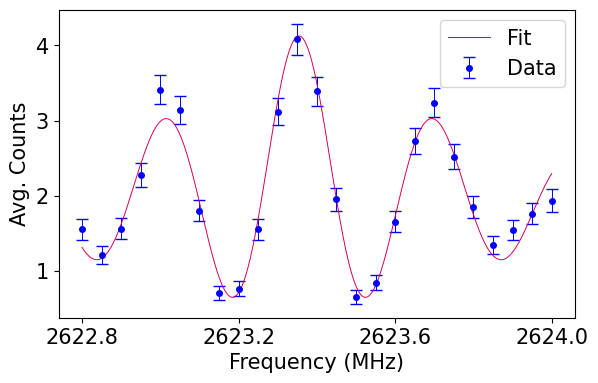

In [15]:
''' Based on Intensity Fit. Previous fits were based on electric field amplitude which is not technically correct for this experiment.'''
# Data on 10-May-2025 folder_name = 'Op_MW_MW_diff_freq_same_phase_sinc'
freq_khz = np.array([2622800.0, 2622850.0, 2622900.0, 2622950.0, 2623000.0, 
                     2623050.0, 2623100.0, 2623150.0, 2623200.0, 2623250.0, 
                     2623300.0, 2623350.0, 2623400.0, 2623450.0, 2623500.0, 
                     2623550.0, 2623600.0, 2623650.0, 2623700.0, 2623750.0, 
                     2623800.0, 2623850.0, 2623900.0, 2623950.0, 2624000.0])
noise_floor = np.array([0.37, 0.29, 0.29, 0.36, 0.31, 0.34, 0.23, 0.27, 0.27, 
                        0.34, 0.32, 0.31, 0.22, 0.34, 0.2, 0.25, 0.26, 0.3, 0.43, 
                        0.26, 0.28, 0.2, 0.25, 0.25, 0.37])
counts_mean = np.array([1.92, 1.5, 1.85, 2.63, 3.72, 3.48, 2.03, 0.97, 1.03, 
                        1.89, 3.44, 4.39, 3.61, 2.29, 0.85, 1.09, 1.91, 3.03,
                          3.67, 2.78, 2.13, 1.54, 1.79, 2.01, 2.3])
counts_std =  np.array([0.139, 0.122, 0.136, 0.162, 0.193, 0.187, 0.142, 0.098, 
                        0.101, 0.137, 0.185, 0.21, 0.19, 0.151, 0.092, 0.104, 
                        0.138, 0.174, 0.192, 0.167, 0.146, 0.124, 0.134, 0.142, 0.152])
# Subtract noise floor from mean counts
signal = counts_mean - noise_floor

# Define the custom fitting function
def custom_interference_func(f, I1, I2, f0,k, gamma):
    """
    Custom interference function:
    f(freq) = I1 + I2*L(delta) + 2*sqrt(I1*I2*L(delta))*cos(delta)
    where delta = f - f0
    and L(delta) = (gamma/2)^2 / (delta^2 + (gamma/2)^2)
    """
    delta = f - f0
    gamma_half_sq = (gamma / 2.0)**2
    lorentzian = gamma_half_sq / (delta**2 + gamma_half_sq + 1e-15)
    interference = I1 + I2 * lorentzian + 2 * np.sqrt(I1 * I2 * lorentzian) * np.cos(k*delta)
    return interference

# Initial guesses: I1, I2, f0, k, gamma
I1_guess = np.max(signal)/2
I2_guess = np.max(signal)/2
f0_guess = 2623355  # in kHz, rough estimate
k_guess = 0.01  # initial guess for k   
gamma_guess = 100  # in kHz, rough estimate

popt, pcov = curve_fit(
    custom_interference_func, freq_khz, signal, sigma=counts_std, absolute_sigma=True,
    p0=[I1_guess, I2_guess, f0_guess, k_guess, gamma_guess],
    bounds=([0, 0, freq_khz.min(), 0, 10], [10, 10, freq_khz.max(), 1, 1000])
)

print("Fit parameters: I1={:.2f}, I2={:.2f}, f0={:.2f} kHz, k={:.4f}, gamma={:.2f} kHz".format(*popt))
# Calculate R^2 value for the fit
residuals = signal - custom_interference_func(freq_khz, *popt)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((signal - np.mean(signal))**2)
r2 = 1 - (ss_res / ss_tot)
print(f"R^2 value: {r2:.4f}")
# Calculate visibility at delta = 0
I1, I2, f0, k, gamma = popt
lorentzian_0 = (gamma / 2.0)**2 / ((0)**2 + (gamma / 2.0)**2)
numerator = 2 * np.sqrt(I1 * I2 * lorentzian_0)
denominator = I1 + I2 * lorentzian_0
visibility = numerator / denominator
print(f"Visibility at delta=0: {visibility:.3f}")
# Plot data with error bars
plt.figure(figsize=(20/3, 4))
plt.errorbar(freq_khz/1000, signal, yerr=counts_std, fmt='o', 
             color='blue', markersize=4, capsize=4, elinewidth=0.7, label='Data')

# Plot fitted curve
freq_smooth = np.linspace(freq_khz.min(), freq_khz.max(), 500)
plt.plot(freq_smooth/1000, custom_interference_func(freq_smooth, *popt), '-', 
         color='#d60057', linewidth=0.7, label='Fit')

plt.xlabel('Frequency (MHz)')
plt.ylabel('Avg. Counts')
# plt.title('Interference Pattern (Intensity Fit)')
plt.legend()
plt.xticks(np.arange(2622.8, 2624.1, 0.4))
# plt.savefig('Plots/Interference_Fit_0_phase.pdf')
plt.show()

## Frequency Interference pi/2 Phase

In [67]:
data_dir = 'Full_Sequence_Data/10May25_Op_MW_MW_diff_freq_pihalf_phase_sinc' 
file_pattern = re.compile(r'Freq_([\d\.]+)kHz_f_(\d+)\.gzip')  # Adjust pattern to match your filenames

# Data storage dictionaries
amp_groups = {}
results = {}
results_std = {}
noise_results = {}

# Group files by amplitude
for filename in os.listdir(data_dir):
    match = file_pattern.match(filename)
    if match:
        amp = float(match.group(1))
        file_num = int(match.group(2))
        full_path = os.path.join(data_dir, filename)
        
        if amp not in amp_groups:
            amp_groups[amp] = []
        amp_groups[amp].append(full_path)

# Process each amplitude group
for amp, files in amp_groups.items():
    counts = []
    noise_counts = []
    for file in sorted(files, key=lambda x: int(re.search(r'_(\d+)\.', x).group(1))):
        counts.append(read_gzip_counts_photons(file, 467e3, 4e3))
        noise_counts.append(read_gzip_counts_photons(file, 477e3, 4e3))  # Replace with actual noise counting function if available
        # print(file)
    
    results[amp] = np.mean(counts)
    results_std[amp] = np.sqrt(np.mean(counts)/len(files))
    noise_results[amp] = np.mean(noise_counts)

# Sort results by amplitude
sorted_amps = sorted(results.keys())
sorted_means = [results[amp] for amp in sorted_amps]
sorted_stds = [round(results_std[amp], 3) for amp in sorted_amps]
print("Sorted Amplitudes:", np.array(sorted_amps))
print("Sorted Means:", np.array(sorted_means))
print("Sorted Stds:", np.array(sorted_stds))
print("Sorted Noise Means:", np.array([noise_results[amp] for amp in sorted_amps]))

Sorted Amplitudes: [2622800. 2622850. 2622900. 2622950. 2623000. 2623050. 2623100. 2623150.
 2623200. 2623250. 2623300. 2623350. 2623400. 2623450. 2623500. 2623550.
 2623600. 2623650. 2623700. 2623750. 2623800. 2623850. 2623900. 2623950.
 2624000.]
Sorted Means: [1.72 2.38 2.67 3.25 2.85 1.38 0.99 1.54 2.95 4.14 4.41 2.75 1.01 0.92
 1.86 3.21 3.96 3.33 2.29 1.44 1.35 2.35 2.3  2.59 2.11]
Sorted Stds: [0.131 0.154 0.163 0.18  0.169 0.117 0.099 0.124 0.172 0.203 0.21  0.166
 0.1   0.096 0.136 0.179 0.199 0.182 0.151 0.12  0.116 0.153 0.152 0.161
 0.145]
Sorted Noise Means: [0.35 0.26 0.3  0.25 0.29 0.29 0.25 0.34 0.23 0.23 0.37 0.32 0.31 0.26
 0.35 0.27 0.27 0.27 0.27 0.42 0.35 0.35 0.24 0.3  0.34]


Fit params: I1=1.79, I2=0.58, f0=2623352.69 kHz, k=0.0186, gamma=429.96 kHz, phi=1.59 rad
R^2 value: 0.9585
Visibility at delta=0: 0.862


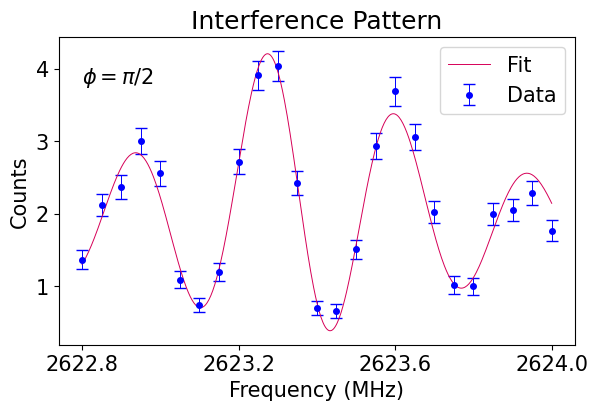

In [16]:
# Data on 10-May-2025 folder_name = 'Op_MW_MW_diff_freq_pihalf_phase_sinc'
freq_khz = np.array([2622800.0, 2622850.0, 2622900.0, 2622950.0, 2623000.0, 
                     2623050.0, 2623100.0, 2623150.0, 2623200.0, 2623250.0, 
                     2623300.0, 2623350.0, 2623400.0, 2623450.0, 2623500.0, 
                     2623550.0, 2623600.0, 2623650.0, 2623700.0, 2623750.0, 
                     2623800.0, 2623850.0, 2623900.0, 2623950.0, 2624000.0])
noise_floor = np.array([0.35, 0.26, 0.3, 0.25, 0.29, 0.29, 0.25, 0.34, 0.23, 
                        0.23, 0.37, 0.32, 0.31, 0.26, 0.35, 0.27, 0.27, 0.27,
                          0.27, 0.42, 0.35, 0.35, 0.24, 0.3, 0.34])
counts_mean = np.array([1.72, 2.38, 2.67, 3.25, 2.85, 1.38, 0.99, 1.54, 2.95, 
                        4.14, 4.41, 2.75, 1.01, 0.92, 1.86, 3.21, 3.96, 3.33, 
                        2.29, 1.44, 1.35, 2.35, 2.3, 2.59, 2.11])
counts_std =  np.array([0.131, 0.154, 0.163, 0.18, 0.169, 0.117, 0.099, 0.124, 
                        0.172, 0.203, 0.21, 0.166, 0.1, 0.096, 0.136, 0.179, 
                        0.199, 0.182, 0.151, 0.12, 0.116, 0.153, 0.152, 0.161, 0.145])
# Subtract noise floor from mean counts
signal = counts_mean - noise_floor

# Initial guesses: I1, I2, f0, k, gamma
I1_guess = np.max(signal)/2
I2_guess = np.max(signal)/2
f0_guess = 2623355  # in kHz, rough estimate
k_guess = 0.019  # initial guess for k   
gamma_guess = 500  # in kHz, rough estimate
phi_guess = np.pi/2  # initial guess for phase
# Perform the fit
def custom_interference_func(f, I1, I2, f0, k, gamma, phi):
  delta = f - f0
  gamma_half_sq = (gamma / 2.0)**2
  lorentzian = gamma_half_sq / (delta**2 + gamma_half_sq + 1e-15)
  interference = I1 + I2 * lorentzian + 2 * np.sqrt(I1 * I2 * lorentzian) * np.cos(k*delta + phi)
  return interference

popt, pcov = curve_fit(
  custom_interference_func, freq_khz, signal, sigma=counts_std, absolute_sigma=True,
  p0=[I1_guess, I2_guess, f0_guess, k_guess, gamma_guess, phi_guess],
  bounds=([0, 0, freq_khz.min(), 0, 10, -np.pi], [10, 10, freq_khz.max(), 1, 1000, np.pi])
)

print("Fit params: I1={:.2f}, I2={:.2f}, f0={:.2f} kHz, k={:.4f}, gamma={:.2f} kHz, phi={:.2f} rad".format(*popt))
# Calculate R^2 value for the fit
residuals = signal - custom_interference_func(freq_khz, *popt)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((signal - np.mean(signal))**2)
r2 = 1 - (ss_res / ss_tot)
print(f"R^2 value: {r2:.4f}")
# Calculate visibility at delta = 0
I1, I2, f0, k, gamma, phi = popt
lorentzian_0 = (gamma / 2.0)**2 / ((0)**2 + (gamma / 2.0)**2)
numerator = 2 * np.sqrt(I1 * I2 * lorentzian_0)
denominator = I1 + I2 * lorentzian_0
visibility = numerator / denominator
print(f"Visibility at delta=0: {visibility:.3f}")
# Plot data with error bars
plt.figure(figsize=(20/3, 4))
plt.errorbar(freq_khz/1000, signal, yerr=counts_std, fmt='o', 
             color='blue', markersize=4, capsize=4, elinewidth=0.7, label='Data')

# Plot fitted curve
freq_smooth = np.linspace(freq_khz.min(), freq_khz.max(), 500)
plt.plot(freq_smooth/1000, custom_interference_func(freq_smooth, *popt), '-', 
         color='#d60057', linewidth=0.7, label='Fit')

plt.xlabel('Frequency (MHz)')
plt.ylabel('Counts')
plt.title('Interference Pattern')
plt.legend()
plt.text(2622.8, 3.8, r'$\phi = \pi/2$')

plt.xticks(np.arange(2622.8, 2624.1, 0.4))
# plt.savefig('Plots/Interference_Fit_pihalf_phase.pdf')
plt.show()

## LO Interference

### Leak Counts

In [3]:
pm_0_AOM_0_early = 11.51
pm_0_AOM_0_late = 11.92
pm_0_AOM_1_early = 28.63
pm_0_AOM_1_late = 28.67
pm_1_AOM_0_early = 4.78
pm_1_AOM_0_late = 6.26
pm_1_AOM_1_early = 16.65
pm_1_AOM_1_late = 17.17

0.403096903096903

#### Data Extraction for interference plots

In [68]:
data_dir = 'Full_Sequence_Data/18July25_Interference_MW1_ON_Phase_MW2_OFF_3' 
file_pattern = re.compile(r'Phase_([\d\.]+)mRad_f_(\d+)\.gzip')  # Adjust pattern to match your filenames

# Data storage dictionaries
amp_groups = {}
results = {}
results_std = {}

# Group files by amplitude
for filename in os.listdir(data_dir):
    match = file_pattern.match(filename)
    if match:
        amp = float(match.group(1))  # Handle decimal amplitudes if needed
        file_num = int(match.group(2))
        full_path = os.path.join(data_dir, filename)
        
        if amp not in amp_groups:
            amp_groups[amp] = []
        amp_groups[amp].append(full_path)

# Process each amplitude group
for amp, files in amp_groups.items():
    counts = []
    for file in sorted(files, key=lambda x: int(re.search(r'_(\d+)\.', x).group(1))):
        counts.append(read_gzip_counts_photons(file, 461e3, 4e3))
        # print(file)
    
    results[amp] = np.mean(counts)
    results_std[amp] = np.sqrt(np.mean(counts)/len(files))

# Sort results by amplitude
sorted_amps = sorted(results.keys())
sorted_means = [results[amp] for amp in sorted_amps]
sorted_stds = [round(results_std[amp],3) for amp in sorted_amps]
print('+ Detuned, Early Pulse')
print(sorted_amps)
# Print as regular floats, rounded to 2 decimals
print("Sorted Means:", [float(x) for x in sorted_means])
print("Sorted Stds:", [float(x) for x in sorted_stds])

# Configuration
# data_dir = folder_name  # Update this path
file_pattern = re.compile(r'Phase_([\d\.]+)mRad_f_(\d+)\.gzip')  # Adjust pattern to match your filenames

# Data storage dictionaries
amp_groups = {}
results = {}
results_std = {}
# Group files by amplitude
for filename in os.listdir(data_dir):
    match = file_pattern.match(filename)
    if match:
        amp = float(match.group(1))  # Handle decimal amplitudes if needed
        file_num = int(match.group(2))
        full_path = os.path.join(data_dir, filename)
        
        if amp not in amp_groups:
            amp_groups[amp] = []
        amp_groups[amp].append(full_path)

# Process each amplitude group
for amp, files in amp_groups.items():
    counts = []
    for file in sorted(files, key=lambda x: int(re.search(r'_(\d+)\.', x).group(1))):
        counts.append(read_gzip_counts_photons(file, 467e3, 4e3))

        # print(file)
    
    results[amp] = np.mean(counts)
    results_std[amp] = np.sqrt(np.mean(counts)/len(files))

# Sort results by amplitude
sorted_amps = sorted(results.keys())
sorted_means = [results[amp] for amp in sorted_amps]
sorted_stds = [round(results_std[amp],3) for amp in sorted_amps]
print('-Detuned, Late Pulse')

# Print as regular floats, rounded to 2 decimals
print("Sorted Means:", [float(x) for x in sorted_means])
print("Sorted Stds:", [float(x) for x in sorted_stds])

+ Detuned, Early Pulse
[0.0, 157.0, 314.0, 471.0, 628.0, 785.0, 942.0, 1099.0, 1256.0, 1413.0, 1570.0, 1727.0, 1884.0, 2042.0, 2199.0, 2356.0, 2513.0, 2670.0, 2827.0, 2984.0, 3141.0, 3298.0, 3455.0, 3612.0, 3769.0, 3926.0, 4084.0, 4241.0, 4398.0, 4555.0, 4712.0, 4869.0, 5026.0, 5183.0, 5340.0, 5497.0, 5654.0, 5811.0, 5969.0, 6126.0, 6283.0]
Sorted Means: [28.09, 29.35, 30.39, 29.47, 29.84, 30.52, 28.7, 29.63, 29.54, 28.69, 28.29, 27.12, 28.73, 27.89, 27.98, 26.68, 27.38, 26.8, 25.32, 26.55, 26.99, 27.32, 26.5, 26.73, 26.23, 27.03, 26.59, 25.35, 28.47, 27.62, 28.16, 27.91, 29.2, 28.43, 28.88, 29.36, 27.98, 29.53, 28.19, 28.49, 28.74]
Sorted Stds: [0.53, 0.542, 0.551, 0.543, 0.546, 0.552, 0.536, 0.544, 0.544, 0.536, 0.532, 0.521, 0.536, 0.528, 0.529, 0.517, 0.523, 0.518, 0.503, 0.515, 0.52, 0.523, 0.515, 0.517, 0.512, 0.52, 0.516, 0.503, 0.534, 0.526, 0.531, 0.528, 0.54, 0.533, 0.537, 0.542, 0.529, 0.543, 0.531, 0.534, 0.536]
-Detuned, Late Pulse
Sorted Means: [23.39, 24.57, 24.89, 25.11

In [69]:
data_dir = 'Full_Sequence_Data/18July25_Interference_MW1_OFF_MW2_ON_Phase_5' 
file_pattern = re.compile(r'Phase_([\d\.]+)mRad_f_(\d+)\.gzip')  # Adjust pattern to match your filenames

# Data storage dictionaries
amp_groups = {}
results = {}
results_std = {}

# Group files by amplitude
for filename in os.listdir(data_dir):
    match = file_pattern.match(filename)
    if match:
        amp = float(match.group(1))  # Handle decimal amplitudes if needed
        file_num = int(match.group(2))
        full_path = os.path.join(data_dir, filename)
        
        if amp not in amp_groups:
            amp_groups[amp] = []
        amp_groups[amp].append(full_path)

# Process each amplitude group
for amp, files in amp_groups.items():
    counts = []
    for file in sorted(files, key=lambda x: int(re.search(r'_(\d+)\.', x).group(1))):
        counts.append(read_gzip_counts_photons(file, 461e3, 4e3))
        # print(file)
    
    results[amp] = np.mean(counts)
    results_std[amp] = np.sqrt(np.mean(counts)/len(files))

# Sort results by amplitude
sorted_amps = sorted(results.keys())
sorted_means = [results[amp] for amp in sorted_amps]
sorted_stds = [round(results_std[amp],3) for amp in sorted_amps]
print('+ Detuned, Early Pulse')
print(sorted_amps)
# Print as regular floats, rounded to 2 decimals
print("Sorted Means:", [float(x) for x in sorted_means])
print("Sorted Stds:", [float(x) for x in sorted_stds])

# Configuration
# data_dir = folder_name  # Update this path
file_pattern = re.compile(r'Phase_([\d\.]+)mRad_f_(\d+)\.gzip')  # Adjust pattern to match your filenames

# Data storage dictionaries
amp_groups = {}
results = {}
results_std = {}
# Group files by amplitude
for filename in os.listdir(data_dir):
    match = file_pattern.match(filename)
    if match:
        amp = float(match.group(1))  # Handle decimal amplitudes if needed
        file_num = int(match.group(2))
        full_path = os.path.join(data_dir, filename)
        
        if amp not in amp_groups:
            amp_groups[amp] = []
        amp_groups[amp].append(full_path)

# Process each amplitude group
for amp, files in amp_groups.items():
    counts = []
    for file in sorted(files, key=lambda x: int(re.search(r'_(\d+)\.', x).group(1))):
        counts.append(read_gzip_counts_photons(file, 467e3, 4e3))

        # print(file)
    
    results[amp] = np.mean(counts)
    results_std[amp] = np.sqrt(np.mean(counts)/len(files))

# Sort results by amplitude
sorted_amps = sorted(results.keys())
sorted_means = [results[amp] for amp in sorted_amps]
sorted_stds = [round(results_std[amp],3) for amp in sorted_amps]
print('-Detuned, Late Pulse')

# Print as regular floats, rounded to 2 decimals
print("Sorted Means:", [float(x) for x in sorted_means])
print("Sorted Stds:", [float(x) for x in sorted_stds])

+ Detuned, Early Pulse
[0.0, 157.0, 314.0, 471.0, 628.0, 785.0, 942.0, 1099.0, 1256.0, 1413.0, 1570.0, 1727.0, 1884.0, 2042.0, 2199.0, 2356.0, 2513.0, 2670.0, 2827.0, 2984.0, 3141.0, 3298.0, 3455.0, 3612.0, 3769.0, 3926.0, 4084.0, 4241.0, 4398.0, 4555.0, 4712.0, 4869.0, 5026.0, 5183.0, 5340.0, 5497.0, 5654.0, 5811.0, 5969.0, 6126.0, 6283.0]
Sorted Means: [22.33, 22.86, 23.0, 23.59, 22.93, 22.39, 22.76, 22.22, 23.32, 22.65, 22.83, 22.75, 23.12, 22.26, 23.31, 22.68, 22.23, 22.38, 22.43, 22.02, 23.41, 23.74, 22.19, 22.74, 23.67, 23.47, 22.38, 23.71, 23.75, 24.26, 23.47, 24.51, 22.88, 22.77, 22.37, 23.1, 22.76, 22.89, 24.09, 24.07, 24.27]
Sorted Stds: [0.473, 0.478, 0.48, 0.486, 0.479, 0.473, 0.477, 0.471, 0.483, 0.476, 0.478, 0.477, 0.481, 0.472, 0.483, 0.476, 0.471, 0.473, 0.474, 0.469, 0.484, 0.487, 0.471, 0.477, 0.487, 0.484, 0.473, 0.487, 0.487, 0.493, 0.484, 0.495, 0.478, 0.477, 0.473, 0.481, 0.477, 0.478, 0.491, 0.491, 0.493]
-Detuned, Late Pulse
Sorted Means: [30.53, 30.75, 30.78, 

### MW1 ON and OFF while MW2 OFF

A = 11.8150 ± 1.34e-01
V = 0.1228 ± 1.36e-02
k = 1.1854 ± 8.71e-02
phi = -0.7982 ± 2.98e-01
R^2 value: 0.6998


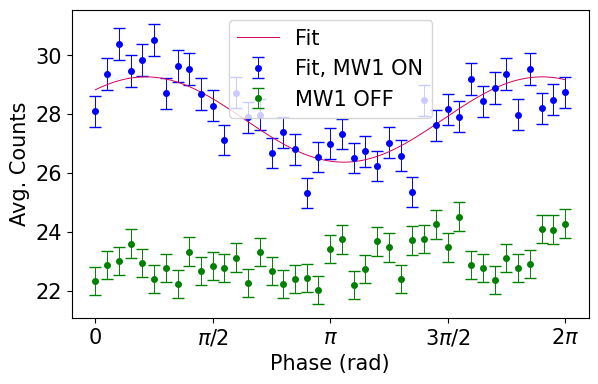

In [ ]:
# Data on 18-July-2025 
'''Plotting the early counts with MW ON and OFF'''
# folder_name = 'Interference_MW1_ON_Phase_MW2_OFF_3' & 'Interference_MW1_OFF_MW2_ON_Phase_5'
phase = np.array([0.0, 157.0, 314.0, 471.0, 628.0, 785.0, 942.0, 1099.0, 1256.0, 1413.0, 1570.0, 1727.0, 1884.0, 2042.0, 2199.0, 2356.0, 2513.0, 2670.0, 2827.0, 2984.0, 3141.0, 3298.0, 3455.0, 3612.0, 3769.0, 3926.0, 4084.0, 4241.0, 4398.0, 4555.0, 4712.0, 4869.0, 5026.0, 5183.0, 5340.0, 5497.0, 5654.0, 5811.0, 5969.0, 6126.0, 6283.0])
phase = phase/1000  # Convert to radians
counts_MW1_ON_Phase_MW2_off_early = np.array([28.09, 29.35, 30.39, 29.47, 29.84, 30.52, 28.7, 29.63, 29.54, 28.69, 28.29, 27.12, 28.73, 27.89, 27.98, 26.68, 27.38, 26.8, 25.32, 26.55, 26.99, 27.32, 26.5, 26.73, 26.23, 27.03, 26.59, 25.35, 28.47, 27.62, 28.16, 27.91, 29.2, 28.43, 28.88, 29.36, 27.98, 29.53, 28.19, 28.49, 28.74])
std_MW1_ON_Phase_MW2_off_early = np.array([0.53, 0.542, 0.551, 0.543, 0.546, 0.552, 0.536, 0.544, 0.544, 0.536, 0.532, 0.521, 0.536, 0.528, 0.529, 0.517, 0.523, 0.518, 0.503, 0.515, 0.52, 0.523, 0.515, 0.517, 0.512, 0.52, 0.516, 0.503, 0.534, 0.526, 0.531, 0.528, 0.54, 0.533, 0.537, 0.542, 0.529, 0.543, 0.531, 0.534, 0.536])

counts_MW1_off_MW2_ON_Phase_early = np.array([22.33, 22.86, 23.0, 23.59, 22.93, 22.39, 22.76, 22.22, 23.32, 22.65, 22.83, 22.75, 23.12, 22.26, 23.31, 22.68, 22.23, 22.38, 22.43, 22.02, 23.41, 23.74, 22.19, 22.74, 23.67, 23.47, 22.38, 23.71, 23.75, 24.26, 23.47, 24.51, 22.88, 22.77, 22.37, 23.1, 22.76, 22.89, 24.09, 24.07, 24.27])
std_MW1_off_MW2_ON_Phase_early = np.array([0.473, 0.478, 0.48, 0.486, 0.479, 0.473, 0.477, 0.471, 0.483, 0.476, 0.478, 0.477, 0.481, 0.472, 0.483, 0.476, 0.471, 0.473, 0.474, 0.469, 0.484, 0.487, 0.471, 0.477, 0.487, 0.484, 0.473, 0.487, 0.487, 0.493, 0.484, 0.495, 0.478, 0.477, 0.473, 0.481, 0.477, 0.478, 0.491, 0.491, 0.493])

# Define visibility function without offset C
def visibility_func(x, A, V, k, phi, C=16):
    return A * (1 + V * np.cos(k*x + phi))+C

# Set bounds for the fit parameters: [A, V, k, phi, C]
bounds_early = ([0, 0, 0, -2*np.pi], [20, 1, 10, 2*np.pi])

# Perform the fit again with bounds
popt_early, pcov_early = curve_fit(
    visibility_func, phase, counts_MW1_ON_Phase_MW2_off_early,
    p0=[12, 0.5, 0.1, 0],
    sigma=std_MW1_ON_Phase_MW2_off_early,
    bounds=bounds_early
)
perr_early = np.sqrt(np.diag(pcov_early))

# Calculate R^2 value for the fit
residuals_early = counts_MW1_ON_Phase_MW2_off_early - visibility_func(phase, *popt_early)
ss_res_early = np.sum(residuals_early**2)
ss_tot_early = np.sum((counts_MW1_ON_Phase_MW2_off_early - np.mean(counts_MW1_ON_Phase_MW2_off_early))**2)
r2_early = 1 - (ss_res_early / ss_tot_early)

# Print fit parameters with names and R^2 value
param_names = ['A', 'V', 'k', 'phi', 'C']
for name, val, err in zip(param_names, popt_early, perr_early):
    print(f"{name} = {val:.4f} ± {err:.2e}")
print(f"R^2 value: {r2_early:.4f}")
# Generate smooth curve for plotting
phase_smooth = np.linspace(0, 2*np.pi, 200)
y_fit_early = visibility_func(phase_smooth, *popt_early)

# Create plot
plt.figure(figsize=(20/3, 4))

# Plot data and fit for MW1 ON MW2 OFF early
plt.errorbar(phase, counts_MW1_ON_Phase_MW2_off_early, 
            yerr=std_MW1_ON_Phase_MW2_off_early,
            fmt='o', color='blue', markersize=4, 
            capsize=4, elinewidth=0.7, label='Fit, MW1 ON')
plt.plot(phase_smooth, y_fit_early, '-', color='#d60057', 
         linewidth=0.7, label='Fit')

# Plot data points for MW1 off MW2 ON early
plt.errorbar(phase, counts_MW1_off_MW2_ON_Phase_early, 
            yerr=std_MW1_off_MW2_ON_Phase_early,
            fmt='o', color='green', markersize=4, 
            capsize=4, elinewidth=0.7, label='MW1 OFF')

plt.xlabel('Phase (rad)')
plt.ylabel('Avg. Counts')
# plt.title('Visibility Pattern')
plt.legend()
plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi], 
           ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])

# Add visibility
visibility = popt_early[1]
visibility_err = perr_early[1]

# plt.savefig('Plots/Visibility_early_compare.pdf')
plt.show()

### MW1 OFF while MW2 ON and OFF

R^2 value: 0.8850
A = 11.7229 ± 2.33e-01
V = 0.2257 ± 1.43e-02
k = -0.9623 ± 7.46e-02
phi = 0.0723 ± 2.56e-01


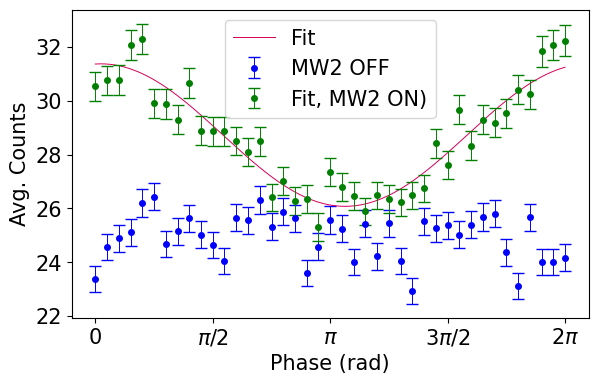

In [ ]:
# Data on 18-July-2025 
# folder_name = 'Interference_MW1_OFF_MW2_ON_Phase_5' & 'Interference_MW1_ON_Phase_MW2_OFF_3'

'''Plotting the late counts with MW ON and OFF'''
phase = np.array([0.0, 157.0, 314.0, 471.0, 628.0, 785.0, 942.0, 1099.0, 1256.0, 1413.0, 1570.0, 1727.0, 1884.0, 2042.0, 2199.0, 2356.0, 2513.0, 2670.0, 2827.0, 2984.0, 3141.0, 3298.0, 3455.0, 3612.0, 3769.0, 3926.0, 4084.0, 4241.0, 4398.0, 4555.0, 4712.0, 4869.0, 5026.0, 5183.0, 5340.0, 5497.0, 5654.0, 5811.0, 5969.0, 6126.0, 6283.0])
phase = phase/1000  # Convert to radians

counts_MW1_ON_Phase_MW2_off_late = np.array([23.39, 24.57, 24.89, 25.11, 26.21, 26.44, 24.68, 25.15, 25.63, 25.03, 24.64, 24.04, 25.66, 25.56, 26.32, 25.32, 25.88, 25.63, 23.61, 24.58, 25.57, 25.24, 24.0, 25.43, 24.22, 25.45, 24.05, 22.94, 25.52, 25.27, 25.38, 25.02, 25.4, 25.68, 25.8, 24.37, 23.11, 25.67, 24.01, 24.0, 24.17])
std_MW1_ON_Phase_MW2_off_late = np.array([0.484, 0.496, 0.499, 0.501, 0.512, 0.514, 0.497, 0.501, 0.506, 0.5, 0.496, 0.49, 0.507, 0.506, 0.513, 0.503, 0.509, 0.506, 0.486, 0.496, 0.506, 0.502, 0.49, 0.504, 0.492, 0.504, 0.49, 0.479, 0.505, 0.503, 0.504, 0.5, 0.504, 0.507, 0.508, 0.494, 0.481, 0.507, 0.49, 0.49, 0.492])

counts_MW1_off_MW2_ON_Phase_late = np.array([30.53, 30.75, 30.78, 32.07, 32.29, 29.9, 29.87, 29.3, 30.65, 28.89, 28.87, 28.86, 28.5, 28.1, 28.49, 26.41, 27.02, 26.27, 26.34, 25.31, 27.36, 26.8, 26.45, 25.89, 26.48, 26.35, 26.22, 26.48, 26.74, 28.42, 27.62, 29.67, 28.33, 29.3, 29.18, 29.53, 30.41, 30.23, 31.83, 32.07, 32.23])
std_MW1_off_MW2_ON_Phase_late = np.array([0.553, 0.555, 0.555, 0.566, 0.568, 0.547, 0.547, 0.541, 0.554, 0.537, 0.537, 0.537, 0.534, 0.53, 0.534, 0.514, 0.52, 0.513, 0.513, 0.503, 0.523, 0.518, 0.514, 0.509, 0.515, 0.513, 0.512, 0.515, 0.517, 0.533, 0.526, 0.545, 0.532, 0.541, 0.54, 0.543, 0.551, 0.55, 0.564, 0.566, 0.568])
# Define visibility function without offset C
def visibility_func(x, A, V, k, phi, C=17):
    return A * (1 + V * np.cos(k*x + phi))+C

# Set bounds for the fit parameters: [A, V, k, phi, C]
bounds_late = ([1, 0, -10, -2*np.pi], [15, 1, 10, 2*np.pi])

# Perform the fit again with bounds
popt_late, pcov_late = curve_fit(
    visibility_func, phase, counts_MW1_off_MW2_ON_Phase_late,
    p0=[5, 0.1, 0.1, 0],
    sigma=std_MW1_off_MW2_ON_Phase_late,
    bounds=bounds_late
)


# Calculate R^2 value for the fit
residuals_late = counts_MW1_off_MW2_ON_Phase_late - visibility_func(phase, *popt_late)
ss_res_late = np.sum(residuals_late**2)
ss_tot_late = np.sum((counts_MW1_off_MW2_ON_Phase_late - np.mean(counts_MW1_off_MW2_ON_Phase_late))**2)
r2_late = 1 - (ss_res_late / ss_tot_late)
print(f"R^2 value: {r2_late:.4f}")
perr_late = np.sqrt(np.diag(pcov_late))
# Generate smooth curve for plotting
phase_smooth = np.linspace(0, 2*np.pi, 200)
y_fit_late = visibility_func(phase_smooth, *popt_late)

# Print fit parameters with names and R^2 value
param_names = ['A', 'V', 'k', 'phi', 'C']
for name, val, err in zip(param_names, popt_late, perr_late):
    print(f"{name} = {val:.4f} ± {err:.2e}")

# Create plot
plt.figure(figsize=(20/3, 4))

# Plot data and fit for MW1 ON MW2 OFF late
plt.errorbar(phase, counts_MW1_ON_Phase_MW2_off_late, 
            yerr=std_MW1_ON_Phase_MW2_off_late,
            fmt='o', color='blue', markersize=4, 
            capsize=4, elinewidth=0.7, label='MW2 OFF')
plt.plot(phase_smooth, y_fit_late, '-', color='#d60057', 
         linewidth=0.7, label='Fit')

# Plot data points for MW1 off MW2 ON late
plt.errorbar(phase, counts_MW1_off_MW2_ON_Phase_late, 
            yerr=std_MW1_off_MW2_ON_Phase_late,
            fmt='o', color='green', markersize=4, 
            capsize=4, elinewidth=0.7, label='Fit, MW2 ON)')

plt.xlabel('Phase (rad)')
plt.ylabel('Avg. Counts')
# plt.title('Visibility Pattern')
plt.legend()
plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi], 
           ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])

# Add visibility
visibility = popt_late[1]
visibility_err = perr_late[1]
# plt.text(3, 30, f'Visibility = {100*visibility:.1f}%')

# plt.savefig('Plots/Visibility_late_compare.pdf')
plt.show()


### Both MW ON but one with Phase

In [70]:
data_dir = 'Full_Sequence_Data/18July25_Interference_MW1_ON_MW2_ON_Phase_5' 
file_pattern = re.compile(r'Phase_([\d\.]+)mRad_f_(\d+)\.gzip')  # Adjust pattern to match your filenames

# Data storage dictionaries
amp_groups = {}
results = {}
results_std = {}

# Group files by amplitude
for filename in os.listdir(data_dir):
    match = file_pattern.match(filename)
    if match:
        amp = float(match.group(1))  # Handle decimal amplitudes if needed
        file_num = int(match.group(2))
        full_path = os.path.join(data_dir, filename)
        
        if amp not in amp_groups:
            amp_groups[amp] = []
        amp_groups[amp].append(full_path)

# Process each amplitude group
for amp, files in amp_groups.items():
    counts = []
    for file in sorted(files, key=lambda x: int(re.search(r'_(\d+)\.', x).group(1))):
        counts.append(read_gzip_counts_photons(file, 461e3, 4e3))
        # print(file)
    
    results[amp] = np.mean(counts)
    results_std[amp] = np.sqrt(np.mean(counts)/len(files))

# Sort results by amplitude
sorted_amps = sorted(results.keys())
sorted_means = [results[amp] for amp in sorted_amps]
sorted_stds = [round(results_std[amp],3) for amp in sorted_amps]
print('+ Detuned, Early Pulse')
print(sorted_amps)
# Print as regular floats, rounded to 2 decimals
print("Sorted Means:", [float(x) for x in sorted_means])
print("Sorted Stds:", [float(x) for x in sorted_stds])

# Configuration
# data_dir = folder_name  # Update this path
file_pattern = re.compile(r'Phase_([\d\.]+)mRad_f_(\d+)\.gzip')  # Adjust pattern to match your filenames

# Data storage dictionaries
amp_groups = {}
results = {}
results_std = {}
# Group files by amplitude
for filename in os.listdir(data_dir):
    match = file_pattern.match(filename)
    if match:
        amp = float(match.group(1))  # Handle decimal amplitudes if needed
        file_num = int(match.group(2))
        full_path = os.path.join(data_dir, filename)
        
        if amp not in amp_groups:
            amp_groups[amp] = []
        amp_groups[amp].append(full_path)

# Process each amplitude group
for amp, files in amp_groups.items():
    counts = []
    for file in sorted(files, key=lambda x: int(re.search(r'_(\d+)\.', x).group(1))):
        counts.append(read_gzip_counts_photons(file, 467e3, 4e3))

        # print(file)
    
    results[amp] = np.mean(counts)
    results_std[amp] = np.sqrt(np.mean(counts)/len(files))

# Sort results by amplitude
sorted_amps = sorted(results.keys())
sorted_means = [results[amp] for amp in sorted_amps]
sorted_stds = [round(results_std[amp],3) for amp in sorted_amps]
print('-Detuned, Late Pulse')

# Print as regular floats, rounded to 2 decimals
print("Sorted Means:", [float(x) for x in sorted_means])
print("Sorted Stds:", [float(x) for x in sorted_stds])

+ Detuned, Early Pulse
[0.0, 157.0, 314.0, 471.0, 628.0, 785.0, 942.0, 1099.0, 1256.0, 1413.0, 1570.0, 1727.0, 1884.0, 2042.0, 2199.0, 2356.0, 2513.0, 2670.0, 2827.0, 2984.0, 3141.0, 3298.0, 3455.0, 3612.0, 3769.0, 3926.0, 4084.0, 4241.0, 4398.0, 4555.0, 4712.0, 4869.0, 5026.0, 5183.0, 5340.0, 5497.0, 5654.0, 5811.0, 5969.0, 6126.0, 6283.0]
Sorted Means: [29.96, 29.11, 28.21, 28.28, 28.85, 28.86, 28.73, 29.43, 29.88, 28.33, 28.61, 29.29, 28.57, 28.64, 29.86, 31.1, 30.29, 29.19, 30.17, 29.39, 30.48, 30.47, 29.65, 29.15, 30.16, 30.96, 30.33, 30.85, 30.14, 29.52, 30.93, 29.82, 30.58, 29.8, 29.63, 30.12, 29.69, 30.18, 29.19, 29.01, 28.43]
Sorted Stds: [0.547, 0.54, 0.531, 0.532, 0.537, 0.537, 0.536, 0.542, 0.547, 0.532, 0.535, 0.541, 0.535, 0.535, 0.546, 0.558, 0.55, 0.54, 0.549, 0.542, 0.552, 0.552, 0.545, 0.54, 0.549, 0.556, 0.551, 0.555, 0.549, 0.543, 0.556, 0.546, 0.553, 0.546, 0.544, 0.549, 0.545, 0.549, 0.54, 0.539, 0.533]
-Detuned, Late Pulse
Sorted Means: [31.12, 30.62, 30.65, 31.1

In [71]:
data_dir = 'Full_Sequence_Data/18July25_Interference_MW1_ON_Phase_MW2_ON_4' 
file_pattern = re.compile(r'Phase_([\d\.]+)mRad_f_(\d+)\.gzip')  # Adjust pattern to match your filenames

# Data storage dictionaries
amp_groups = {}
results = {}
results_std = {}

# Group files by amplitude
for filename in os.listdir(data_dir):
    match = file_pattern.match(filename)
    if match:
        amp = float(match.group(1))  # Handle decimal amplitudes if needed
        file_num = int(match.group(2))
        full_path = os.path.join(data_dir, filename)
        
        if amp not in amp_groups:
            amp_groups[amp] = []
        amp_groups[amp].append(full_path)

# Process each amplitude group
for amp, files in amp_groups.items():
    counts = []
    for file in sorted(files, key=lambda x: int(re.search(r'_(\d+)\.', x).group(1))):
        counts.append(read_gzip_counts_photons(file, 461e3, 4e3))
        # print(file)
    
    results[amp] = np.mean(counts)
    results_std[amp] = np.sqrt(np.mean(counts)/len(files))

# Sort results by amplitude
sorted_amps = sorted(results.keys())
sorted_means = [results[amp] for amp in sorted_amps]
sorted_stds = [round(results_std[amp],3) for amp in sorted_amps]
print('+ Detuned, Early Pulse')
print(sorted_amps)
# Print as regular floats, rounded to 2 decimals
print("Sorted Means:", [float(x) for x in sorted_means])
print("Sorted Stds:", [float(x) for x in sorted_stds])

# Configuration
# data_dir = folder_name  # Update this path
file_pattern = re.compile(r'Phase_([\d\.]+)mRad_f_(\d+)\.gzip')  # Adjust pattern to match your filenames

# Data storage dictionaries
amp_groups = {}
results = {}
results_std = {}
# Group files by amplitude
for filename in os.listdir(data_dir):
    match = file_pattern.match(filename)
    if match:
        amp = float(match.group(1))  # Handle decimal amplitudes if needed
        file_num = int(match.group(2))
        full_path = os.path.join(data_dir, filename)
        
        if amp not in amp_groups:
            amp_groups[amp] = []
        amp_groups[amp].append(full_path)

# Process each amplitude group
for amp, files in amp_groups.items():
    counts = []
    for file in sorted(files, key=lambda x: int(re.search(r'_(\d+)\.', x).group(1))):
        counts.append(read_gzip_counts_photons(file, 467e3, 4e3))

        # print(file)
    
    results[amp] = np.mean(counts)
    results_std[amp] = np.sqrt(np.mean(counts)/len(files))

# Sort results by amplitude
sorted_amps = sorted(results.keys())
sorted_means = [results[amp] for amp in sorted_amps]
sorted_stds = [round(results_std[amp],3) for amp in sorted_amps]
print('-Detuned, Late Pulse')

# Print as regular floats, rounded to 2 decimals
print("Sorted Means:", [float(x) for x in sorted_means])
print("Sorted Stds:", [float(x) for x in sorted_stds])

+ Detuned, Early Pulse
[0.0, 157.0, 314.0, 471.0, 628.0, 785.0, 942.0, 1099.0, 1256.0, 1413.0, 1570.0, 1727.0, 1884.0, 2042.0, 2199.0, 2356.0, 2513.0, 2670.0, 2827.0, 2984.0, 3141.0, 3298.0, 3455.0, 3612.0, 3769.0, 3926.0, 4084.0, 4241.0, 4398.0, 4555.0, 4712.0, 4869.0, 5026.0, 5183.0, 5340.0, 5497.0, 5654.0, 5811.0, 5969.0, 6126.0, 6283.0]
Sorted Means: [28.93, 28.76, 29.3, 29.41, 28.54, 27.78, 28.46, 28.83, 28.94, 28.3, 28.68, 28.35, 27.89, 28.02, 27.21, 27.24, 26.76, 26.71, 27.36, 26.77, 27.11, 26.89, 26.06, 26.62, 25.84, 25.77, 26.84, 26.15, 26.79, 26.64, 26.93, 27.23, 27.02, 27.31, 26.53, 27.35, 27.57, 28.24, 28.24, 28.16, 28.4]
Sorted Stds: [0.538, 0.536, 0.541, 0.542, 0.534, 0.527, 0.533, 0.537, 0.538, 0.532, 0.536, 0.532, 0.528, 0.529, 0.522, 0.522, 0.517, 0.517, 0.523, 0.517, 0.521, 0.519, 0.51, 0.516, 0.508, 0.508, 0.518, 0.511, 0.518, 0.516, 0.519, 0.522, 0.52, 0.523, 0.515, 0.523, 0.525, 0.531, 0.531, 0.531, 0.533]
-Detuned, Late Pulse
Sorted Means: [31.46, 30.45, 30.52, 30

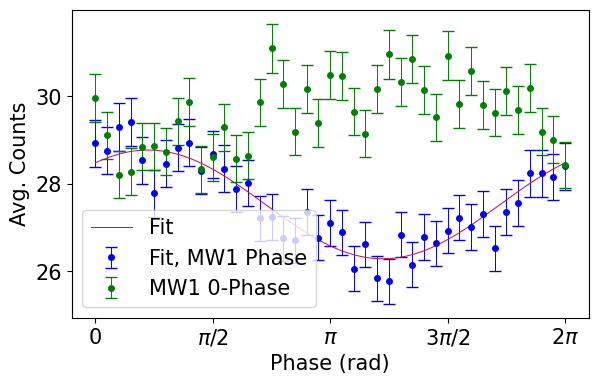

In [32]:
# Data on 18-July-2025 
# folder_name = 'Interference_MW1_ON_MW2_ON_Phase_5'
# folder_name = 'Interference_MW1_ON_Phase_MW2_ON_4'

'''Plotting the Early counts with MW ON - Phase ON and OFF'''
# folder_name = 'Interference_MW1_ON_Phase_MW2_OFF_3'
phase = np.array([0.0, 157.0, 314.0, 471.0, 628.0, 785.0, 942.0, 1099.0, 1256.0, 1413.0, 1570.0, 1727.0, 1884.0, 2042.0, 2199.0, 2356.0, 2513.0, 2670.0, 2827.0, 2984.0, 3141.0, 3298.0, 3455.0, 3612.0, 3769.0, 3926.0, 4084.0, 4241.0, 4398.0, 4555.0, 4712.0, 4869.0, 5026.0, 5183.0, 5340.0, 5497.0, 5654.0, 5811.0, 5969.0, 6126.0, 6283.0])
phase = phase/1000  # Convert to radians

counts_MW1_ON_MW2_Phase_early = np.array([29.96, 29.11, 28.21, 28.28, 28.85, 28.86, 28.73, 29.43, 29.88, 28.33, 28.61, 29.29, 28.57, 28.64, 29.86, 31.1, 30.29, 29.19, 30.17, 29.39, 30.48, 30.47, 29.65, 29.15, 30.16, 30.96, 30.33, 30.85, 30.14, 29.52, 30.93, 29.82, 30.58, 29.8, 29.63, 30.12, 29.69, 30.18, 29.19, 29.01, 28.43])
std_MW1_ON_MW2_Phase_early = np.array([0.547, 0.54, 0.531, 0.532, 0.537, 0.537, 0.536, 0.542, 0.547, 0.532, 0.535, 0.541, 0.535, 0.535, 0.546, 0.558, 0.55, 0.54, 0.549, 0.542, 0.552, 0.552, 0.545, 0.54, 0.549, 0.556, 0.551, 0.555, 0.549, 0.543, 0.556, 0.546, 0.553, 0.546, 0.544, 0.549, 0.545, 0.549, 0.54, 0.539, 0.533])

counts_MW1_Phase_MW2_ON_early = np.array([28.93, 28.76, 29.3, 29.41, 28.54, 27.78, 28.46, 28.83, 28.94, 28.3, 28.68, 28.35, 27.89, 28.02, 27.21, 27.24, 26.76, 26.71, 27.36, 26.77, 27.11, 26.89, 26.06, 26.62, 25.84, 25.77, 26.84, 26.15, 26.79, 26.64, 26.93, 27.23, 27.02, 27.31, 26.53, 27.35, 27.57, 28.24, 28.24, 28.16, 28.4])
std_MW1_Phase_MW2_ON_early = np.array([0.538, 0.536, 0.541, 0.542, 0.534, 0.527, 0.533, 0.537, 0.538, 0.532, 0.536, 0.532, 0.528, 0.529, 0.522, 0.522, 0.517, 0.517, 0.523, 0.517, 0.521, 0.519, 0.51, 0.516, 0.508, 0.508, 0.518, 0.511, 0.518, 0.516, 0.519, 0.522, 0.52, 0.523, 0.515, 0.523, 0.525, 0.531, 0.531, 0.531, 0.533])

# Define visibility function without offset C
# def visibility_func(x, A, V, k, phi):
#     return A * (1 + V * np.cos(k*x + phi))
def visibility_func(x, A, V, phi):
    return A * (1 + V * np.cos(x + phi))

# Perform the fit for MW1 Phase MW2 ON early counts
popt_early, pcov_early = curve_fit(visibility_func, phase, 
                                 counts_MW1_Phase_MW2_ON_early,
                                 p0=[28, 0.1, 0],
                                 sigma=std_MW1_Phase_MW2_ON_early)
perr_early = np.sqrt(np.diag(pcov_early))

# Generate smooth curve for plotting
phase_smooth = np.linspace(0, 2*np.pi, 200)
y_fit_early = visibility_func(phase_smooth, *popt_early)

# Create plot
plt.figure(figsize=(20/3, 4))

# Plot data and fit for MW1 Phase MW2 ON
plt.errorbar(phase, counts_MW1_Phase_MW2_ON_early, 
            yerr=std_MW1_Phase_MW2_ON_early,
            fmt='o', color='blue', markersize=4, 
            capsize=4, elinewidth=0.7, label='Fit, MW1 Phase')
plt.plot(phase_smooth, y_fit_early, '-', color='#d60057', 
         linewidth=0.7, label='Fit')

# Plot data points for other configuration
plt.errorbar(phase, counts_MW1_ON_MW2_Phase_early, 
            yerr=std_MW1_ON_MW2_Phase_early,
            fmt='o', color='green', markersize=4, 
            capsize=4, elinewidth=0.7, label='MW1 0-Phase')

plt.xlabel('Phase (rad)')
plt.ylabel('Avg. Counts')
# plt.title('Visibility Pattern')
plt.legend(loc='lower left')
plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi], 
           ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])

# Add visibility
visibility = popt_early[1]
visibility_err = perr_early[1]
# plt.text(3, 30, f'Visibility = {100*visibility:.1f}%')

# plt.savefig('Plots/Visibility_both_MW_ON_early.pdf')
plt.show()

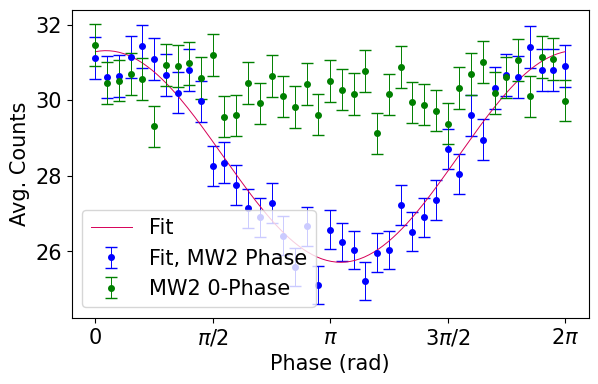

In [33]:
# Data on 18-July-2025 
# folder_name = 'Interference_MW1_ON_MW2_ON_Phase_5'
# folder_name = 'Interference_MW1_ON_Phase_MW2_ON_4'

'''Plotting the Late counts with MW ON - Phase ON and OFF'''
# folder_name = 'Interference_MW1_ON_Phase_MW2_OFF_3'
phase = np.array([0.0, 157.0, 314.0, 471.0, 628.0, 785.0, 942.0, 1099.0, 1256.0, 1413.0, 1570.0, 1727.0, 1884.0, 2042.0, 2199.0, 2356.0, 2513.0, 2670.0, 2827.0, 2984.0, 3141.0, 3298.0, 3455.0, 3612.0, 3769.0, 3926.0, 4084.0, 4241.0, 4398.0, 4555.0, 4712.0, 4869.0, 5026.0, 5183.0, 5340.0, 5497.0, 5654.0, 5811.0, 5969.0, 6126.0, 6283.0])
phase = phase/1000  # Convert to radians

counts_MW1_ON_MW2_Phase_late = np.array([31.12, 30.62, 30.65, 31.14, 31.42, 31.08, 30.67, 30.2, 30.8, 29.97, 28.26, 28.35, 27.75, 27.14, 26.9, 27.28, 26.42, 25.59, 26.67, 25.12, 26.57, 26.25, 26.04, 25.22, 25.97, 26.04, 27.23, 26.52, 26.9, 27.36, 28.71, 28.06, 29.6, 28.96, 30.32, 30.67, 30.62, 31.41, 30.8, 30.8, 30.9])
std_MW1_ON_MW2_Phase_late = np.array([0.558, 0.553, 0.554, 0.558, 0.561, 0.557, 0.554, 0.55, 0.555, 0.547, 0.532, 0.532, 0.527, 0.521, 0.519, 0.522, 0.514, 0.506, 0.516, 0.501, 0.515, 0.512, 0.51, 0.502, 0.51, 0.51, 0.522, 0.515, 0.519, 0.523, 0.536, 0.53, 0.544, 0.538, 0.551, 0.554, 0.553, 0.56, 0.555, 0.555, 0.556])

counts_MW1_Phase_MW2_ON_late = np.array([31.46, 30.45, 30.52, 30.7, 30.55, 29.31, 30.94, 30.91, 30.97, 30.59, 31.2, 29.56, 29.6, 30.45, 29.92, 30.64, 30.1, 29.82, 30.43, 29.62, 30.5, 30.28, 30.16, 30.77, 29.13, 30.15, 30.88, 29.94, 29.88, 29.72, 29.38, 30.33, 30.68, 31.02, 30.19, 30.6, 31.06, 30.1, 31.15, 31.08, 29.99])
std_MW1_Phase_MW2_ON_late = np.array([0.561, 0.552, 0.552, 0.554, 0.553, 0.541, 0.556, 0.556, 0.557, 0.553, 0.559, 0.544, 0.544, 0.552, 0.547, 0.554, 0.549, 0.546, 0.552, 0.544, 0.552, 0.55, 0.549, 0.555, 0.54, 0.549, 0.556, 0.547, 0.547, 0.545, 0.542, 0.551, 0.554, 0.557, 0.549, 0.553, 0.557, 0.549, 0.558, 0.557, 0.548])

# Define visibility function
def visibility_func(x, A, V, phi):
    return A * (1 + V * np.cos(x + phi))

# Perform the fit for late counts
popt_late, pcov_late = curve_fit(visibility_func, phase, 
                                counts_MW1_ON_MW2_Phase_late,
                                p0=[30, 0.1, 0],
                                sigma=std_MW1_ON_MW2_Phase_late)
perr_late = np.sqrt(np.diag(pcov_late))

# Generate smooth curve for plotting
phase_smooth = np.linspace(0, 2*np.pi, 200)
y_fit_late = visibility_func(phase_smooth, *popt_late)

# Create plot
plt.figure(figsize=(20/3, 4))

# Plot data and fit for first dataset
plt.errorbar(phase, counts_MW1_ON_MW2_Phase_late, 
            yerr=std_MW1_ON_MW2_Phase_late,
            fmt='o', color='blue', markersize=4, 
            capsize=4, elinewidth=0.7, label='Fit, MW2 Phase')
plt.plot(phase_smooth, y_fit_late, '-', color='#d60057', 
         linewidth=0.7, label='Fit')

# Plot second dataset for comparison
plt.errorbar(phase, counts_MW1_Phase_MW2_ON_late, 
            yerr=std_MW1_Phase_MW2_ON_late,
            fmt='o', color='green', markersize=4, 
            capsize=4, elinewidth=0.7, label='MW2 0-Phase')

plt.xlabel('Phase (rad)')
plt.ylabel('Avg. Counts')
# plt.title('Visibility Pattern')
plt.legend()
plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi], 
           ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])

# Add visibility 
visibility = popt_late[1]
visibility_err = perr_late[1]
# plt.text(3, 30, f'Visibility = {100*visibility:.1f}%')

# plt.savefig('Plots/Visibility_both_MW_ON_late.pdf')
plt.show()


### Both MW Phases differed by pi/2

Early fit parameters:
I1 = 1.5776 ± 1.46e-01
I2 = 0.4362 ± 9.24e-02
phi = -0.3771 ± 7.34e-02
R^2 value (early): 0.8338

Late fit parameters:
I1 = 2.4432 ± 1.48e-01
I2 = 0.6525 ± 9.41e-02
phi = 1.2973 ± 4.96e-02
R^2 value (late): 0.9118


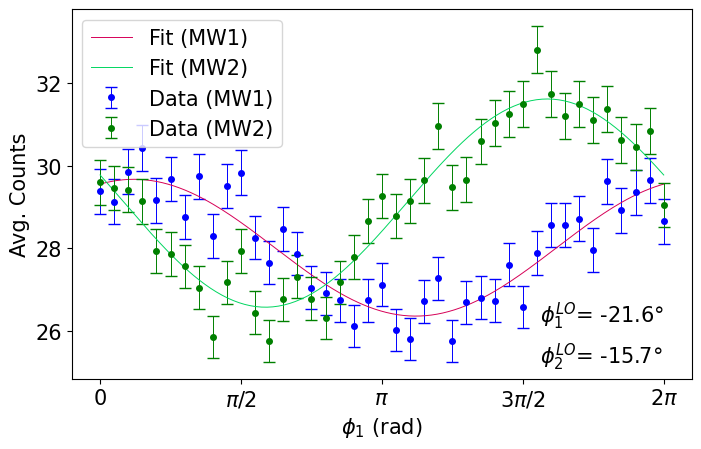

In [36]:
# Data on 18-July-2025 
# folder_name = 'Interference_MW1_MW2_Phases_7'

'''Plotting both counts with MW ON - Phase ON'''
# folder_name = 'Interference_MW1_ON_Phase_MW2_OFF_3'
phase = np.array([0.0, 157.0, 314.0, 471.0, 628.0, 785.0, 942.0, 1099.0, 1256.0, 1413.0, 1570.0, 1727.0, 1884.0, 2042.0, 2199.0, 2356.0, 2513.0, 2670.0, 2827.0, 2984.0, 3141.0, 3298.0, 3455.0, 3612.0, 3769.0, 3926.0, 4084.0, 4241.0, 4398.0, 4555.0, 4712.0, 4869.0, 5026.0, 5183.0, 5340.0, 5497.0, 5654.0, 5811.0, 5969.0, 6126.0, 6283.0])
phase = phase/1000  # Convert to radians

counts_early = np.array([29.38, 29.13, 29.85, 30.43, 29.16, 29.68, 28.76, 29.75, 28.3, 29.51, 29.83, 28.26, 27.65, 28.46, 27.87, 27.04, 26.91, 26.74, 26.11, 26.74, 27.11, 26.02, 25.79, 26.71, 27.27, 25.75, 26.69, 26.8, 26.73, 27.6, 26.58, 27.89, 28.56, 28.57, 28.72, 27.96, 29.62, 28.92, 29.36, 29.65, 28.65])
std_early = np.array([0.542, 0.54, 0.546, 0.552, 0.54, 0.545, 0.536, 0.545, 0.532, 0.543, 0.546, 0.532, 0.526, 0.533, 0.528, 0.52, 0.519, 0.517, 0.511, 0.517, 0.521, 0.51, 0.508, 0.517, 0.522, 0.507, 0.517, 0.518, 0.517, 0.525, 0.516, 0.528, 0.534, 0.535, 0.536, 0.529, 0.544, 0.538, 0.542, 0.545, 0.535])

counts_late = np.array([29.6, 29.46, 29.42, 29.14, 27.94, 27.86, 27.56, 27.04, 25.84, 27.17, 27.93, 26.44, 25.75, 26.76, 27.31, 26.78, 26.3, 27.17, 27.79, 28.67, 29.27, 28.79, 29.15, 29.65, 30.97, 29.48, 29.66, 30.59, 31.03, 31.25, 31.5, 32.82, 31.74, 31.21, 31.5, 31.12, 31.38, 30.63, 30.46, 30.85, 29.05])
std_late = np.array([0.544, 0.543, 0.542, 0.54, 0.529, 0.528, 0.525, 0.52, 0.508, 0.521, 0.528, 0.514, 0.507, 0.517, 0.523, 0.517, 0.513, 0.521, 0.527, 0.535, 0.541, 0.537, 0.54, 0.545, 0.557, 0.543, 0.545, 0.553, 0.557, 0.559, 0.561, 0.573, 0.563, 0.559, 0.561, 0.558, 0.56, 0.553, 0.552, 0.555, 0.539])

# Define visibility function without offset C
def visibility_func_early(x, I1, I2, phi, C=26):
    return  (I1+I2 + 2*np.sqrt(I1*I2) * np.cos(x + phi))+C

# Set bounds for the fit parameters: [I1, I2, phi, C]
bounds = ([0.1, 0.1, -2*np.pi], [10, 10, 2*np.pi])

# Perform the fit for early and late counts with bounds
popt_early, pcov_early = curve_fit(
    visibility_func_early, phase, counts_early,
    p0=[1, 0.1, 0],
    sigma=std_early,
    bounds=bounds
)
perr_early = np.sqrt(np.diag(pcov_early))

# Define visibility function without offset C
def visibility_func_late(x, I1, I2, phi, C=26):
    return  (I1+I2 + 2*np.sqrt(I1*I2) * np.cos(x + phi))+C

popt_late, pcov_late = curve_fit(
    visibility_func_late, phase, counts_late,
    p0=[1, 0.1, 0],
    sigma=std_late,
    bounds=bounds
)
perr_late = np.sqrt(np.diag(pcov_late))
# Print fit parameters and R^2 values for early and late fits
param_names = ['I1', 'I2', 'phi', 'C']
print("Early fit parameters:")
for name, val, err in zip(param_names, popt_early, perr_early):
    print(f"{name} = {val:.4f} ± {err:.2e}")
residuals_early = counts_early - visibility_func_early(phase, *popt_early)
ss_res_early = np.sum(residuals_early**2)
ss_tot_early = np.sum((counts_early - np.mean(counts_early))**2)
r2_early = 1 - (ss_res_early / ss_tot_early)
print(f"R^2 value (early): {r2_early:.4f}\n")

print("Late fit parameters:")
for name, val, err in zip(param_names, popt_late, perr_late):
    print(f"{name} = {val:.4f} ± {err:.2e}")
residuals_late = counts_late - visibility_func_late(phase, *popt_late)
ss_res_late = np.sum(residuals_late**2)
ss_tot_late = np.sum((counts_late - np.mean(counts_late))**2)
r2_late = 1 - (ss_res_late / ss_tot_late)
print(f"R^2 value (late): {r2_late:.4f}")

# Generate smooth curve for plotting
phase_smooth = np.linspace(0, 2*np.pi, 200)
y_fit_early = visibility_func_early(phase_smooth, *popt_early)
y_fit_late = visibility_func_late(phase_smooth, *popt_late)

# Create plot
plt.figure(figsize=(20/3*1.2, 4*1.2))

# Plot data and fits
plt.errorbar(phase, counts_early, yerr=std_early,
            fmt='o', color='blue', markersize=4, 
            capsize=4, elinewidth=0.7, label='Data (MW1)')
plt.plot(phase_smooth, y_fit_early, '-', color='#d60057', 
         linewidth=0.7, label='Fit (MW1)')

plt.errorbar(phase, counts_late, yerr=std_late,
            fmt='o', color='green', markersize=4, 
            capsize=4, elinewidth=0.7, label='Data (MW2)')
plt.plot(phase_smooth, y_fit_late, '-', color='#00d660',
         linewidth=0.7, label='Fit (MW2)')

plt.xlabel(r'$\phi_1$ (rad)')
plt.ylabel('Avg. Counts')
# plt.title('Visibility Pattern')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.legend()
plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi], 
           ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])

# Add visibility and phase offset information
visibility_early = popt_early[1]
phase_offset_early = popt_early[2]
visibility_late = popt_late[1]
# popt = [A, V, k, phi, C] so phi = popt[3]
phase_offset_late = popt_late[2]

# plt.text(2.5, 33, f'MW1: V = {100*visibility_early:.1f}%,' r'$\phi_1$' f'= {phase_offset_early*180/np.pi:.1f}°')
# plt.text(2.5, 32.4, f'MW2: V = {100*visibility_late:.1f}%,' r'$\phi_2$' f'= {phase_offset_late*180/np.pi:.1f}°')

plt.text(4.9, 26.2, r'$\phi_1^{LO}$' f'= {phase_offset_early*180/np.pi:.1f}°')
plt.text(4.9, 25.2, r'$\phi_2^{LO}$' f'= {phase_offset_late*180/np.pi-90:.1f}°')

# plt.savefig('Plots/Visibility_MW_phases_pi_half.pdf')
plt.show()


## Lineshapes Plotting

Area ratio (sinc/square) = 0.589


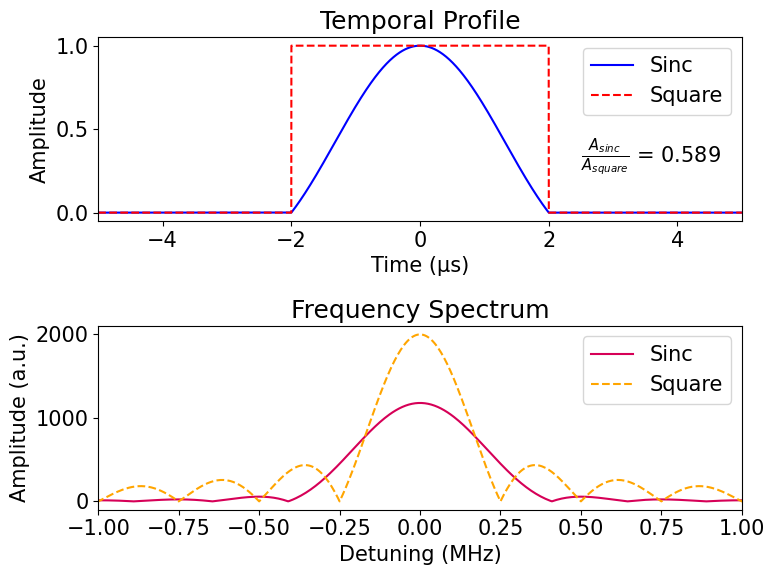

In [2]:
# Create time array with high resolution
t = np.linspace(-100, 100, 100000)  # time in microseconds
dt = t[1] - t[0]  # time step

# Parameters
tau = 4.0  # pulse width in microseconds
f_MW = 2623.35  # MHz
amplitude = 1 #4*0.05  # amplitude
# Create zero array and fill only 0-2us region
MW_pulse = np.zeros_like(t)
MW_pulse_sq = np.zeros_like(t)  # square pulse for comparison
mask = (t >= -2) & (t <= 2)
MW_pulse[mask] = amplitude * np.sinc((t[mask]-0.0*tau)*2/tau) #* np.sin(2*np.pi*f_MW*t[mask])
# Create the MW pulse
MW_pulse_sq[mask] = amplitude * 1

# Calculate FFT
freq = np.fft.fftfreq(len(t), dt)  # frequency axis
freq = np.fft.fftshift(freq)  # shift zero frequency to center
spectrum = np.fft.fft(MW_pulse)
spectrum = np.fft.fftshift(spectrum)  # shift zero frequency to center

# Calculate FFT of square pulse
spectrum_sq = np.fft.fft(MW_pulse_sq)
spectrum_sq = np.fft.fftshift(spectrum_sq)  # shift zero frequency to center
# Calculate areas using numerical integration
dt = t[1] - t[0]  # time step
sinc_area = np.sum(np.abs(MW_pulse)) * dt
square_area = np.sum(np.abs(MW_pulse_sq)) * dt

# Print the ratio
print(f'Area ratio (sinc/square) = {sinc_area/square_area:.3f}')

# Plot results
plt.figure(figsize=(8, 6))

# Time domain plot
plt.subplot(211)
plt.plot(t, MW_pulse, 'b-', label='Sinc')
plt.plot(t, MW_pulse_sq, 'r--', label='Square')
plt.xlabel('Time (µs)')
plt.ylabel('Amplitude')
plt.xlim(-5, 5)  # limit x-axis to ±2 µs
plt.title('Temporal Profile')
# plt.grid(True, alpha=0.3)
plt.text(2.5, 0.3,r'$\frac{A_{sinc}}{A_{square}}$'+ f' = {sinc_area/square_area:.3f}', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
plt.legend()

# Frequency domain plot
plt.subplot(212)
# plt.plot(freq, np.abs(spectrum)/np.max(np.abs(spectrum)), '-', color='#d60057', label='Spectrum')
plt.plot(freq, np.abs(spectrum), '-', color='#d60057', label='Sinc')
# plt.plot(freq, np.abs(spectrum_sq)/np.max(np.abs(spectrum_sq)), '--', color='orange', label='Square Pulse Spectrum')
plt.plot(freq, np.abs(spectrum_sq), '--', color='orange', label='Square')
plt.xlabel('Detuning (MHz)')
plt.ylabel('Amplitude (a.u.)')
plt.title('Frequency Spectrum')
plt.xlim(-1, 1)  # limit x-axis to ±2 MHz
# plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
# plt.savefig('Plots/Pump_Pulse_Spectrum.pdf')
plt.show()


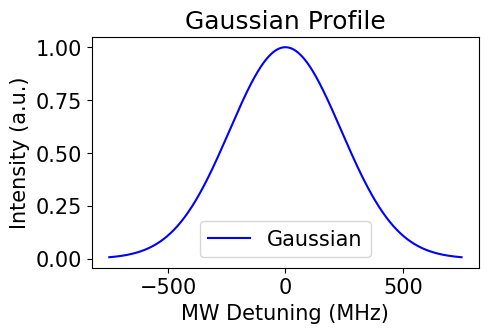

In [3]:
# Create a Gaussian plot
def gaussian(x, mu, sigma):
    return np.exp(-(x - mu)**2 / (2 * sigma**2))

# Generate x values for a smooth curve
x = np.linspace(-750, 750, 1000)

# Convert FWHM to sigma
# FWHM = 2.355 * sigma
sigma = 560 / 2.355

# Calculate Gaussian values
y = gaussian(x, 0, sigma)

# Create the plot
plt.figure(figsize=(5, 3))
plt.plot(x, y, '-', color='blue', label='Gaussian')
plt.xlabel('MW Detuning (MHz)')
plt.ylabel('Intensity (a.u.)')
plt.title('Gaussian Profile')
plt.legend()
# plt.savefig('Plots/Gaussian_Profile.pdf')
plt.show()

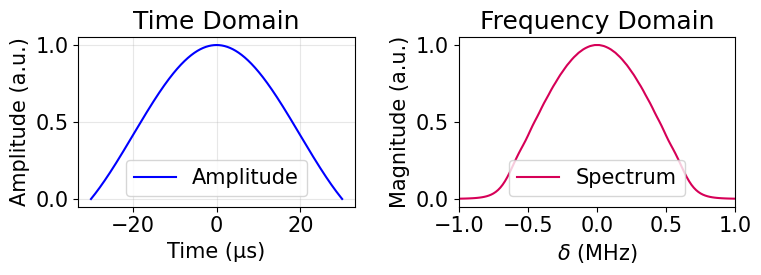

In [4]:
# Create the RAP pulse profile and its Fourier spectrum
dt = 0.01  # time step in microseconds
t = np.arange(-30, 30, dt)  # time array centered at 0, total duration 60us

# Parameters
chirp_range = 1.5  # MHz
duration = 60  # us
center_freq = 0  # MHz
scale = 2  # scale factor for sinc function

# Create the time domain signal
amplitude = np.sinc(2*t/duration)  # amplitude profile is a sinc function
phase = 2*np.pi * (chirp_range/(2*duration)) * t**2  # quadratic phase for linear chirp
signal = amplitude * np.exp(1j * phase)

# Calculate the Fourier spectrum
freq = np.fft.fftshift(np.fft.fftfreq(len(t), dt))  # frequency axis in MHz
spectrum = np.abs(np.fft.fftshift(np.fft.fft(signal))) / len(t)

# Plot the results
plt.figure(figsize=(8, 3))

# Time domain plot
plt.subplot(121)
plt.plot(t, amplitude, 'b-', label='Amplitude')
plt.xlabel('Time (µs)')
plt.ylabel('Amplitude (a.u.)')
plt.title('Time Domain')
plt.grid(True, alpha=0.3)
plt.legend()

# # Frequency domain plot
# plt.subplot(122)
# plt.plot(freq, spectrum, 'r-', label='Spectrum')
# plt.xlabel('Frequency (MHz)')
# plt.ylabel('Magnitude (a.u.)')
# plt.title('Frequency Domain')
# plt.grid(True, alpha=0.3)
# plt.legend()
# Modify the frequency axis to be centered around 0
freq_centered = freq - center_freq
plt.subplot(122)
plt.plot(freq_centered, spectrum/max(spectrum), '-', color='#d60057', label='Spectrum')
plt.xlim(-1, 1)  # Set x-axis limits to ±2 MHz
plt.xlabel(r'$\delta$ (MHz)')
plt.ylabel('Magnitude (a.u.)')
plt.title('Frequency Domain')
# plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
# plt.savefig('Plots/RAP_Spectrum.pdf')
plt.show()

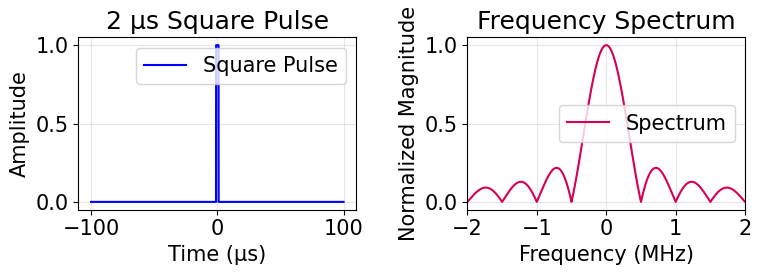

In [5]:
# Create time array with high resolution
t = np.linspace(-100, 100, 100000)  # time in microseconds
dt = t[1] - t[0]  # time step

# Create square pulse (2µs width)
pulse = np.zeros_like(t)
pulse[np.abs(t) <= 1] = 1  # 2µs width centered at t=0

# Calculate FFT
freq = np.fft.fftfreq(len(t), dt)  # frequency axis
freq = np.fft.fftshift(freq)  # shift zero frequency to center
spectrum = np.fft.fft(pulse)
spectrum = np.fft.fftshift(spectrum)  # shift zero frequency to center

# Plot results
plt.figure(figsize=(8, 3))

# Time domain plot
plt.subplot(121)
plt.plot(t, pulse, 'b-', label='Square Pulse')
plt.xlabel('Time (µs)')
plt.ylabel('Amplitude')
plt.title('2 µs Square Pulse')
plt.grid(True, alpha=0.3)
plt.legend()

# Frequency domain plot
plt.subplot(122)
plt.plot(freq, np.abs(spectrum)/np.max(np.abs(spectrum)), '-', color='#d60057', label='Spectrum')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Normalized Magnitude')
plt.title('Frequency Spectrum')
plt.xlim(-2, 2)  # limit x-axis to ±2 MHz
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
# plt.savefig('Plots/Square_Pulse_Spectrum.pdf')
plt.show()

## Temporal Multimode

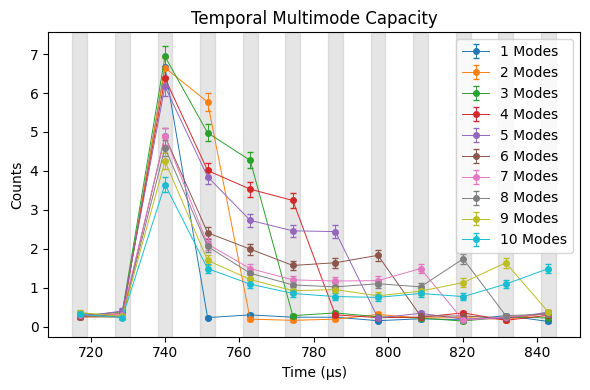

In [10]:
# Data on 10-May-2025 --- verify
window_counts, window_errors = {}, {}
window_duration = 4  # 4μs duration

window_starts = [715.1, 726.5500000000001, 738.0, 749.45, 760.9, 772.35, 783.8, 795.25, 806.7, 818.15, 829.6, 841.05]

window_counts[1] =   [0.32, 0.26, 6.66, 0.23, 0.3, 0.24, 0.24, 0.15, 0.2, 0.17, 0.28, 0.13]
window_errors[1] =   [0.057, 0.051, 0.259, 0.048, 0.055, 0.049, 0.049, 0.039, 0.045, 0.041, 0.053, 0.036]
window_counts[2] =   [0.25, 0.25, 6.65, 5.77, 0.19, 0.16, 0.19, 0.31, 0.22, 0.23, 0.18, 0.34]
window_errors[2] =   [0.05, 0.05, 0.259, 0.241, 0.044, 0.04, 0.044, 0.056, 0.047, 0.048, 0.043, 0.059]
window_counts[3] =   [0.27, 0.38, 6.94, 4.98, 4.27, 0.28, 0.35, 0.25, 0.22, 0.14, 0.25, 0.22]
window_errors[3] =  [0.052, 0.062, 0.265, 0.224, 0.208, 0.053, 0.059, 0.05, 0.047, 0.038, 0.05, 0.047]
window_counts[4] =   [0.29, 0.33, 6.38, 4.01, 3.53, 3.24, 0.3, 0.23, 0.24, 0.35, 0.16, 0.29]
window_errors[4] =  [0.054, 0.058, 0.254, 0.201, 0.189, 0.181, 0.055, 0.048, 0.049, 0.059, 0.04, 0.054]
window_counts[5] =   [0.25, 0.4, 6.17, 3.85, 2.73, 2.46, 2.44, 0.22, 0.34, 0.19, 0.21, 0.37]
window_errors[5] =  [0.05, 0.064, 0.25, 0.197, 0.166, 0.158, 0.157, 0.047, 0.059, 0.044, 0.046, 0.061]
window_counts[6] =   [0.25, 0.25, 4.89, 2.41, 1.99, 1.57, 1.64, 1.83, 0.27, 0.27, 0.22, 0.34]
window_errors[6] =  [0.05, 0.05, 0.222, 0.156, 0.142, 0.126, 0.129, 0.136, 0.052, 0.052, 0.047, 0.059]
window_counts[7] =   [0.3, 0.3, 4.89, 2.12, 1.49, 1.2, 1.17, 1.18, 1.49, 0.16, 0.25, 0.32]
window_errors[7] =  [0.055, 0.055, 0.222, 0.146, 0.123, 0.11, 0.109, 0.109, 0.123, 0.04, 0.05, 0.057]
window_counts[8] =  [0.35, 0.25, 4.59, 2.06, 1.37, 1.07, 1.02, 1.1, 1.02, 1.74, 0.28, 0.32]
window_errors[8] =  [0.059, 0.05, 0.215, 0.144, 0.118, 0.104, 0.102, 0.105, 0.102, 0.133, 0.053, 0.057]
window_counts[9] =   [0.36, 0.26, 4.25, 1.7, 1.21, 0.92, 0.95, 0.79, 0.91, 1.13, 1.64, 0.37]
window_errors[9] =  [0.06, 0.051, 0.207, 0.131, 0.111, 0.096, 0.098, 0.089, 0.096, 0.107, 0.129, 0.061]
window_counts[10] =  [0.31, 0.23, 3.65, 1.49, 1.09, 0.85, 0.77, 0.75, 0.85, 0.77, 1.09, 1.49]
window_errors[10] =  [0.056, 0.048, 0.192, 0.123, 0.105, 0.093, 0.088, 0.087, 0.093, 0.088, 0.105, 0.123]

# Create the plot
cmap = colormaps['tab10']
colors = [cmap(i / len(window_counts)) for i in range(len(window_counts))]

plt.figure(figsize=(6, 4))
for idx, i in enumerate(window_counts.keys()):
    plt.errorbar(window_starts+2*np.ones(len(window_starts)), window_counts[i], yerr=window_errors[i], fmt='o-', 
              alpha = 1, capsize=2, markersize=4, linewidth=0.7, color = colors[idx], label=str(i)+' Modes')
# Add vertical spans to show windows
for start in window_starts:
    plt.axvspan(start, start + window_duration, alpha=0.2, color='gray')

# Adjust plot appearance
plt.xlabel('Time (μs)')
plt.ylabel('Counts')
plt.legend()
plt.rcParams['font.size'] = 10
ax = plt.gca()
ax.title.set_fontsize(10)
ax.xaxis.label.set_fontsize(10)
ax.yaxis.label.set_fontsize(10)
ax.tick_params(axis='both', labelsize=10)
plt.title('Temporal Multimode Capacity')
plt.tight_layout()
# plt.savefig('Plots/Temporal_multimode_sinc.pdf')
plt.show()


## Spectral Multimode within RAP

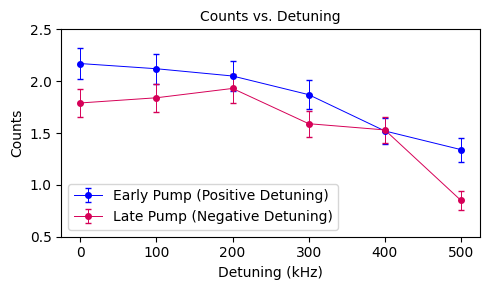

In [8]:
# Data on 10-May-2025 folder_name = 'Pump_frequency_within_RAP_6_Pump_Sinc_shaped'
detuning = np.array([0.0, 100.0, 200.0, 300.0, 400.0, 500.0])
early_counts_pos_det = np.array([2.17, 2.12, 2.05, 1.87, 1.52, 1.34])
early_errors = np.array([0.147, 0.146, 0.143, 0.137, 0.123, 0.116])
late_counts_neg_det = np.array([1.79, 1.84, 1.93, 1.59, 1.53, 0.85])
late_errors = np.array([0.134, 0.136, 0.139, 0.126, 0.124, 0.092])
# Create the plot
plt.figure(figsize=(5, 3))
plt.errorbar(detuning, early_counts_pos_det, yerr=early_errors, fmt='o-', label='Early Pump (Positive Detuning)', 
             capsize=2, markersize=4, elinewidth=0.7, linewidth=0.7, color='blue')
plt.errorbar(detuning, late_counts_neg_det, yerr=late_errors, fmt='o-', label='Late Pump (Negative Detuning)', 
             capsize=2, markersize=4, elinewidth=0.7, linewidth=0.7, color='#d60057')
plt.xlabel('Detuning (kHz)')
plt.ylabel('Counts')
plt.title('Counts vs. Detuning')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
ax = plt.gca()
ax.title.set_fontsize(10)
ax.xaxis.label.set_fontsize(10)
ax.yaxis.label.set_fontsize(10)
ax.tick_params(axis='both', labelsize=10)
plt.legend()
plt.yticks(np.arange(0.5, 3, 0.5))
# plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('Plots/Within_RAP_Detuning.pdf')
plt.show()

## Spectral Multimode within Spin Broadening

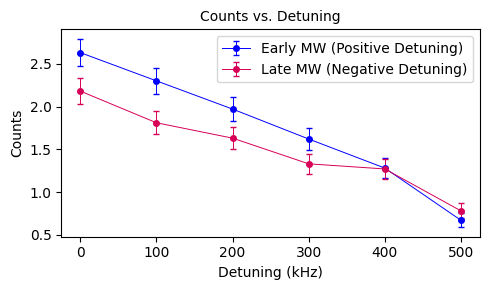

In [9]:
# Data on 10-May-2025 folder_name = 'OM0_5us_OM1_sinc_shaped_10MW'
detuning = np.array([0.0, 100.0, 200.0, 300.0, 400.0, 500.0])
early_counts_pos_det = np.array([2.63, 2.3, 1.97, 1.62, 1.28, 0.67])
early_errors = np.array([0.162, 0.152, 0.14, 0.127, 0.113, 0.082])
late_counts_neg_det = np.array([2.18, 1.81, 1.63, 1.33, 1.27, 0.78])
late_errors = np.array([0.148, 0.135, 0.128, 0.115, 0.113, 0.088])
# Create the plot
plt.figure(figsize=(5, 3))
plt.errorbar(detuning, early_counts_pos_det, yerr=early_errors, fmt='o-', label='Early MW (Positive Detuning)', 
             capsize=2, markersize=4, elinewidth=0.7, linewidth=0.7, color='blue')
plt.errorbar(detuning, late_counts_neg_det, yerr=late_errors, fmt='o-', label='Late MW (Negative Detuning)', 
             capsize=2, markersize=4, elinewidth=0.7, linewidth=0.7, color='#d60057')
plt.xlabel('Detuning (kHz)')
plt.ylabel('Counts')
plt.title('Counts vs. Detuning')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
ax = plt.gca()
ax.title.set_fontsize(10)
ax.xaxis.label.set_fontsize(10)
ax.yaxis.label.set_fontsize(10)
ax.tick_params(axis='both', labelsize=10)
plt.legend()
plt.yticks(np.arange(0.5, 3, 0.5))
# plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('Plots/Within_Spin_broadening.pdf')
plt.show()

## AWG Amplitude vs Power

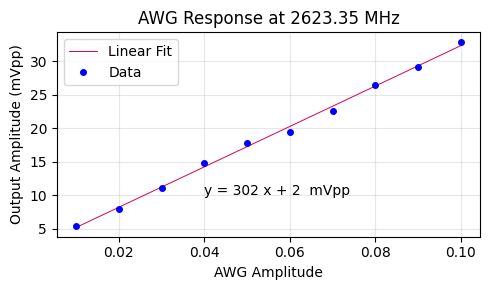

In [11]:
# Data on ------
# Amplitude = np.array([1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0.02])
# mVpp_mean = np.array([337.15, 305.21, 273.4, 239.58, 206.22, 174.13, 143.73, 112.06, 78.58, 46.17, 22.95])

Amplitude = np.array([0.1, 0.09, 0.08, 0.07, 0.06, 0.05, 0.04, 0.03, 0.02, 0.01])
mVpp_mean = np.array([32.955, 29.2, 26.4, 22.6, 19.518, 17.74, 14.798, 11.123, 7.996, 5.404])
AWG_mVpp_dict = {float(amp): float(mVpp) for amp, mVpp in zip(Amplitude, mVpp_mean)}
def linear(x, m, b):
    return m*x + b

# Perform the linear fit
popt, pcov = curve_fit(linear, Amplitude, mVpp_mean)
perr = np.sqrt(np.diag(pcov))

# Generate points for smooth fit line 
x_fit = np.linspace(min(Amplitude), max(Amplitude), 100)
y_fit = linear(x_fit, *popt)


plt.figure(figsize=(5, 3))
# Add the fit to the plot before plt.show()
plt.plot(x_fit, y_fit, '-', color='#d60057', linewidth=0.7, label='Linear Fit')
# plt.text(0.2, 300, f'Slope = {popt[0]:.0f} mVpp/Volt')
plt.text(0.04, 10, f'y = {popt[0]:.0f} x + {popt[1]:.0f}  mVpp')

plt.plot(Amplitude, mVpp_mean, 'o', color='blue', 
         markersize=4, linewidth=0.7, label='Data')
plt.xlabel('AWG Amplitude')
plt.ylabel('Output Amplitude (mVpp)')
plt.title('AWG Response at 2623.35 MHz')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
# plt.savefig('Plots/AWG_Response.pdf')
plt.show()

In [12]:
# Convert mVpp to Vrms (in volts)
Vrms = mVpp_mean / (2 * np.sqrt(2)) / 1000  # Convert mV to V and peak-to-peak to RMS

# Calculate power in watts
power_watts = Vrms**2 / 50

# Convert to dBm
power_dBm = 10 * np.log10(power_watts * 1000)

# Create DataFrame with results
results = pd.DataFrame({
    'Amplitude': Amplitude,
    'mVpp': mVpp_mean,
    'Vrms (V)': Vrms,
    'Power (W)': power_watts,
    'Power (dBm)': power_dBm
})

print(results)

   Amplitude    mVpp  Vrms (V)     Power (W)  Power (dBm)
0       0.10  32.955  0.011651  2.715080e-06   -25.662174
1       0.09  29.200  0.010324  2.131600e-06   -26.712943
2       0.08  26.400  0.009334  1.742400e-06   -27.588521
3       0.07  22.600  0.007990  1.276900e-06   -28.938431
4       0.06  19.518  0.006901  9.523808e-07   -30.211894
5       0.05  17.740  0.006272  7.867690e-07   -31.041528
6       0.04  14.798  0.005232  5.474520e-07   -32.616539
7       0.03  11.123  0.003933  3.093028e-07   -35.096161
8       0.02   7.996  0.002827  1.598400e-07   -37.963144
9       0.01   5.404  0.001911  7.300804e-08   -41.366293


In [13]:
dBm = -31.04 +2.5 -15.84
power_mW = 10**(dBm/10)
power_W = power_mW/1000

# Convert power to Vrms across 50Ω
Vrms = np.sqrt(power_W * 50)

# Convert Vrms to Vpp
Vpp = Vrms * 2 * np.sqrt(2)

# Convert to mVpp
mVpp = Vpp * 1000

print(f"For {dBm} dBm:")
print(f"Power = {power_mW:.3f} mW")
print(f"Vrms = {Vrms*1000:.3f} mV")
print(f"Vpp = {Vpp*1000:.3f} mVpp")

For -44.379999999999995 dBm:
Power = 0.000 mW
Vrms = 1.350 mV
Vpp = 3.820 mVpp


In [14]:
# Given parameters
duration = 2e-6  # 2 us in seconds
frequency = 2623.35e6  # Hz
power_dBm = -44.38  # dBm

# 1. Convert power from dBm to Watts
power_mW = 10**(power_dBm/10)  # Convert dBm to mW
power_W = power_mW/1000  # Convert mW to W
print(f"Power = {power_W:.2e} Watts")

# 2. Calculate energy per photon using E = hf
h = 6.626e-34  # Planck's constant
energy_per_photon = h * frequency
print(f"Energy per photon = {energy_per_photon:.2e} Joules")

# 3. Calculate total energy in pulse
energy_pulse = power_W * duration
print(f"Pulse energy = {energy_pulse:.2e} Joules")

# 4. Calculate number of photons
n_photons = energy_pulse / energy_per_photon *0.59
print(f"Number of photons = {n_photons:.2e}")

2/n_photons /0.1/0.4/0.12

Power = 3.65e-08 Watts
Energy per photon = 1.74e-24 Joules
Pulse energy = 7.30e-14 Joules
Number of photons = 2.48e+10


1.6827299297182358e-08

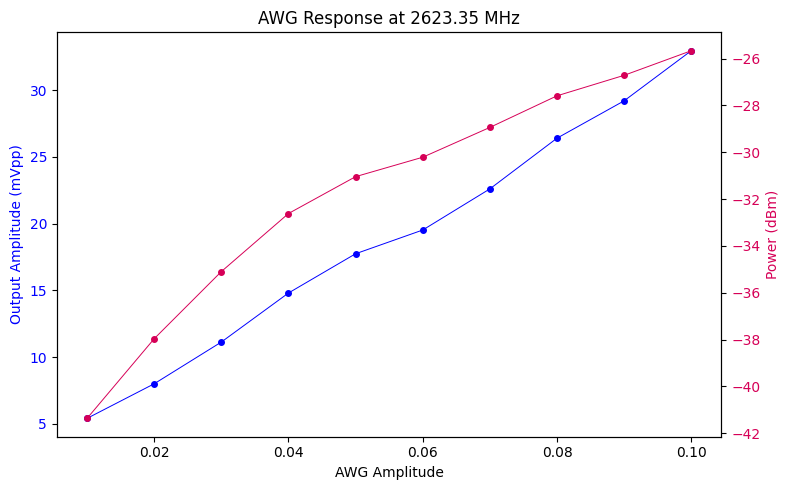

In [17]:
# Create figure with dual y-axes
fig, ax1 = plt.subplots(figsize=(8, 5))
# Create linear fit of mVpp data
def linear(x, m, b):
    return m*x + b

# Perform linear fit on mVpp data
popt_mVpp, pcov_mVpp = curve_fit(linear, results['Amplitude'], results['mVpp'])
perr_mVpp = np.sqrt(np.diag(pcov_mVpp))

# Add text box with fit parameters
# plt.text(0.6, 180, f'y = {popt_mVpp[0]:.0f} x + {popt_mVpp[1]:.0f}  mVpp')

# Plot mVpp data on left axis
ax1.plot(results['Amplitude'], results['mVpp'], 'o-', color='blue', 
         markersize=4, linewidth=0.7, label='Amplitude')
ax1.set_xlabel('AWG Amplitude')
ax1.set_ylabel('Output Amplitude (mVpp)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
# ax1.semilogy()  # Use logarithmic scale for mVpp
# Create second y-axis and plot power data
ax2 = ax1.twinx()
ax2.plot(results['Amplitude'], results['Power (dBm)'], 'o-', color='#d60057', 
         markersize=4, linewidth=0.7, label='Power')
ax2.set_ylabel('Power (dBm)', color='#d60057')
ax2.tick_params(axis='y', labelcolor='#d60057')
# ax2.set_ylim(-30, -5)  # Set limits for dBm axis
plt.title('AWG Response at 2623.35 MHz')
plt.tight_layout()
# plt.savefig('Plots/AWG_Response_dual.pdf')
plt.show()

## 4g-1e Absorption

In [18]:
# Step 2: Read the binary file, apply calibration, and plot the data
def read_waveform(folder, binary_file):
    binary_file = folder + '/' + binary_file + '.bin'
    # Load the binary data
    with open(binary_file, "rb") as f:
        raw_data = f.read()

    # Parse the header
    header_length = int(raw_data[6:7])  # Length of the length field ('9')
    payload_length = int(raw_data[7:7 + header_length])  # Length of binary data
    binary_data_start = 7 + header_length

    # Extract binary data
    binary_data = raw_data[binary_data_start : binary_data_start + payload_length]

    # Decode binary data to voltage values (assuming 16-bit integers)
    raw_voltage_values = np.frombuffer(binary_data, dtype=np.int8)

    # Load calibration settings
    calibration_settings = {}
    with open(folder + '/' +'Cal_file' + ".settings", "r") as f:
        for line in f:
            key, value = line.strip().split("=")
            calibration_settings[key] = float(value)

    # Calibration factors
    x_div = calibration_settings["x_div"]
    y_div = calibration_settings["y_div"]
    voltage_offset = calibration_settings["voltage_offset"]

    # Scale the raw data - 2.5/3 factor is empirical based on observation for 1 V/div scale
    # voltage_values = raw_voltage_values * y_div*8 / (2**8) *3/2.5 + voltage_offset*2.5/3 
    voltage_values = (raw_voltage_values) * y_div*8 / (2**8)  #*3/2.5 - voltage_offset*3/2.5

    # Generate the time axis
    num_samples = len(voltage_values)
    time_scale = x_div * 10  # 10 divisions on the screen
    sample_interval = time_scale / num_samples
    time_values = np.arange(num_samples) * sample_interval
    return [time_values, voltage_values]
    


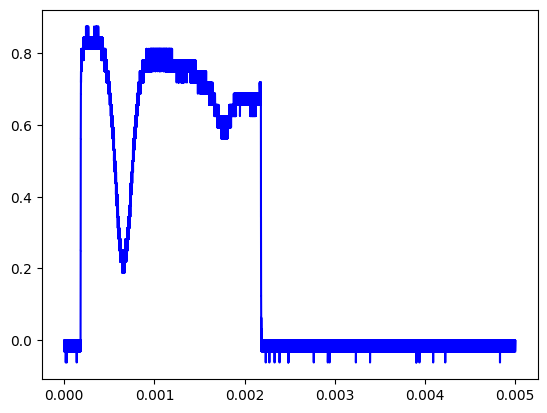

In [19]:
time = read_waveform('Absorption Data', '4g-1e-Spectrum-1000MHz_to_3620MHz')[0]
voltage = read_waveform('Absorption Data', '4g-1e-Spectrum-1000MHz_to_3620MHz')[1]
plt.plot(time, voltage, label="Waveform Data", color="blue")

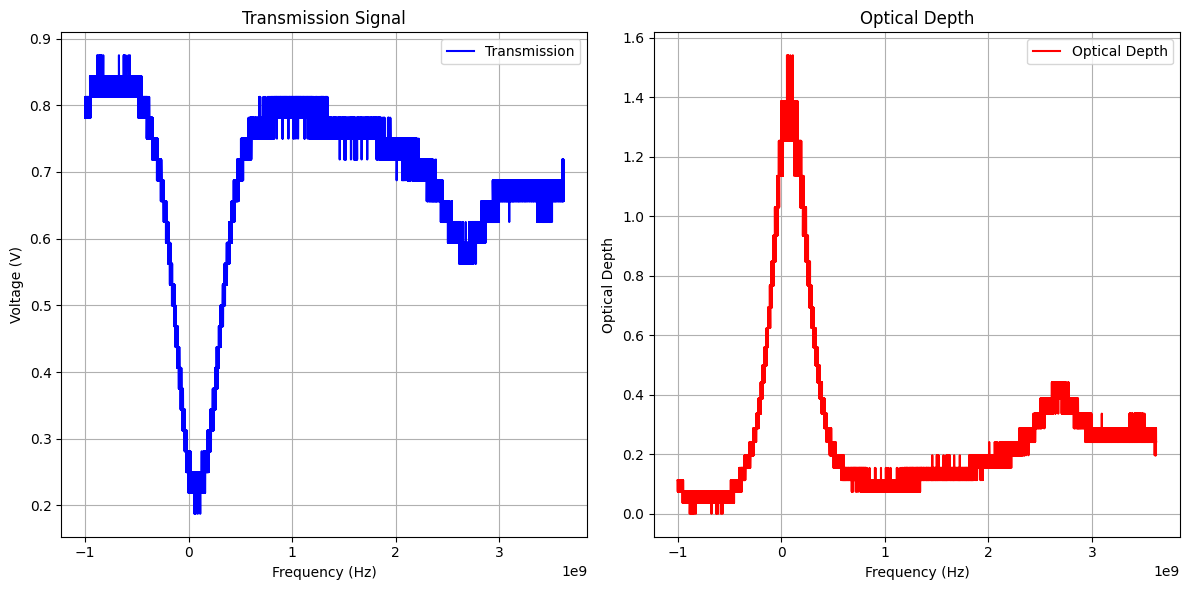

Maximum optical depth: 1.540
Minimum optical depth: -0.000


In [20]:
# Find non-zero indices
non_zero_indices = np.where(voltage > 0.1)[0]
if len(non_zero_indices) > 0:
    start_idx = non_zero_indices[0] + 5000
    end_idx = non_zero_indices[-1] - 5000
    time_range = time[start_idx:end_idx+1]
    voltage_range = voltage[start_idx:end_idx+1]
    # plt.plot(time_range, voltage_range, label="Waveform Data", color="blue")
else:
    plt.plot(time, voltage, label="Waveform Data (all zeros)", color="blue")

# Calculate optical depth from voltage_range
# Assuming voltage_range represents transmission (I/I0)
# Optical depth = -ln(transmission)
optical_depth = -np.log(voltage_range / np.max(voltage_range))
# Convert time scale to frequency scale
# Total time span corresponds to 4600 MHz frequency sweep
total_time = time_range[-1] - time_range[0]
total_freq = 4600e6  # 4600 MHz in Hz

# Create frequency array (assuming linear sweep from high to low frequency)
# Starting from 3620 MHz down to 1020 MHz (3620 - 2600 = 1020)
freq_start = -1000e6 #-3025e6  # 2500 MHz
freq_end = 3620e6     # 500 MHz
frequency = np.linspace(freq_start, freq_end, len(time_range))
# Plot optical depth vs time
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(frequency, voltage_range, label="Transmission", color="blue")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Voltage (V)")
plt.title("Transmission Signal")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(frequency, optical_depth, label="Optical Depth", color="red")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Optical Depth")
plt.title("Optical Depth")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Maximum optical depth: {np.max(optical_depth):.3f}")
print(f"Minimum optical depth: {np.min(optical_depth):.3f}")

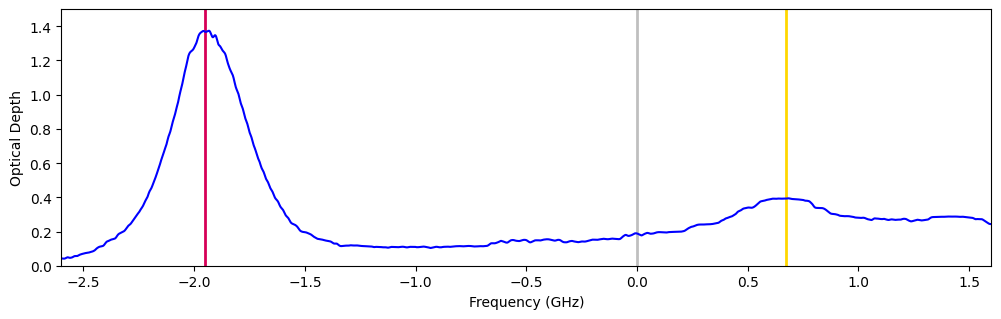

In [21]:
from scipy.ndimage import gaussian_filter1d

# Smooth the optical depth data before plotting
pump_pulse = (2623.24e6)*1e-9
RAP_pulse = (0)*1e-3
laser = (450+1.5e3)*1e-3
# Apply Gaussian smoothing to reduce noise
sigma = 1000  # Adjust this value to control smoothing amount
optical_depth_smooth = gaussian_filter1d(optical_depth, sigma=sigma)
plt.figure(figsize=(12, 10/3))
# plt.plot(frequency/1e9, optical_depth, label="Optical Depth", color="orange")
plt.axvline(x=pump_pulse-laser, color='gold', linestyle='-', alpha=1, linewidth=2)
plt.axvline(x=RAP_pulse-laser, color='#d60057', linestyle='-', alpha=1, linewidth=2)
plt.axvline(x=laser-laser, color='gray', linestyle='-', alpha=0.5, linewidth=2)
plt.xlim(-2.6, 1.6)  # Set x-axis limits from -0.5 to 3.5 GHz
plt.plot(frequency/1e9 -0.07-laser, optical_depth_smooth, label="Optical Depth", color="blue")
plt.xlabel("Frequency (GHz)")
plt.ylabel("Optical Depth")
# plt.title("1g_1e Optical Depth vs Frequency")
plt.ylim(0.0, 1.5)
# plt.legend()
# plt.grid(True)
# plt.savefig('4g_1e_optical_depth_spectrum.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [22]:
pump_pulse - RAP_pulse

2.62324

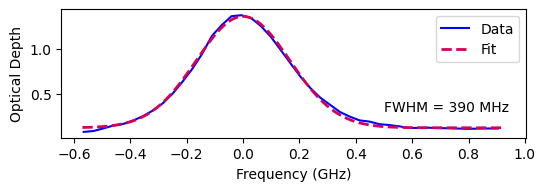

Amplitude = 1.241 ± 0.010
Center = -1.930 ± 0.001 GHz
Width = 0.165 ± 0.002 GHz
FWHM = 0.390 ± 0.004 GHz
Offset = 0.118 ± 0.005


In [55]:
def gaussian(x, amplitude, center, width, offset):
    """Gaussian function with offset"""
    return amplitude * np.exp(-(x - center)**2 / (2 * width**2)) + offset

# Select data in the range -2.5 GHz to -1 GHz
mask = (frequency/1e9 >= -2.5) & (frequency/1e9 <= -1.0)
freq_fit = frequency[mask]/1e9
depth_fit = optical_depth_smooth[mask]

# Initial parameter guesses
amplitude_guess = np.max(depth_fit) - np.min(depth_fit)
center_guess = freq_fit[np.argmax(depth_fit)]
width_guess = 0.3  # in GHz
offset_guess = np.min(depth_fit)

# Perform the fit
# Use the same shifted frequency axis used in the optical-depth plot cell
freq_axis = frequency / 1e9 - 0.07 - ((450 + 1.5e3) * 1e-3)

# Rebuild fit range on corrected axis (prevents single-point selection)
mask = (freq_axis >= -2.5) & (freq_axis <= -1.0)
freq_fit = freq_axis[mask]
depth_fit = optical_depth_smooth[mask]

if freq_fit.size < 5:
    raise ValueError(f"Not enough points for 4-parameter Gaussian fit: {freq_fit.size}")

# Recompute guesses on the corrected window
amplitude_guess = np.max(depth_fit) - np.min(depth_fit)
center_guess = freq_fit[np.argmax(depth_fit)]
offset_guess = np.min(depth_fit)

popt, pcov = curve_fit(
    gaussian,
    freq_fit,
    depth_fit,
    p0=[amplitude_guess, center_guess, width_guess, offset_guess],
    bounds=([0, -2.5, 1e-6, 0], [np.inf, -1.0, np.inf, np.inf]),
    maxfev=20000
)
perr = np.sqrt(np.diag(pcov))

# Generate smooth curve for plotting
x_smooth = np.linspace(-2.5, -1.0, 200) 
y_fit = gaussian(x_smooth, *popt)

# Calculate FWHM (Full Width at Half Maximum)
fwhm = 2.355 * abs(popt[2])  # FWHM = 2.355 * sigma
fwhm_err = 2.355 * perr[2]

# Plot the results (x-axis shifted so fitted peak is at 0)
peak_center = popt[1]  # fitted Gaussian center (GHz)

freq_fit = freq_fit - peak_center
x_smooth = x_smooth - peak_center
plt.figure(figsize=(6, 5/3))
plt.plot(
    freq_fit, depth_fit,
    linestyle='-',
    color='blue', label='Data'
)
plt.plot(x_smooth, y_fit, linestyle='--', linewidth=2, color='#d60057', label='Fit')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Optical Depth')
plt.legend()
# plt.text(-0.4, 0.9, f'FWHM = {fwhm:.3f} ± {fwhm_err:.3f} GHz')
plt.text(0.5, 0.3, f'FWHM = {fwhm*1e3:.0f} MHz')

# plt.text(-0.4, 0.7, f'Center = {popt[1]:.3f} ± {perr[1]:.3f} GHz')
plt.savefig('Plots/4g_1e_optical_depth_fit.pdf', format='pdf', bbox_inches='tight')
plt.show()

print(f'Amplitude = {popt[0]:.3f} ± {perr[0]:.3f}')
print(f'Center = {popt[1]:.3f} ± {perr[1]:.3f} GHz')
print(f'Width = {popt[2]:.3f} ± {perr[2]:.3f} GHz')
print(f'FWHM = {fwhm:.3f} ± {fwhm_err:.3f} GHz')
print(f'Offset = {popt[3]:.3f} ± {perr[3]:.3f}')